# Data Science Mini Project
## By Gladwin Thomas
## DS09

# 1 Planning

## Business Use Case:
In the competetive food delivery market, on-time delivery is critical for customer satisfaction, retention, and operational efficiency. A company wants to optimize delivery time predictions to improve customer experience by providing accurate estimated delivery times and to manage resources effectively. Accurate predictions of delivery time can also allow the business to:

### 1. Improve delivery efficiency: 
    - Identifying the factors that slow down deliveries can enable better resource allocation., such as reliable scheduling for delivery personnel.
### 2. Enhance Customer Satisfaction: 
    - Reliable delivery ETAs can improve the customer experience by reducing wait-time uncertainity. 
    - Clear transparency helps customers informed and reduces the chances of cancelled orders.
### 3. Optimize Operational Costs: 
    - If the model can predict scenarios with higher delays, additional resources (like more drivers or prioritizing specific orders) can be allocated. 
    - Accurate predictions reduces customers service calls regarding delivery delay. 
    - Also company can implement surge pricing in extreme weather or congestion events. 
    - Restaurants can manage staff to balance out between in house orders or home delivery. 
    - Off peak hours can be leveraged to increase customer traffic by using coupons or discounts.

## Problem Statement:
- Predicting the delivery time for food from origin to destination.

## Target:
- Delivery Time in minutes.
    
## Type of algorithms used:
- Regression

## Type of Learning:
- Supervised Learning 

## Dataset Name: 
- swiggy.csv

## Dataset Shape: 
- 45594 X 20

## Dataset Features:
    1. 'ID': order id
    2. 'Delivery_person_ID': ID of the delivery person
    3. 'Delivery_person_Age': Age of the delivery person
    4. 'Delivery_person_Ratings': Average rating of the delivery person
    5. 'Restaurant_latitude': Latitude of the restaurant
    6. 'Restaurant_longitude': Longitude of the restaurant 
    7. 'Delivery_location_latitude': Latitude of the destination 
    8. 'Delivery_location_longitude': Longitude of the destination
    9. 'Order_Date': Date of order 
    10. 'Time_Orderd': Order time
    11. 'Time_Order_picked': Time at which food is picked
    12. 'Weatherconditions': Weather condition during the delivery
    13. 'Road_traffic_density': Road traffic density
    14. 'Vehicle_condition': Condition of the vehicle 
    15. 'Type_of_order': Order type like lunch or snack and so on.
    16. 'Type_of_vehicle': Delivery Vehicle Type
    17. 'multiple_deliveries': Whether multiple deliveries are to be delivered 
    18. 'Festival': Is it a day of festival 
    19. 'City': Type of City
    20. 'Time_taken(min)': Time taken to deliver (in min) [TARGET]
    

## Evaluation Metrics
The most suitable evaluation metric that can be used for our case is MAE (Mean Absolute Error).

This is because due to some factores like weathers, traffic and festivity, delivery time might increase, which results them to act like a outlier , even though they are not. 

Also we can maintain the unit of time which is easier to relate.

So, to be more robust to the outliers and to consider  outlier like values, MAE is used.

# 2 Data Collection
Data is gathered from an existing dataset.

## Source: 
GitHub Swiggy delivery data

## Dataset Name
swiggy.csv

In [1]:
# Import the required Libraries
import numpy as np
import pandas as pd

In [2]:
# Reading the downloaded data
df = pd.read_csv("./data/raw/swiggy.csv")
df.head(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [3]:
# Columns of the dataset
df.columns.tolist()

['ID',
 'Delivery_person_ID',
 'Delivery_person_Age',
 'Delivery_person_Ratings',
 'Restaurant_latitude',
 'Restaurant_longitude',
 'Delivery_location_latitude',
 'Delivery_location_longitude',
 'Order_Date',
 'Time_Orderd',
 'Time_Order_picked',
 'Weatherconditions',
 'Road_traffic_density',
 'Vehicle_condition',
 'Type_of_order',
 'Type_of_vehicle',
 'multiple_deliveries',
 'Festival',
 'City',
 'Time_taken(min)']

In [4]:
# Number of columns 
len(df.columns)

20

# 3 Data Preprocessing 

In [5]:
# Shape of the data
df.shape

(45593, 20)

In [6]:
# Datatypes of columns
df.dtypes

ID                              object
Delivery_person_ID              object
Delivery_person_Age             object
Delivery_person_Ratings         object
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weatherconditions               object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries             object
Festival                        object
City                            object
Time_taken(min)                 object
dtype: object

## Observations regarding datatypes:
1. ID                              object → No change required
2. Delivery_person_ID              object → No change required
3. Delivery_person_Age             object → Convert to int
4. Delivery_person_Ratings         object → Convert to float
5. Restaurant_latitude             float64 → No change required
6. Restaurant_longitude            float64 → No change required
7. Delivery_location_latitude      float64 → No change required
8. Delivery_location_longitude     float64 → No change required
9. Order_Date                      object → Convert to datetime
10. Time_Orderd                    object → Convert to datetime
11. Time_Order_picked              object → Convert to datetime
12. Weatherconditions              object → No change required
13. Road_traffic_density           object → No change required
14. Vehicle_condition              int64 → No change required
15. Type_of_order                  object → No change required
16. Type_of_vehicle                object → No change required
17. multiple_deliveries            object → Convert to boolean or int
18. Festival                       object → No change required
19. City                           object → Convert to categorical/int encoding if needed
20. Time_taken(min)                object → Convert to int


## Changing the column names

In [7]:
df = (
    df.rename(str.lower, axis=1)
    .rename({
        "delivery_person_id": "rider_id",
        "delivery_person_age": "age",
        "delivery_person_ratings": "ratings",
        "delivery_location_latitude": "delivery_latitude",
        "delivery_location_longitude":"delivery_longitude",
        "time_orderd": "order_time",
        "time_order_picked":"order_picked_time",
        "weatherconditions": "weather",
        "road_traffic_density":"traffic",
        "city":"city_type",
        "time_taken(min)":"time_taken"
        
    }, axis=1)
)

df.columns.tolist()

['id',
 'rider_id',
 'age',
 'ratings',
 'restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'order_date',
 'order_time',
 'order_picked_time',
 'weather',
 'traffic',
 'vehicle_condition',
 'type_of_order',
 'type_of_vehicle',
 'multiple_deliveries',
 'festival',
 'city_type',
 'time_taken']

## Handling missing values

In [8]:
# Checking for missing values
df.isna().sum()

id                      0
rider_id                0
age                     0
ratings                 0
restaurant_latitude     0
restaurant_longitude    0
delivery_latitude       0
delivery_longitude      0
order_date              0
order_time              0
order_picked_time       0
weather                 0
traffic                 0
vehicle_condition       0
type_of_order           0
type_of_vehicle         0
multiple_deliveries     0
festival                0
city_type               0
time_taken              0
dtype: int64

In [9]:
df.sample(50)

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
39434,0x3381,CHENRES15DEL01,29,4.9,13.026286,80.275235,13.066286,80.315235,03-04-2022,13:50:00,13:55:00,conditions Windy,High,0,Snack,motorcycle,NaN,No,Metropolitian,(min) 23
7693,0x2e7a,SURRES09DEL02,21,4.5,21.175975,72.795503,21.305975,72.925503,16-03-2022,19:25:00,19:35:00,conditions Sunny,Jam,2,Buffet,motorcycle,0,No,Urban,(min) 15
17776,0xc4bd,AURGRES08DEL03,21,4.6,19.876428,75.364792,19.906428,75.394792,15-02-2022,18:50:00,18:55:00,conditions Sunny,Medium,2,Drinks,electric_scooter,0,No,Urban,(min) 12
30282,0x2e34,BANGRES02DEL03,25,4.5,12.970221,77.645396,13.060221,77.735396,04-03-2022,22:25:00,22:35:00,conditions Cloudy,Low,0,Drinks,motorcycle,1,No,Metropolitian,(min) 23
41603,0xe12,SURRES04DEL03,27,4.8,21.173493,72.801953,21.203493,72.831953,21-03-2022,18:35:00,18:45:00,conditions Fog,Medium,0,Snack,motorcycle,1,No,Metropolitian,(min) 27
13904,0x64a6,SURRES15DEL01,21,4.9,21.160522,72.771477,21.230522,72.841477,04-04-2022,17:55:00,18:10:00,conditions Windy,Medium,2,Snack,scooter,0,No,Metropolitian,(min) 25
32539,0x73ed,COIMBRES14DEL02,39,4.5,11.003681,76.975525,11.053681,77.025525,21-03-2022,20:10:00,20:20:00,conditions Cloudy,Jam,2,Drinks,scooter,0,No,Metropolitian,(min) 27
18052,0xb4a4,BANGRES11DEL02,34,4.9,12.934365,77.616155,12.954365,77.636155,30-03-2022,12:00:00,12:05:00,conditions Sandstorms,High,1,Buffet,scooter,0,No,Metropolitian,(min) 30
20109,0xad8e,VADRES13DEL02,28,5,22.310237,73.158921,22.390237,73.238921,25-03-2022,22:10:00,22:15:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Metropolitian,(min) 20
7283,0x8949,RANCHIRES16DEL01,39,4.9,23.371292,85.327872,23.381292,85.337872,01-04-2022,09:55:00,10:05:00,conditions Cloudy,Low,1,Meal,motorcycle,0,No,Metropolitian,(min) 18


### Observations:
1. We see that there are missing values found in the data


In [10]:
# Index 31936 has NaN, checking 
df.iloc[31936]

id                                0x619c 
rider_id                  BANGRES07DEL01 
age                                  NaN 
ratings                              NaN 
restaurant_latitude             12.978453
restaurant_longitude            77.643685
delivery_latitude               13.048453
delivery_longitude              77.713685
order_date                     06-03-2022
order_time                       20:50:00
order_picked_time                20:55:00
weather                 conditions Stormy
traffic                              Jam 
vehicle_condition                       1
type_of_order                       Meal 
type_of_vehicle                  scooter 
multiple_deliveries                     1
festival                              No 
city_type                  Metropolitian 
time_taken                       (min) 32
Name: 31936, dtype: object

In [11]:
# Format of NaN in the data
df.iloc[31936]["age"]

'NaN '

In [12]:
# Checking for 'NaN '
(df == 'NaN ').sum()

id                         0
rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude        0
restaurant_longitude       0
delivery_latitude          0
delivery_longitude         0
order_date                 0
order_time              1731
order_picked_time          0
weather                    0
traffic                  601
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1200
time_taken                 0
dtype: int64

### Observations
We have found the missing values 

In [13]:
# Checking for missing values in categorical columns
def unique_values(l):
    for col in l:
        print(col)
        print(df[col].unique())
        
unique_values(["rider_id","order_date","order_time","order_picked_time","weather","traffic",'type_of_order',
 'type_of_vehicle', 'multiple_deliveries','festival','city_type','time_taken'])

rider_id
['INDORES13DEL02 ' 'BANGRES18DEL02 ' 'BANGRES19DEL01 ' ...
 'KOCRES04DEL01 ' 'BHPRES06DEL03 ' 'GOARES03DEL03 ']
order_date
['19-03-2022' '25-03-2022' '05-04-2022' '26-03-2022' '11-03-2022'
 '04-03-2022' '14-03-2022' '20-03-2022' '12-02-2022' '13-02-2022'
 '14-02-2022' '02-04-2022' '01-03-2022' '16-03-2022' '15-02-2022'
 '10-03-2022' '27-03-2022' '12-03-2022' '01-04-2022' '05-03-2022'
 '11-02-2022' '08-03-2022' '03-04-2022' '30-03-2022' '28-03-2022'
 '18-03-2022' '06-04-2022' '04-04-2022' '24-03-2022' '09-03-2022'
 '02-03-2022' '13-03-2022' '29-03-2022' '31-03-2022' '17-03-2022'
 '07-03-2022' '15-03-2022' '16-02-2022' '03-03-2022' '18-02-2022'
 '23-03-2022' '17-02-2022' '06-03-2022' '21-03-2022']
order_time
['11:30:00' '19:45:00' '08:30:00' '18:00:00' '13:30:00' '21:20:00'
 '19:15:00' '17:25:00' '20:55:00' '21:55:00' '14:55:00' '17:30:00'
 '09:20:00' '19:50:00' '20:25:00' '20:30:00' '20:40:00' '21:15:00'
 '20:20:00' '22:30:00' '08:15:00' '19:30:00' '12:25:00' '18:35:00'
 '20:35

### Observations
1. order_date -> No missing values
2. order_time -> 'NaN ' found
3. weather -> 'conditions NaN' found, also 'conditions ' string can be removed
4. traffic -> 'NaN ' found
5. multiple_deliveries -> 'NaN ' found
6. festival -> 'NaN ' found
7. city_type -> 'NaN ' found
8. time_taken -> '(min) ' string can be removed


In [14]:
# Making missing values to python np.nan and making some small string replacements 
df = (
    df
    # Making 'NaN ' to np.nan
    .replace("NaN ",np.nan )
    .assign(
        # Replacing 'conditions ' and 'NaN'
        weather = (
            lambda x: x['weather']
            .str.replace("conditions ","")
            .replace("NaN", np.nan)
        ),
        # Removing '(min) '
        time_taken = (
                lambda x: x['time_taken']
                .str.replace('(min) ',"")
            )
    )
)

In [15]:
# Number of missing values
df.isna().sum().sum()

np.int64(9131)

In [16]:
# Column wise missing values
df.isna().sum()

id                         0
rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude        0
restaurant_longitude       0
delivery_latitude          0
delivery_longitude         0
order_date                 0
order_time              1731
order_picked_time          0
weather                  616
traffic                  601
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1200
time_taken                 0
dtype: int64

## Cleaning data

In [17]:
# Dropping id column
df = df.drop(columns="id")
df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
0,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,24
1,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33
2,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26
3,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21
4,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,Windy,High,1,Meal,motorcycle,0,No,Metropolitian,32
45589,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,36
45590,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,16
45591,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,26


In [18]:
# Change age to float as age has missing values
df["age"] = df["age"].astype(float)
df['age'].describe()

count    43739.000000
mean        29.567137
std          5.815155
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: age, dtype: float64

### Observation 
Minimum rider age 15 is concerning


In [19]:
# Riders should be of atleast 18 years
df = df[df["age"] >= 18]
df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,24
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,Windy,High,1,Meal,motorcycle,0,No,Metropolitian,32
45589,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,36
45590,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,16
45591,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,26


In [20]:
# Ratings
df['ratings'].dtype

dtype('O')

In [21]:
df.loc[:,'ratings'] = df['ratings'].astype(float)

In [22]:
df['ratings'].describe()


count     43647.0
unique       27.0
top           4.8
freq       7148.0
Name: ratings, dtype: float64

In [23]:
np.max(df.ratings)

6.0

### Observations
Rating is from 1 to 5. Remove greater than 5

In [24]:
# Removing ratings that are greater than 5
df = df[df['ratings'] <= 5]
df["ratings"].describe()

count     43594.0
unique       26.0
top           4.8
freq       7148.0
Name: ratings, dtype: float64

In [25]:
# Location Columns
location_columns = df[['restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude']]
location_columns

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
0,22.745049,75.892471,22.765049,75.912471
1,12.913041,77.683237,13.043041,77.813237
2,12.914264,77.678400,12.924264,77.688400
3,11.003669,76.976494,11.053669,77.026494
4,12.972793,80.249982,13.012793,80.289982
...,...,...,...,...
45588,26.902328,75.794257,26.912328,75.804257
45589,0.000000,0.000000,0.070000,0.070000
45590,13.022394,80.242439,13.052394,80.272439
45591,11.001753,76.986241,11.041753,77.026241


### Fact
India lies to the north of the equator between 6 degree 44 minutes and 35 degree 30 minutes north latitude and, 68 degree 7 minutes and 97 degree 25 minutes east longitude

In [26]:
location_columns.describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,43594.000000,43594.000000,43594.000000,43594.000000
mean,17.244769,70.768898,17.461540,70.832489
std,7.690005,21.128773,7.338199,21.128940
min,-30.902872,0.000000,0.010000,0.010000
25%,12.933298,73.170283,12.986054,73.280000
50%,18.554382,75.898497,18.633934,76.002471
75%,22.732225,78.045359,22.785049,78.102309
max,30.914057,88.433452,31.054057,88.563452


In [27]:
# So we have to remove data having latitude and longitude outside of india.
df.loc[:, location_columns.columns] = df[
    (df['restaurant_latitude'] >= 6.44) & 
    (df['restaurant_latitude'] <= 35.3)  & 
    (df['delivery_latitude'] >= 6.44) & 
    (df['delivery_latitude'] <= 35.3) & 
    (df['restaurant_longitude'] >= 68.7) & 
    (df['restaurant_longitude'] <= 97.25) &
    (df['delivery_longitude'] >= 68.7) & 
    (df['delivery_longitude'] <= 97.25)
]
df.shape

(43594, 19)

In [28]:
df[location_columns.columns].describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,39958.000000,39958.000000,39958.000000,39958.000000
mean,18.897525,76.909839,18.961162,76.973475
std,5.463903,3.489784,5.465724,3.490006
min,9.957144,72.768726,9.967144,72.778726
25%,12.986047,73.897902,13.065479,73.939315
50%,19.065838,76.618203,19.115838,76.662278
75%,22.751234,78.347554,22.818060,78.399645
max,30.914057,88.433452,31.054057,88.563452


In [29]:
# Order date
df['order_date'].isna().sum()

np.int64(0)

In [30]:
df['order_date'].unique()

array(['19-03-2022', '25-03-2022', '05-04-2022', '26-03-2022',
       '11-03-2022', '04-03-2022', '14-03-2022', '20-03-2022',
       '12-02-2022', '13-02-2022', '14-02-2022', '02-04-2022',
       '01-03-2022', '16-03-2022', '15-02-2022', '10-03-2022',
       '27-03-2022', '12-03-2022', '01-04-2022', '05-03-2022',
       '11-02-2022', '08-03-2022', '03-04-2022', '30-03-2022',
       '28-03-2022', '18-03-2022', '04-04-2022', '24-03-2022',
       '09-03-2022', '02-03-2022', '13-03-2022', '29-03-2022',
       '31-03-2022', '17-03-2022', '07-03-2022', '15-03-2022',
       '16-02-2022', '03-03-2022', '18-02-2022', '23-03-2022',
       '06-03-2022', '21-03-2022', '06-04-2022', '17-02-2022'],
      dtype=object)

In [31]:
# Converting order_date to datetime
df = df.assign(
    order_date = lambda x: pd.to_datetime(
    x["order_date"],
    format="%d-%m-%Y")
)

In [32]:
df["order_date"].dtype

dtype('<M8[ns]')

In [33]:
# Order_time
df["order_time"].isna().sum()

np.int64(0)

In [34]:
# Convert order time to datetime
df = df.assign(
    order_time = lambda x: pd.to_datetime(
            x["order_time"],
            format="%H:%M:%S"
    )
)

In [35]:
df["order_time"].dtype

dtype('<M8[ns]')

In [36]:
# order_picked_time
df["order_picked_time"].isna().sum()

np.int64(0)

In [37]:
# Convert order_picked_time to datetime
df = df.assign(
    order_picked_time=lambda x: pd.to_datetime(
            x["order_picked_time"],
            format="%H:%M:%S"
    )
)

In [38]:
df["order_picked_time"].dtype

dtype('<M8[ns]')

In [39]:
# Weather
df['weather'].unique()

array(['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy'],
      dtype=object)

In [40]:
df.weather.isna().sum()

np.int64(0)

In [41]:
# Traffic
df['traffic'].unique()

array(['High ', 'Jam ', 'Low ', 'Medium '], dtype=object)

In [42]:
df["traffic"].isna().sum()

np.int64(0)

In [43]:
# Removing right ' ' and converting to lower
df.loc[:,"traffic"] = df['traffic'].str.rstrip().str.lower()

In [44]:
df['traffic'].unique()

array(['high', 'jam', 'low', 'medium'], dtype=object)

In [45]:
# Vehicle Condition
df['vehicle_condition'].unique()

array([2, 0, 1])

In [46]:
# Type of order
df['type_of_order'].unique()

array(['Snack ', 'Drinks ', 'Buffet ', 'Meal '], dtype=object)

In [47]:
# Removing right ' ' and converting to lower
df.loc[:,"type_of_order"] = df['type_of_order'].str.rstrip().str.lower()
df['type_of_order'].unique()

array(['snack', 'drinks', 'buffet', 'meal'], dtype=object)

In [48]:
# Type of vehicle
df['type_of_vehicle'].unique()

array(['motorcycle ', 'scooter ', 'electric_scooter '], dtype=object)

In [49]:
# Removing right ' ' 
df.loc[:,"type_of_vehicle"] = df['type_of_vehicle'].str.rstrip().str.lower()
df['type_of_vehicle'].unique()

array(['motorcycle', 'scooter', 'electric_scooter'], dtype=object)

In [50]:
# multiple_deliveries
df["multiple_deliveries"].unique()

array(['0', '1', '3', nan, '2'], dtype=object)

In [51]:
df.multiple_deliveries.isna().sum()

np.int64(933)

In [52]:
df.multiple_deliveries = df.multiple_deliveries.astype(float)

In [53]:
# because of nan values
df.multiple_deliveries.dtype

dtype('float64')

In [54]:
# Festivals
df['festival'].unique()

array(['No ', 'Yes ', nan], dtype=object)

In [55]:
# Removing right ' ' and converting to lower
df.loc[:,"festival"] = df['festival'].str.lower()
df['festival'].unique()

array(['no ', 'yes ', nan], dtype=object)

In [56]:
df.festival.isna().sum()

np.int64(217)

In [57]:
# City type
df['city_type'].unique()

array(['Urban ', 'Metropolitian ', 'Semi-Urban ', nan], dtype=object)

In [58]:
# Removing right ' ' and converting to lower
df.loc[:,"city_type"] = df['city_type'].str.lower().str.rstrip()
df['city_type'].unique()

array(['urban', 'metropolitian', 'semi-urban', nan], dtype=object)

In [59]:
df.city_type.isna().sum()

np.int64(1135)

In [60]:
# Time Taken -> Target
df['time_taken'].dtype

dtype('O')

In [61]:
df.time_taken.unique()

array(['24', '33', '26', '21', '30', '40', '32', '34', '46', '23', '20',
       '41', '15', '36', '39', '18', '38', '47', '12', '22', '25', '35',
       '10', '19', '11', '28', '52', '16', '27', '49', '17', '14', '37',
       '44', '42', '31', '13', '29', '50', '43', '48', '54', '53', '45',
       '51'], dtype=object)

In [62]:
# Convert datatype to int
df.time_taken = df.time_taken.astype(int)

In [63]:
df['time_taken'].dtype

dtype('int64')

# 4 Feature Engineering

In [64]:
# Extract city name out of rider id.
df["city_name"] = df['rider_id'].str.split('RES').str.get(0)
df.city_name.unique()

array(['INDO', 'BANG', 'COIMB', 'CHEN', 'HYD', 'RANCHI', 'MYS', 'DEH',
       'KOC', 'PUNE', 'LUDH', 'KNP', 'MUM', 'KOL', 'JAP', 'SUR', 'GOA',
       'AURG', 'AGR', 'VAD', 'ALH', 'BHP'], dtype=object)

In [65]:
# Creating features from order_date
df = df.assign(

    # Creating order_day
    order_day = lambda x: x['order_date'].dt.day,
    
    # Creating order_month
    order_month = lambda x: x['order_date'].dt.month,
    
    # Creating order year
    order_year =  lambda x: x['order_date'].dt.year,
    
    # Creating order_day_of_week
    order_day_of_week = lambda x: x['order_date'].dt.day_name(),
    
    # Creating is_weekend
    is_weekend = lambda x: x['order_date'].dt.day_name().isin(["Saturday", "Sunday"]).astype(int)
)


In [66]:
# Function to categorize time of day
def time_of_day(time):
    if time >=6 and time < 12:
        return "morning"
    elif time>=12 and time <17: 
        return "afternoon"
    elif time >= 17 and time <20:
        return "evening"
    elif time>=20 and time <24:
        return "night"
    else:
        return "after_midnight"

In [67]:
# Creating features from order_time and order_picked_time
df = (
    df
    .assign(
        
        # Create picked_time to get min taken to pick order
        pickup_time=lambda x:
        (
            (x['order_picked_time'] - x["order_time"])
            .dt.total_seconds()
            .where(
                lambda s: s >= 0,
                lambda s: s + 24 * 3600
            ) / 60
        )
    )
    
    
    # To get the order time hour
    .assign (
        order_time_hour = lambda x: x["order_time"].dt.hour
    )
)

# To get the order_time_of_day 
df["order_time_of_day"] = df["order_time_hour"].apply(lambda x: time_of_day(x))

In [68]:
# Creating a distance feature using haversine distance

lat1 = df["restaurant_latitude"]
lon1 = df["restaurant_longitude"]
lat2 = df["delivery_latitude"]
lon2 = df["delivery_longitude"]

lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

dlon = lon2 - lon1
dlat = lat2 - lat1

a = np.sin(dlat/2)**2 + np.cos(lat1)* np.cos(lat2) * np.sin(dlon / 2)**2
c = 2* np.arcsin(np.sqrt(a))
distance = 6371 * c

df['distance'] = distance

In [69]:
df.columns.tolist()

['rider_id',
 'age',
 'ratings',
 'restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'order_date',
 'order_time',
 'order_picked_time',
 'weather',
 'traffic',
 'vehicle_condition',
 'type_of_order',
 'type_of_vehicle',
 'multiple_deliveries',
 'festival',
 'city_type',
 'time_taken',
 'city_name',
 'order_day',
 'order_month',
 'order_year',
 'order_day_of_week',
 'is_weekend',
 'pickup_time',
 'order_time_hour',
 'order_time_of_day',
 'distance']

In [70]:
df = df.drop(columns=["order_time","order_picked_time"])
df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_year,order_day_of_week,is_weekend,pickup_time,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,Sunny,high,...,INDO,19,3,2022,Saturday,1,15.0,11,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,Stormy,jam,...,BANG,25,3,2022,Friday,0,5.0,19,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,Sandstorms,low,...,BANG,19,3,2022,Saturday,1,15.0,8,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,Sunny,medium,...,COIMB,5,4,2022,Tuesday,0,10.0,18,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,Cloudy,high,...,CHEN,26,3,2022,Saturday,1,15.0,13,afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,Windy,high,...,JAP,24,3,2022,Thursday,0,10.0,11,morning,1.489846
45589,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,Windy,jam,...,AGR,16,2,2022,Wednesday,0,15.0,19,evening,NaN
45590,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,Cloudy,low,...,CHEN,11,3,2022,Friday,0,15.0,23,night,4.657195
45591,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,Cloudy,high,...,COIMB,7,3,2022,Monday,0,5.0,13,afternoon,6.232393


# 5 Exploratory data analysis

In [71]:
df.isna().sum()

rider_id                   0
age                        0
ratings                    0
restaurant_latitude     3636
restaurant_longitude    3636
delivery_latitude       3636
delivery_longitude      3636
order_date                 0
weather                    0
traffic                    0
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      933
festival                 217
city_type               1135
time_taken                 0
city_name                  0
order_day                  0
order_month                0
order_year                 0
order_day_of_week          0
is_weekend                 0
pickup_time                0
order_time_hour            0
order_time_of_day          0
distance                3636
dtype: int64

In [72]:
# Number of rows in the data that have missing values

missing_rows = (
    df
    .isnull()
    .any(axis=1)
    .sum()
)

print(f'There are {missing_rows} rows with missing values in the data.')

print(f"It accounts for {(missing_rows/df.shape[0])*100:.2f}% of the data")
  

There are 5676 rows with missing values in the data.
It accounts for 13.02% of the data


In [73]:
# Checking for duplicate rows in the data
df.duplicated().sum()

np.int64(0)

### Observation 
There are no duplicate row in our data

In [74]:
# Data types of features
df.dtypes

rider_id                        object
age                            float64
ratings                         object
restaurant_latitude            float64
restaurant_longitude           float64
delivery_latitude              float64
delivery_longitude             float64
order_date              datetime64[ns]
weather                         object
traffic                         object
vehicle_condition                int64
type_of_order                   object
type_of_vehicle                 object
multiple_deliveries            float64
festival                        object
city_type                       object
time_taken                       int64
city_name                       object
order_day                        int32
order_month                      int32
order_year                       int32
order_day_of_week               object
is_weekend                       int64
pickup_time                    float64
order_time_hour                  int32
order_time_of_day        

In [75]:
# Numerical and categorical columns
num_cols = [col for col in df.columns if df[col].dtype not in ["O",'<M8[ns]']]
categorical_cols = [col for col in df.columns if df[col].dtype=='O']

In [76]:
print(f"There are {len(num_cols)} numerical columns and {len(categorical_cols)} categorical columns ")

There are 15 numerical columns and 11 categorical columns 


In [77]:
num_cols

['age',
 'restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'vehicle_condition',
 'multiple_deliveries',
 'time_taken',
 'order_day',
 'order_month',
 'order_year',
 'is_weekend',
 'pickup_time',
 'order_time_hour',
 'distance']

In [78]:
categorical_cols

['rider_id',
 'ratings',
 'weather',
 'traffic',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'city_name',
 'order_day_of_week',
 'order_time_of_day']

In [79]:
# Statistical summary of numerical columns
df[num_cols].describe()

,age,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,vehicle_condition,multiple_deliveries,time_taken,order_day,order_month,order_year,is_weekend,pickup_time,order_time_hour,distance
count,43594.000000,39958.000000,39958.000000,39958.000000,39958.000000,43594.000000,42661.000000,43594.000000,43594.000000,43594.000000,43594.0,43594.000000,43594.000000,43594.000000,39958.000000
mean,29.555719,18.897525,76.909839,18.961162,76.973475,1.000573,0.743747,26.292127,13.811763,2.981052,2022.0,0.275451,9.991054,17.424737,9.716000
std,5.760689,5.463903,3.489784,5.465724,3.490006,0.816735,0.572798,9.372057,8.712240,0.545886,0.0,0.446746,4.086545,4.818828,5.598498
min,20.000000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000,10.000000,1.000000,2.000000,2022.0,0.000000,5.000000,0.000000,1.465067
25%,25.000000,12.986047,73.897902,13.065479,73.939315,0.000000,0.000000,19.000000,6.000000,3.000000,2022.0,0.000000,5.000000,15.000000,4.657655
50%,30.000000,19.065838,76.618203,19.115838,76.662278,1.000000,1.000000,26.000000,13.000000,3.000000,2022.0,0.000000,10.000000,19.000000,9.193021
75%,35.000000,22.751234,78.347554,22.818060,78.399645,2.000000,1.000000,32.000000,20.000000,3.000000,2022.0,1.000000,15.000000,21.000000,13.631449
max,39.000000,30.914057,88.433452,31.054057,88.563452,2.000000,3.000000,54.000000,31.000000,4.000000,2022.0,1.000000,15.000000,23.000000,20.969489


In [80]:
# statistical summary of categorical columns

df[categorical_cols].describe().T

,count,unique,top,freq
rider_id,43594,1320,PUNERES01DEL01,65
ratings,43594.0,26.0,4.8,7148.0
weather,43594,6,Fog,7435
traffic,43594,4,low,14976
type_of_order,43594,4,snack,11020
type_of_vehicle,43594,3,motorcycle,25486
festival,43377,2,no,42525
city_type,42459,3,metropolitian,32592
city_name,43594,22,JAP,3307
order_day_of_week,43594,7,Wednesday,6775


In [81]:
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib.gridspec import GridSpec
import seaborn as sns

def numerical_analysis(dataframe, column_name, cat_col=None, bins="auto"):
    # create the figure
    fig = plt.figure(figsize=(15,10))
    
    # generate the layout
    grid = GridSpec(nrows=2, ncols=2, figure=fig)
    
    # set subplots
    ax1 = fig.add_subplot(grid[0, 0])
    ax2 = fig.add_subplot(grid[0, 1])
    ax3 = fig.add_subplot(grid[1, :])
    
    # plot the kdeplot
    sns.kdeplot(data=dataframe, x=column_name,hue=cat_col, ax=ax1)
    
    # plot the boxplot
    sns.boxplot(data=dataframe, x=column_name,hue=cat_col, ax=ax2)
    
    # plot the histogram
    sns.histplot(data=dataframe, x=column_name,bins=bins,hue=cat_col,kde=True, ax=ax3)
    plt.tight_layout()
    plt.show()


def numerical_categorical_analysis(dataframe, cat_column_1, num_column):

    fig = plt.figure(figsize=(15, 8))

    # Create layout
    grid = GridSpec(2, 2, figure=fig)

    # Define axes
    ax1 = fig.add_subplot(grid[0, 0])
    ax2 = fig.add_subplot(grid[0, 1])
    # spans entire second row
    ax3 = fig.add_subplot(grid[1, :])  
    
    # Plot barplot
    sns.barplot(
        data=dataframe,
        x=cat_column_1,
        y=num_column,
        ax=ax1
    )

    # Plot boxplot
    sns.boxplot(
        data=dataframe,
        x=cat_column_1,
        y=num_column,
        ax=ax2
    )

    # Plot violinplot
    sns.violinplot(
        data=dataframe,
        x=cat_column_1,
        y=num_column,
        ax=ax3
    )

    plt.tight_layout()
    plt.show()
    
    
def categorical_analysis(dataframe, column_name):
    
    # print the values counts of categories
    display(
        pd.DataFrame({
            "Count": (
                dataframe[column_name]
                .value_counts()),
            "Percentage": (
                dataframe[column_name]
                .value_counts(normalize=True)
                .mul(100)
                .round(2)
                .astype("str")
                .add("%")
                )
        }).sort_index()
    )
    print("*" * 50)
    
    # get unique categories
    unique_categories = dataframe[column_name].unique().tolist()
    number_of_categories = dataframe[column_name].nunique()
    print(f"The unique categories in {column_name} column are {unique_categories}")
    print("*" * 50)
    print(f"The number of categories in {column_name} column are {number_of_categories}")
    
    # plot countplot
    sns.countplot(data=dataframe, x=column_name)
    plt.xticks(rotation=45)
    plt.show()


def multivariate_analysis(dataframe, num_column, cat_column_1, cat_column_2):
    fig = plt.figure(figsize=(15, 8))

    # Create layout
    grid = GridSpec(2, 2, figure=fig)

    # Define axes
    ax1 = fig.add_subplot(grid[0, 0])
    ax2 = fig.add_subplot(grid[0, 1])
    # spans entire second row
    ax3 = fig.add_subplot(grid[1, :]) 
    
    # plot the barplot
    sns.barplot(data=dataframe, x=cat_column_1,
                y=num_column,hue=cat_column_2, ax=ax1)
    
    # plot the boxplot
    sns.boxplot(data=dataframe, x=cat_column_1,
                y=num_column,hue=cat_column_2, gap=0.1, ax=ax2)
    
    # plot violin plot
    sns.violinplot(data=dataframe, x=cat_column_1, gap=0.1,
                   y=num_column,hue=cat_column_2, ax=ax3)
    plt.tight_layout()
    plt.show()

## Column Wise Analysis

In [82]:
df.columns.tolist()

['rider_id',
 'age',
 'ratings',
 'restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'order_date',
 'weather',
 'traffic',
 'vehicle_condition',
 'type_of_order',
 'type_of_vehicle',
 'multiple_deliveries',
 'festival',
 'city_type',
 'time_taken',
 'city_name',
 'order_day',
 'order_month',
 'order_year',
 'order_day_of_week',
 'is_weekend',
 'pickup_time',
 'order_time_hour',
 'order_time_of_day',
 'distance']

### Time Taken (Target)

In [83]:
# data type of column

df['time_taken'].dtype

dtype('int64')

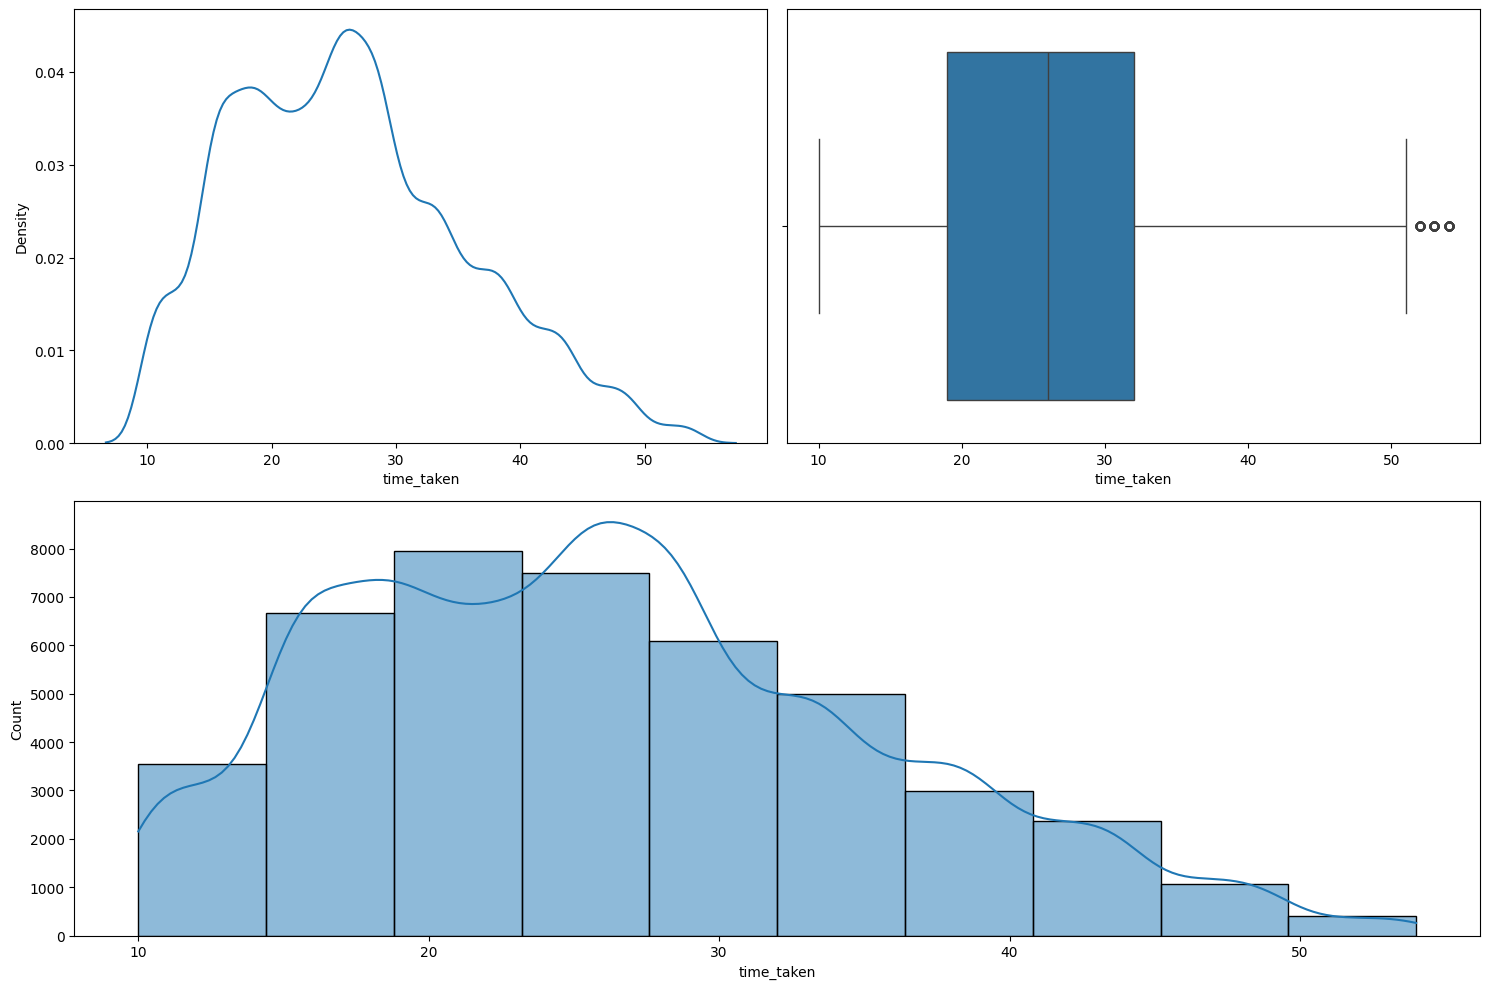

In [84]:
# numerical analysis

numerical_analysis(df, 'time_taken',bins=10)

#### Observations:

1. The target column is not fully continuous in nature.
2. The target column has some outlier like points but they are just extreme and rare, not outliers. 50 min time is possible for delivery in certain rare cases.

In [85]:
# check out the rows where data is acting as outlier

target_25_per, target_75_per = np.percentile(df['time_taken'], [25, 75])
iqr = target_75_per - target_25_per

upper_bound = target_75_per + (1.5 * iqr)

df.loc[(df['time_taken'] > upper_bound),"traffic"].value_counts()

traffic
jam     230
high     23
Name: count, dtype: int64

In [86]:
# Time taken greater than upper bound because of weather
df.loc[(df['time_taken'] > upper_bound),"weather"].value_counts()

weather
Fog           57
Sunny         49
Windy         41
Cloudy        41
Stormy        33
Sandstorms    32
Name: count, dtype: int64

In [87]:
# average distances for time taken greater than upper bound
avg_distance = df.loc[:,"distance"].mean()
avg_distance_extreme = df.loc[(df['time_taken'] > upper_bound),"distance"].mean()

print(avg_distance, avg_distance_extreme)

9.716000024766036 13.19839907590643


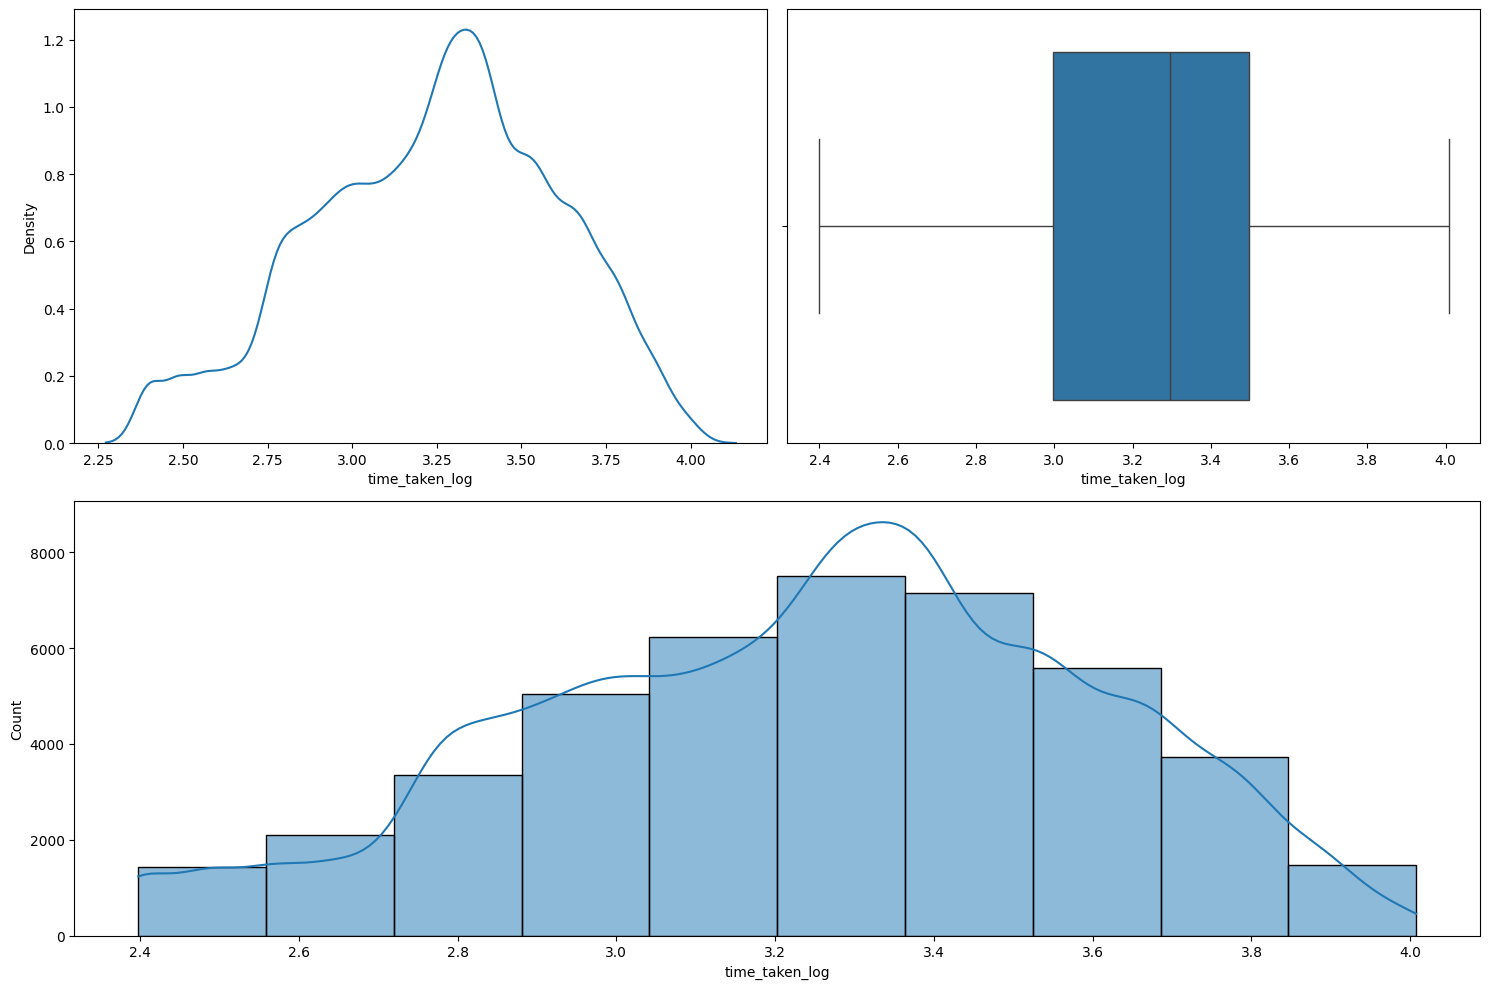

In [88]:
# fix target column distribution using transformation

df["time_taken_log"] = np.log1p(df["time_taken"])

numerical_analysis(df, "time_taken_log", bins=10)

In [89]:
# Checking the skewness
print(df["time_taken"].skew())
print(df["time_taken_log"].skew())

0.4825139563282931
-0.2560394420666443


#### Observation
After transformation , right skewed distribution becomes left skewed

## Rider ID

In [90]:
# datatype of rider id

df['rider_id'].dtype

dtype('O')

In [91]:
df[["rider_id","age","ratings"]]

,rider_id,age,ratings
0,INDORES13DEL02,37.0,4.9
1,BANGRES18DEL02,34.0,4.5
2,BANGRES19DEL01,23.0,4.4
3,COIMBRES13DEL02,38.0,4.7
4,CHENRES12DEL01,32.0,4.6
...,...,...,...
45588,JAPRES04DEL01,30.0,4.8
45589,AGRRES16DEL01,21.0,4.6
45590,CHENRES08DEL03,30.0,4.9
45591,COIMBRES11DEL01,20.0,4.7


In [92]:
# sample of data

rider_id_group = df[["rider_id","age","ratings"]].groupby('rider_id')
rider_id_group.head(5).sort_values('rider_id')

,rider_id,age,ratings
12437,AGRRES010DEL01,34.0,4.5
13244,AGRRES010DEL01,39.0,4.4
4558,AGRRES010DEL01,38.0,4.7
7750,AGRRES010DEL01,21.0,4.7
92,AGRRES010DEL01,34.0,4.7
...,...,...,...
861,VADRES20DEL03,35.0,4.8
5151,VADRES20DEL03,37.0,4.9
5099,VADRES20DEL03,35.0,4.9
9807,VADRES20DEL03,30.0,4.6


In [93]:
# check for duplicates

df.groupby("rider_id")[["age"]].nunique()

,age
rider_id,
AGRRES010DEL01,7
AGRRES010DEL02,10
AGRRES010DEL03,11
AGRRES01DEL01,6
AGRRES01DEL02,11
...,...
VADRES19DEL02,20
VADRES19DEL03,17
VADRES20DEL01,19


#### Observation
For the same rider, there are multiple age values.
So this creates inconsistencies in data. This feature is dirty.

### Age

In [94]:
# data type of age column

df['age'].dtype

dtype('float64')

In [95]:
# statistical summary

df['age'].describe()

count    43594.000000
mean        29.555719
std          5.760689
min         20.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: age, dtype: float64

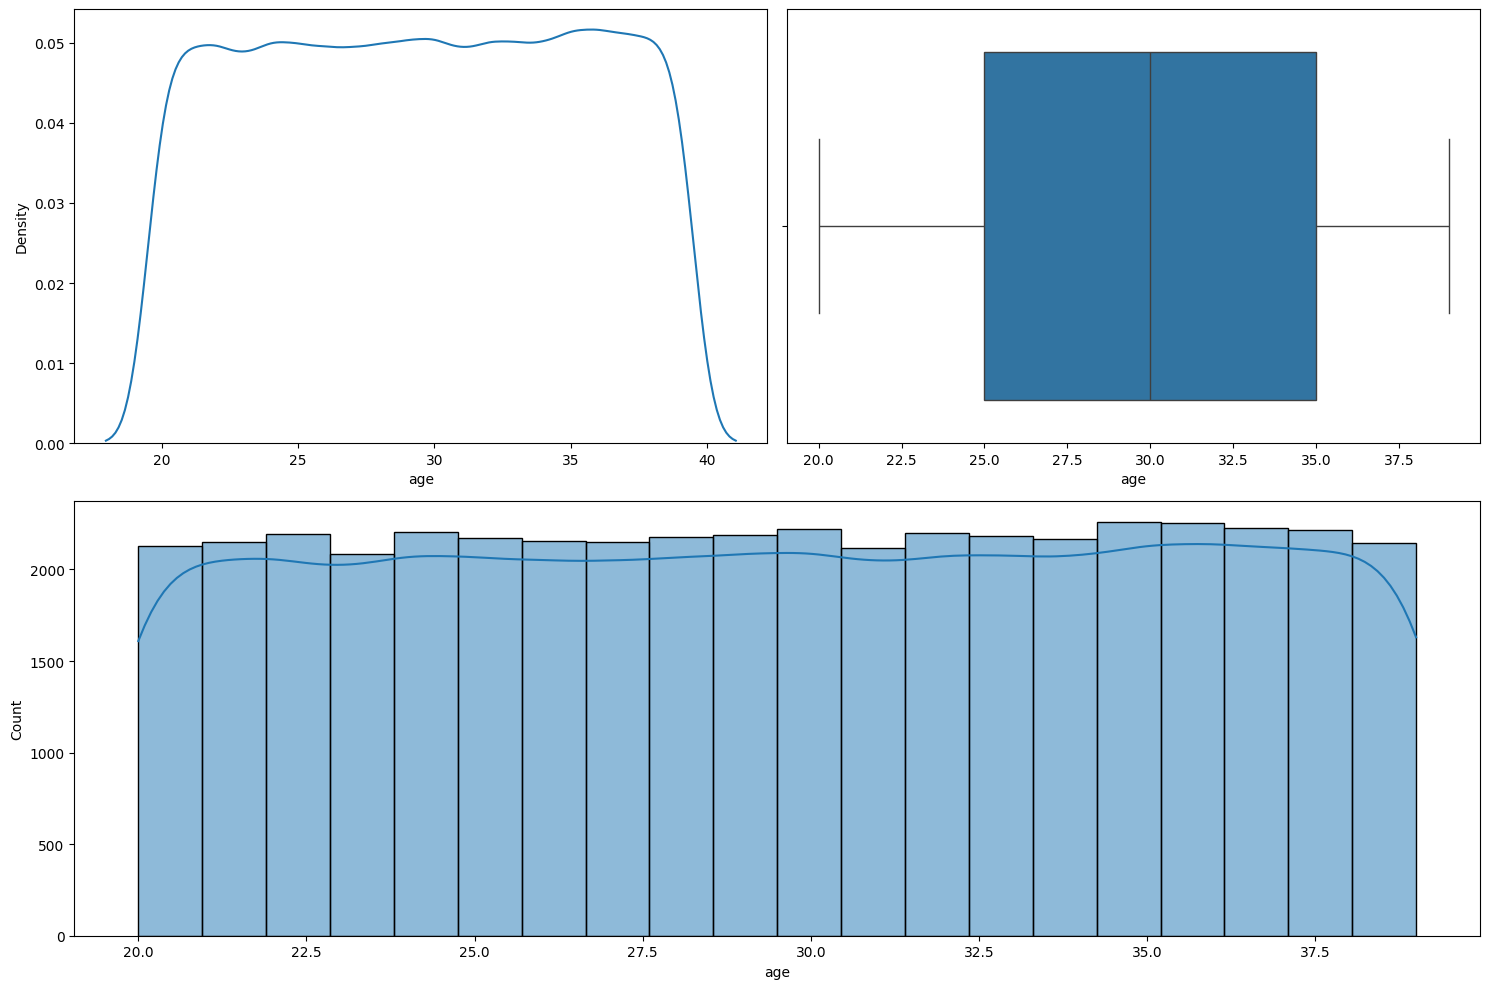

In [96]:
# numerical analysis for age

numerical_analysis(df, 'age',bins=20)

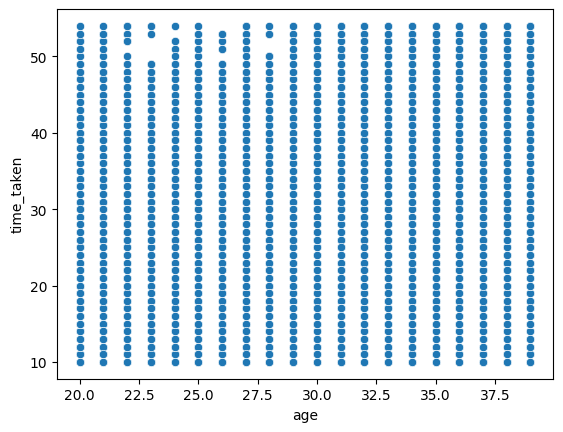

In [97]:
# relationship between target and age

sns.scatterplot(data=df, x='age', y='time_taken')
plt.show()

#### Age of the rider does not show any impact on timetaken to deliver

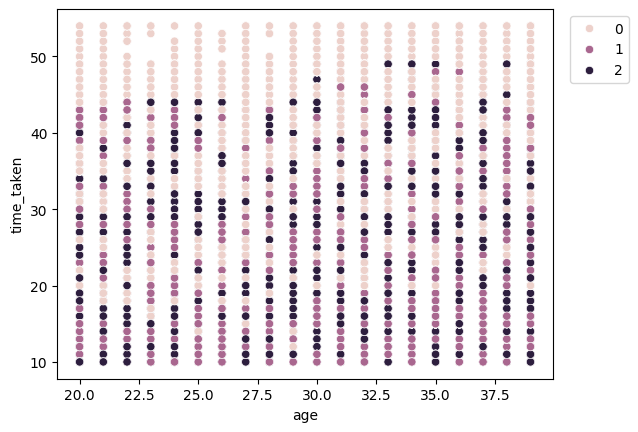

In [98]:
# Vehicle condition and age relation to time taken

sns.scatterplot(data=df, x='age', y='time_taken', hue="vehicle_condition")
plt.legend(bbox_to_anchor=(1.02, 1), loc=2)
plt.show()

### Ratings 

In [99]:
# data type of rating column

df['ratings'].dtype

dtype('O')

In [100]:
df.ratings = df.ratings.astype(float)
df['ratings'].dtype

dtype('float64')

In [101]:
# statistical summary

df['ratings'].describe()
     

count    43594.000000
mean         4.635287
std          0.313827
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: ratings, dtype: float64

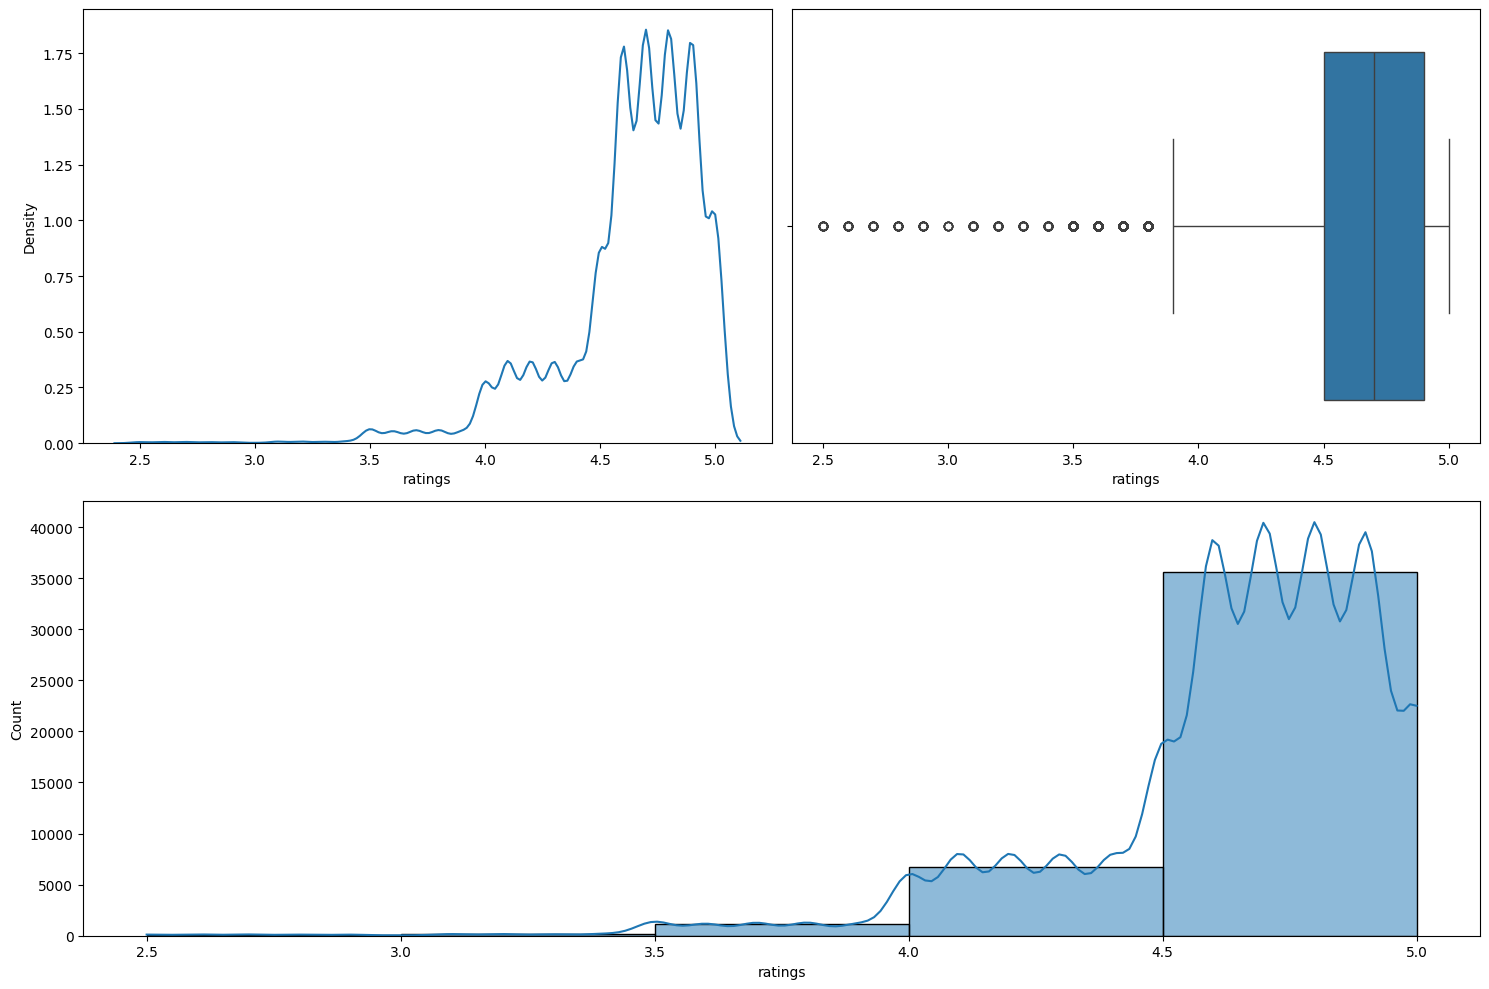

In [102]:
# numerical analysis

numerical_analysis(df, 'ratings',bins=5)

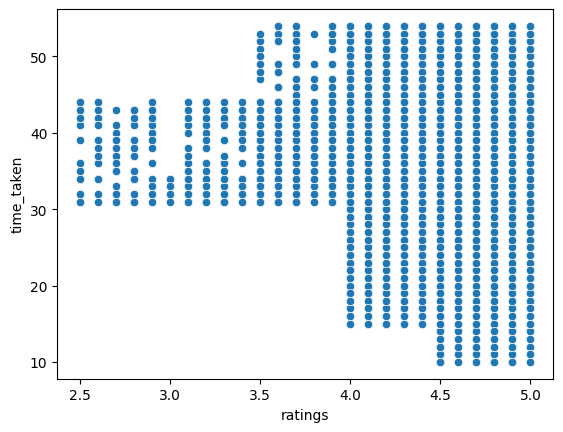

In [103]:
# does ratings affect delivery time

sns.scatterplot(data=df, x='ratings', y='time_taken')
plt.show()

#### Observations

It seems like riders with more ratings get more orders

Higher ratings equates to more work and more income opportunities

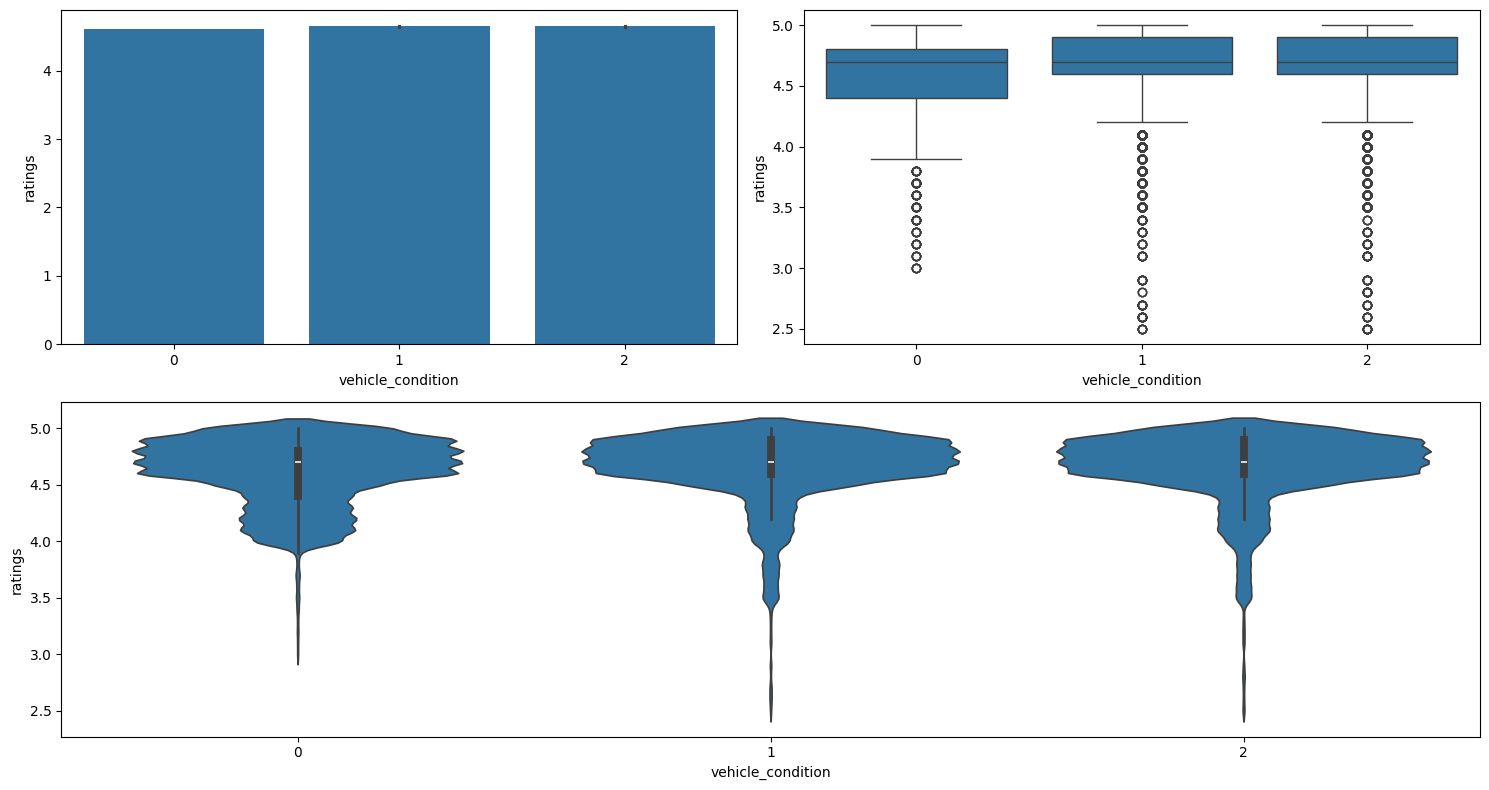

In [104]:
# does ratings get affected by vehicle type

numerical_categorical_analysis(df, 'vehicle_condition', 'ratings')

#### Observations
Yes they do

The more worst the vehicle condition is, the more lower the rating gets.

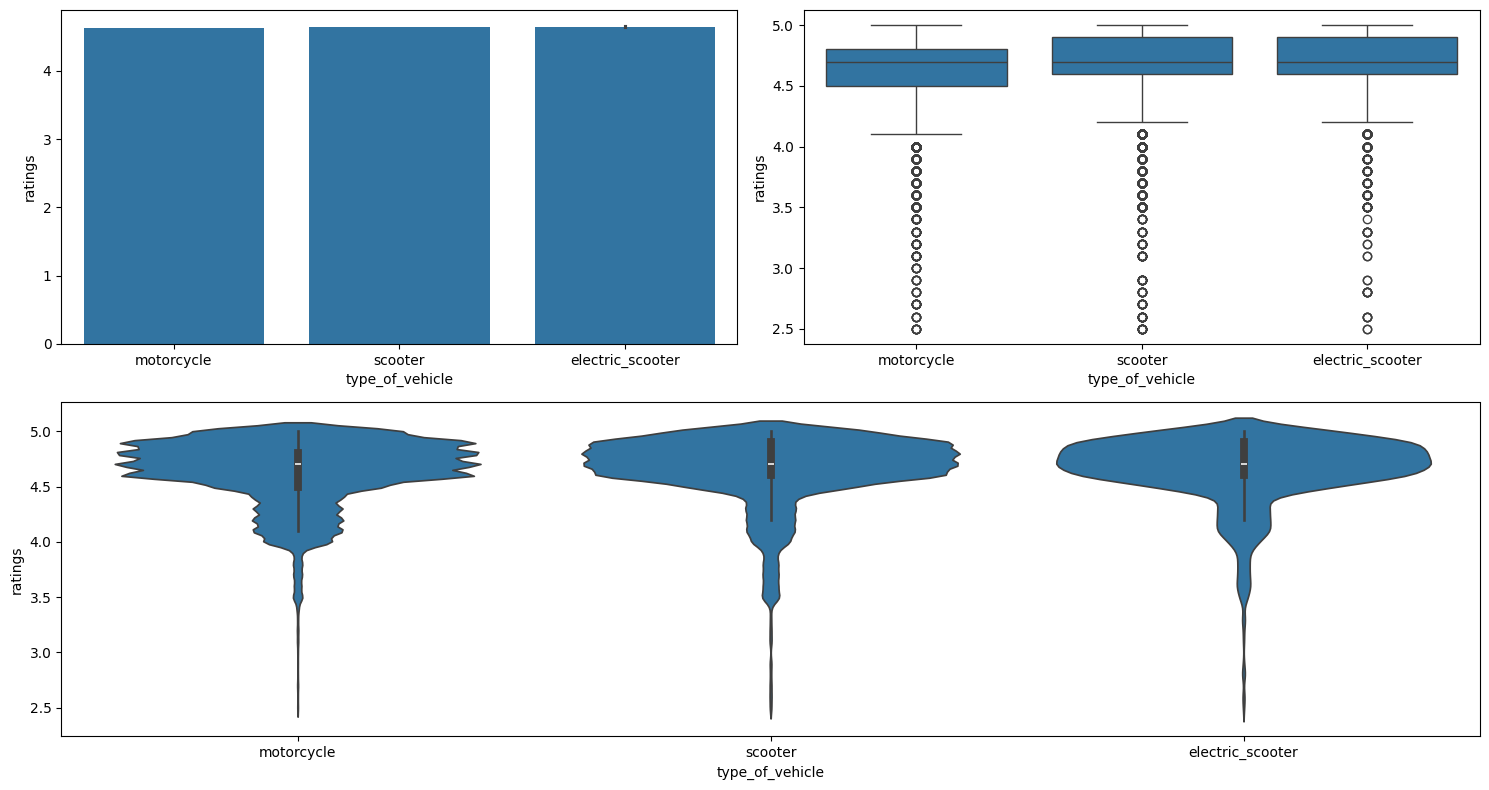

In [105]:
# does type of vehicle affects ratings

numerical_categorical_analysis(df, 'type_of_vehicle', 'ratings')

#### Observations
No

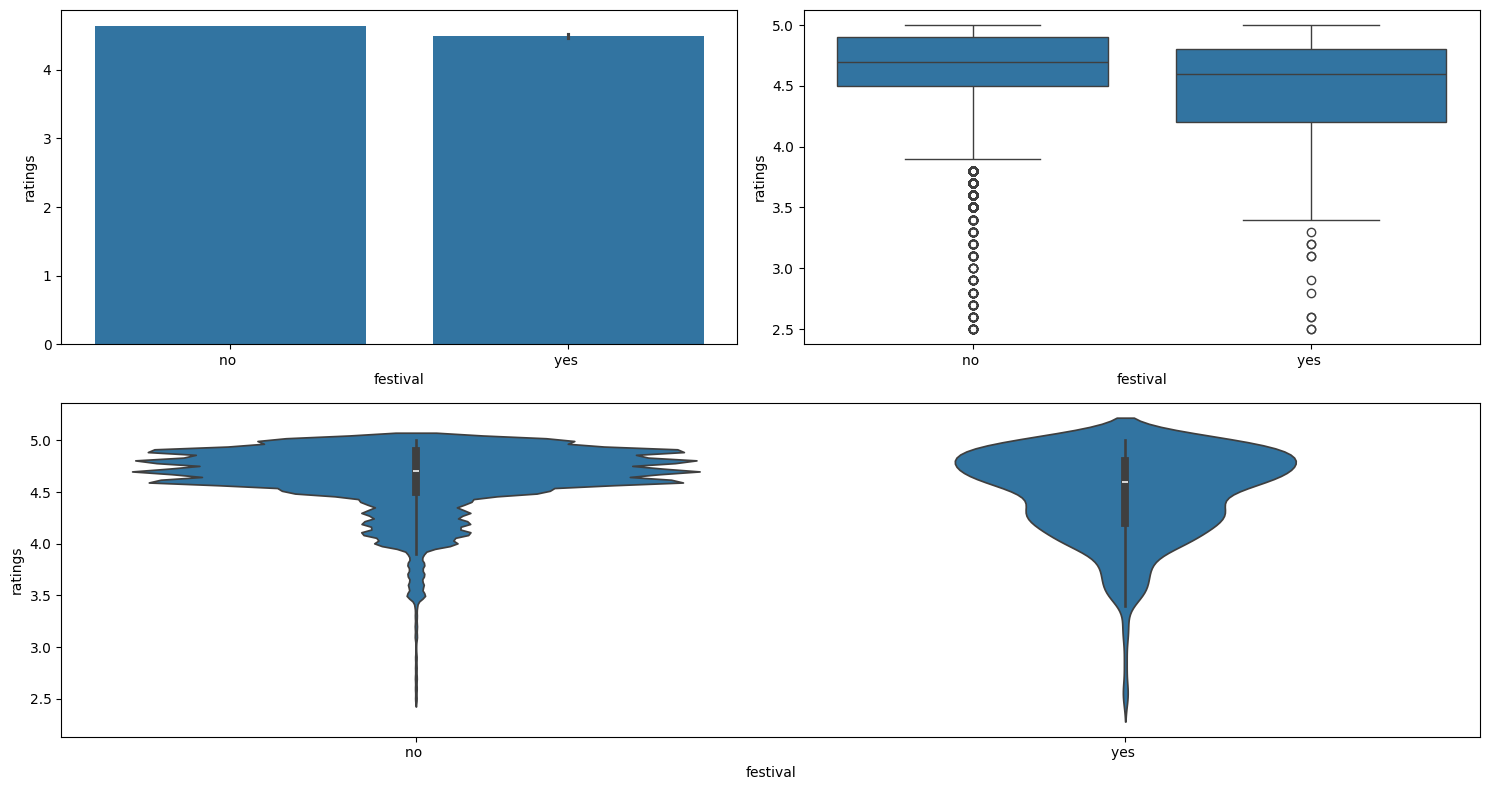

In [106]:
# festvals and rider ratings

numerical_categorical_analysis(df, 'festival', 'ratings')

#### Observation
It seem ratings are affected during festivals.

### Order_date

In [107]:
df.filter(like="order")

,order_date,type_of_order,order_day,order_month,order_year,order_day_of_week,order_time_hour,order_time_of_day
0,2022-03-19,snack,19,3,2022,Saturday,11,morning
1,2022-03-25,snack,25,3,2022,Friday,19,evening
2,2022-03-19,drinks,19,3,2022,Saturday,8,morning
3,2022-04-05,buffet,5,4,2022,Tuesday,18,evening
4,2022-03-26,snack,26,3,2022,Saturday,13,afternoon
...,...,...,...,...,...,...,...,...
45588,2022-03-24,meal,24,3,2022,Thursday,11,morning
45589,2022-02-16,buffet,16,2,2022,Wednesday,19,evening
45590,2022-03-11,drinks,11,3,2022,Friday,23,night
45591,2022-03-07,snack,7,3,2022,Monday,13,afternoon


In [108]:
# order date columns

order_date_subset = df.loc[:,["order_date","order_day","order_month","order_day_of_week","is_weekend","festival"]]

order_date_subset

,order_date,order_day,order_month,order_day_of_week,is_weekend,festival
0,2022-03-19,19,3,Saturday,1,no
1,2022-03-25,25,3,Friday,0,no
2,2022-03-19,19,3,Saturday,1,no
3,2022-04-05,5,4,Tuesday,0,no
4,2022-03-26,26,3,Saturday,1,no
...,...,...,...,...,...,...
45588,2022-03-24,24,3,Thursday,0,no
45589,2022-02-16,16,2,Wednesday,0,no
45590,2022-03-11,11,3,Friday,0,no
45591,2022-03-07,7,3,Monday,0,no


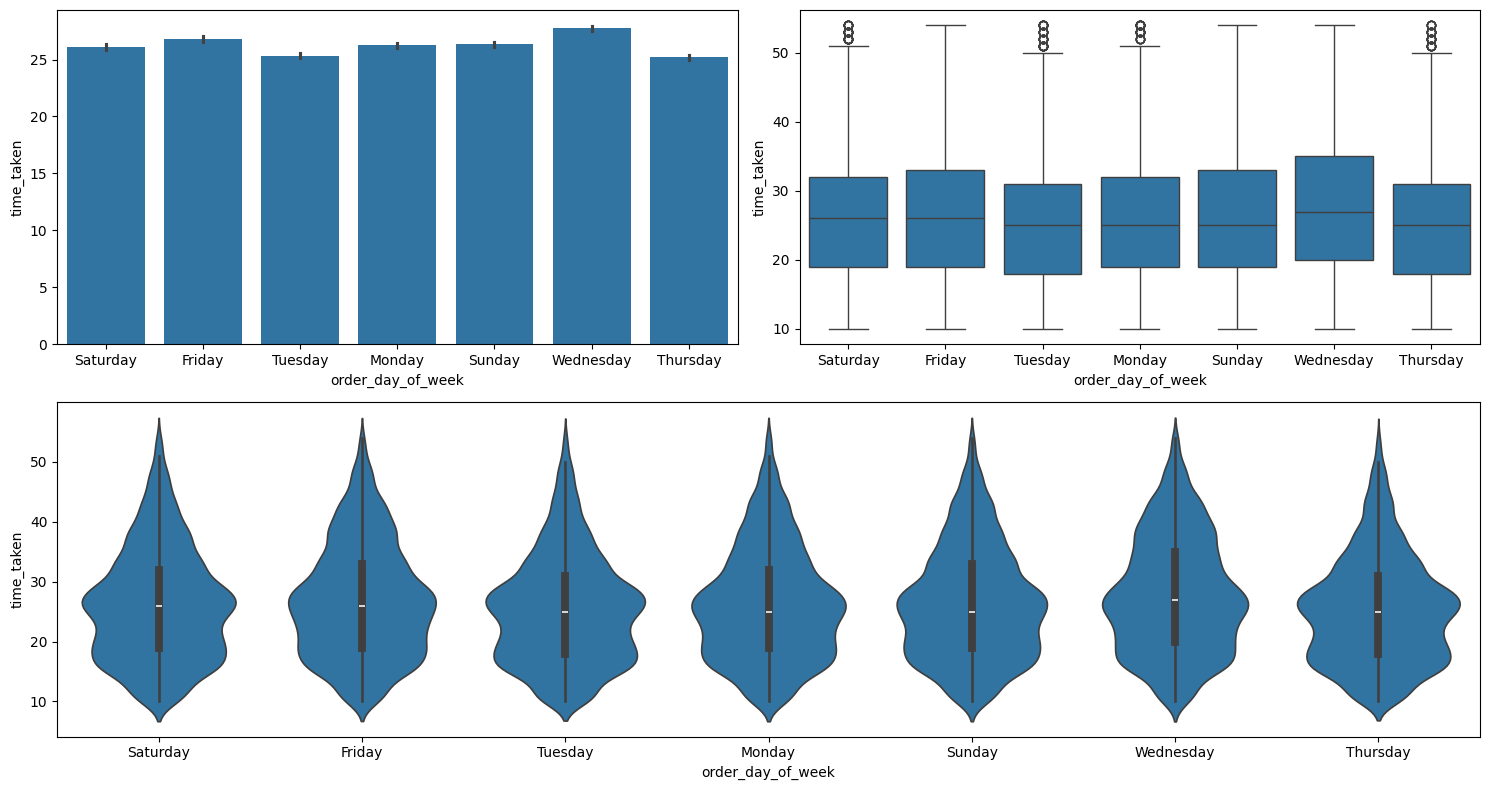

In [109]:
# analysis between day of week and target

numerical_categorical_analysis(df, "order_day_of_week", "time_taken")

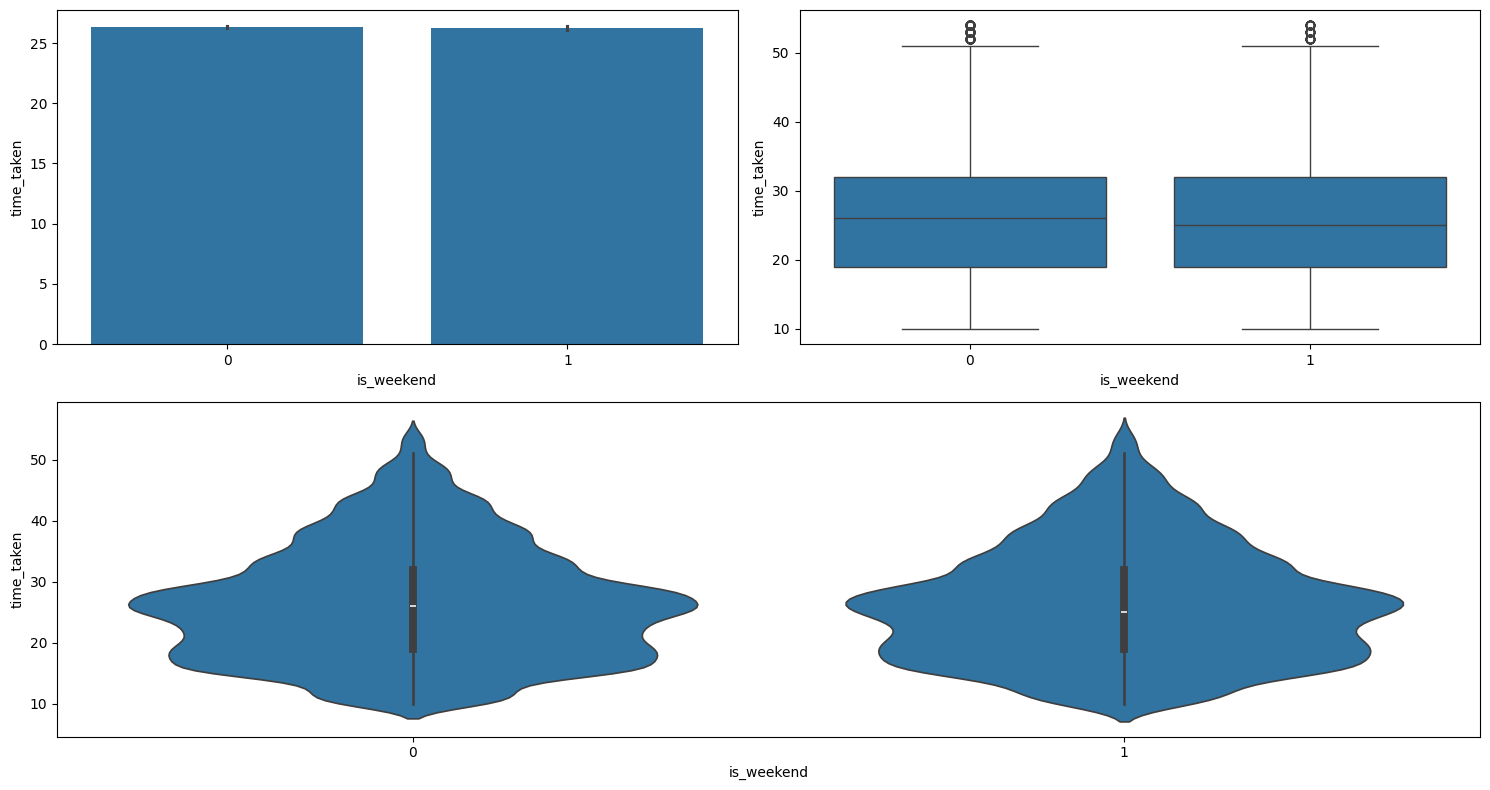

In [110]:
# does having a weekend affects target

numerical_categorical_analysis(df, "is_weekend", "time_taken")

#### Observations

Not affected, maybe slightly

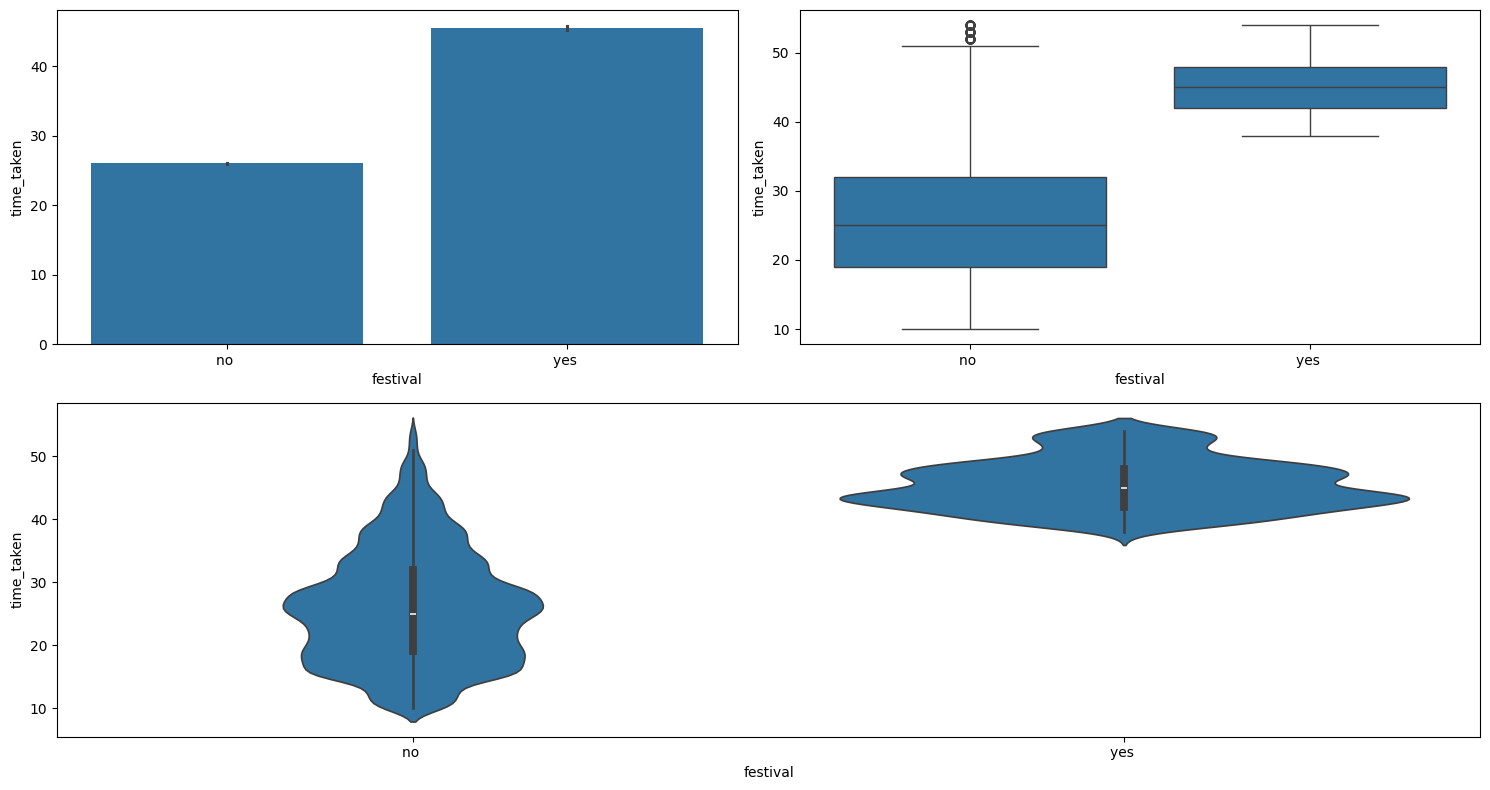

In [111]:
# festivals and target analysis

numerical_categorical_analysis(df, "festival", "time_taken")

#### Observations:

1. The avg time it takes for delivery varies when there is a festival.
2. On a festival delivery times usually takes longer.

In [112]:
# Average time taken because of Traffic and festival
df.pivot_table(index="traffic",columns="festival",values="time_taken",aggfunc="mean")

festival,no,yes
traffic,,
high,26.966017,45.826087
jam,30.501531,46.088380
low,21.306695,42.062500
medium,26.569747,43.701613


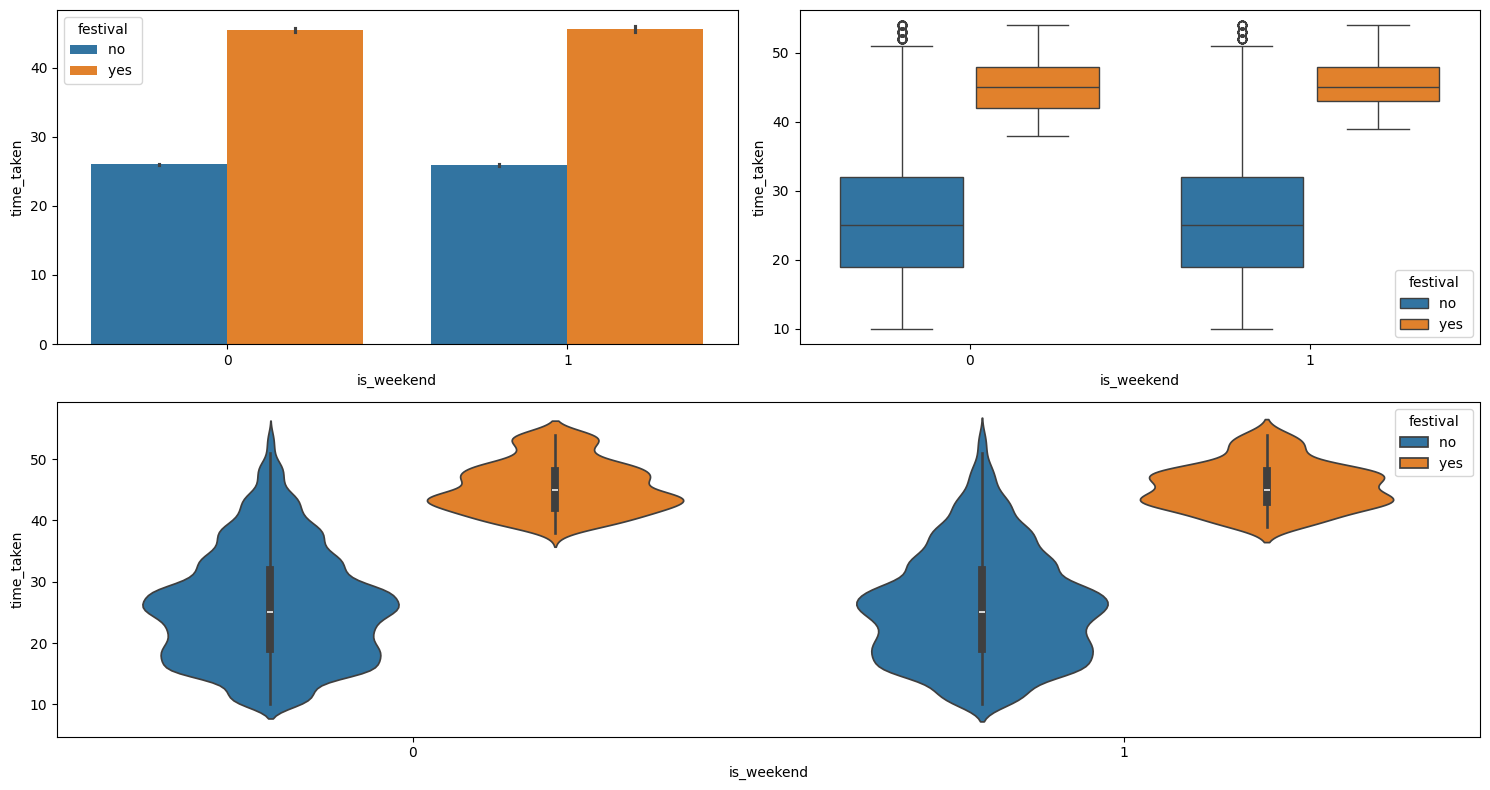

In [113]:
# does a weekend and a festival combined have an effect on delivery times

multivariate_analysis(df, "time_taken", "is_weekend", "festival")

#### Observations
It can be seen that time taken is slightly higher when it is both a weekend and festival.
And Festival time always has higher delivery time taken.

### Order Time

In [114]:
df.columns.tolist()

['rider_id',
 'age',
 'ratings',
 'restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'order_date',
 'weather',
 'traffic',
 'vehicle_condition',
 'type_of_order',
 'type_of_vehicle',
 'multiple_deliveries',
 'festival',
 'city_type',
 'time_taken',
 'city_name',
 'order_day',
 'order_month',
 'order_year',
 'order_day_of_week',
 'is_weekend',
 'pickup_time',
 'order_time_hour',
 'order_time_of_day',
 'distance',
 'time_taken_log']

In [115]:
# time related columns

time_subset = df.loc[:,["order_time_hour","pickup_time","order_time_of_day"]]

time_subset

,order_time_hour,pickup_time,order_time_of_day
0,11,15.0,morning
1,19,5.0,evening
2,8,15.0,morning
3,18,10.0,evening
4,13,15.0,afternoon
...,...,...,...
45588,11,10.0,morning
45589,19,15.0,evening
45590,23,15.0,night
45591,13,5.0,afternoon


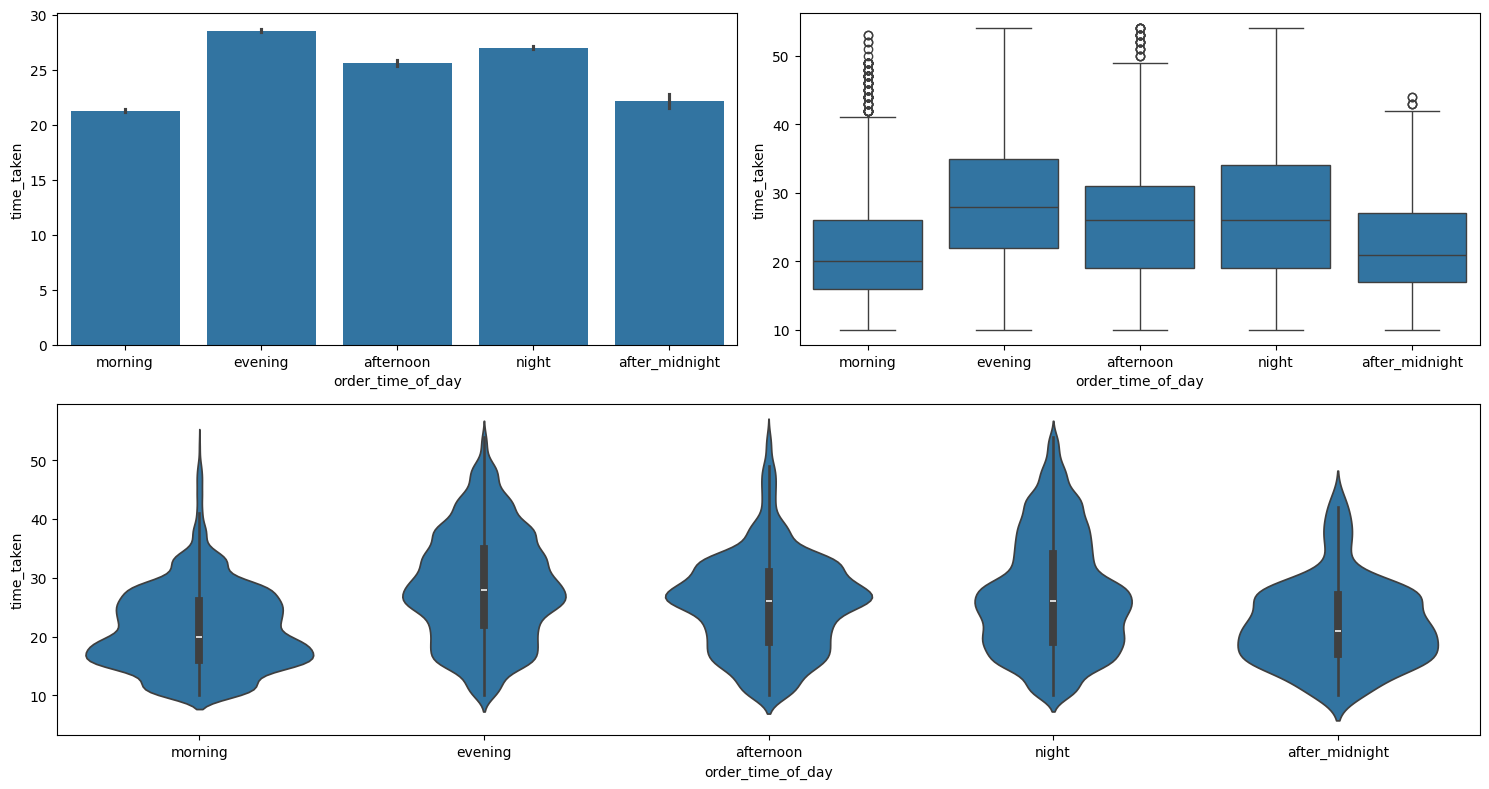

In [116]:
# does time of day affects delivery times

numerical_categorical_analysis(df, "order_time_of_day", "time_taken")

#### Observation
Time of the day affects delivery times.
It seems that delivery time taken is higher during evening and night and lesser at morning and after midnight

In [117]:
# Top 5 times(hrs) of the day in which customers  order the most

df["order_time_hour"].value_counts().head(5)

order_time_hour
21    4660
19    4575
22    4550
20    4497
23    4489
Name: count, dtype: int64

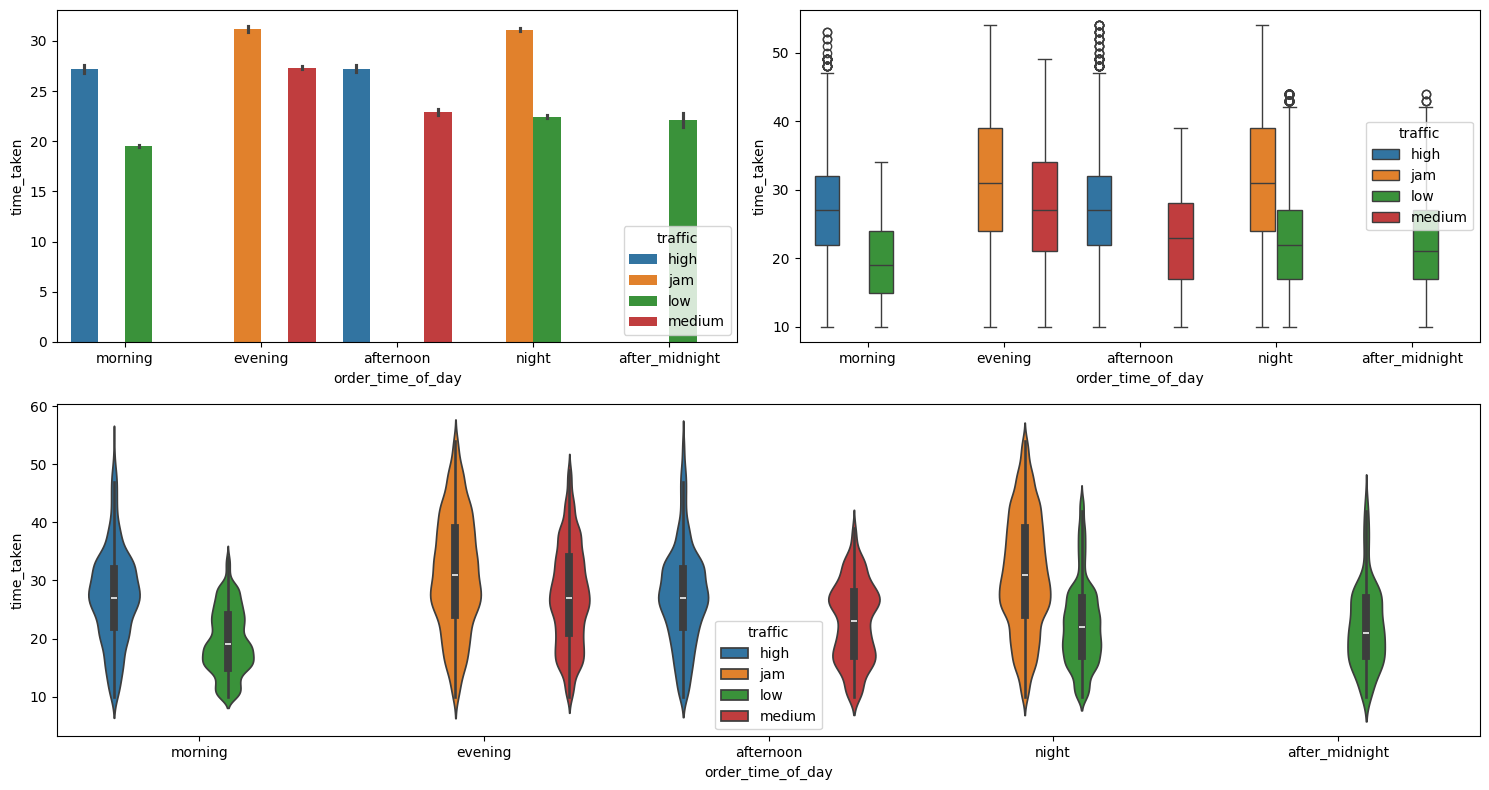

In [118]:
# can delivery time be affected by both time of day and traffic

multivariate_analysis(df, "time_taken", "order_time_of_day", "traffic")

#### Observation
Delivery time is affected because of order time of day and traffic.
It seems that traffic also affected by order time of day.

,Count,Percentage
order_time_hour,,
0,429,0.98%
8,1807,4.15%
9,1932,4.43%
10,1978,4.54%
11,1950,4.47%
12,887,2.03%
13,778,1.78%
14,785,1.8%
15,871,2.0%


**************************************************
The unique categories in order_time_hour column are [11, 19, 8, 18, 13, 21, 17, 20, 14, 9, 22, 12, 23, 10, 16, 15, 0]
**************************************************
The number of categories in order_time_hour column are 17


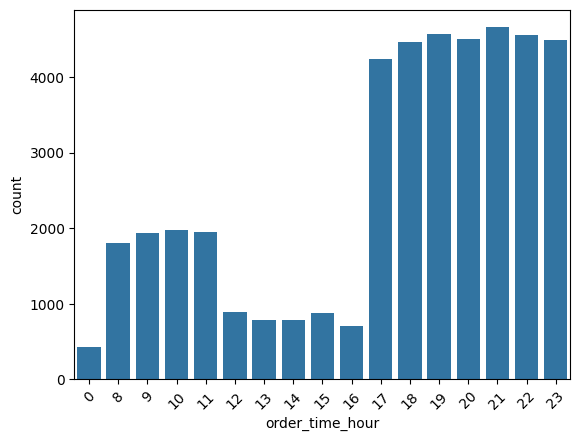

In [119]:
# categorical analysis on order_time_hour

categorical_analysis(df, "order_time_hour")

#### Observations
Order is peak between order time hour 17 and 23

,Count,Percentage
order_time_of_day,,
after_midnight,429,0.98%
afternoon,4027,9.24%
evening,13275,30.45%
morning,7667,17.59%
night,18196,41.74%


**************************************************
The unique categories in order_time_of_day column are ['morning', 'evening', 'afternoon', 'night', 'after_midnight']
**************************************************
The number of categories in order_time_of_day column are 5


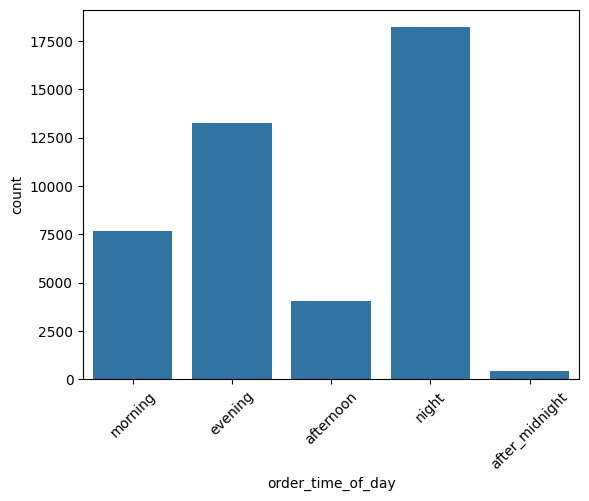

In [120]:
# categorical analysis on time of day

categorical_analysis(df, "order_time_of_day")

#### Observations
Night time has the most orders, followed by evening.

### Pickup Time

In [121]:
# pickup_time datatype

df['pickup_time'].dtype

dtype('float64')

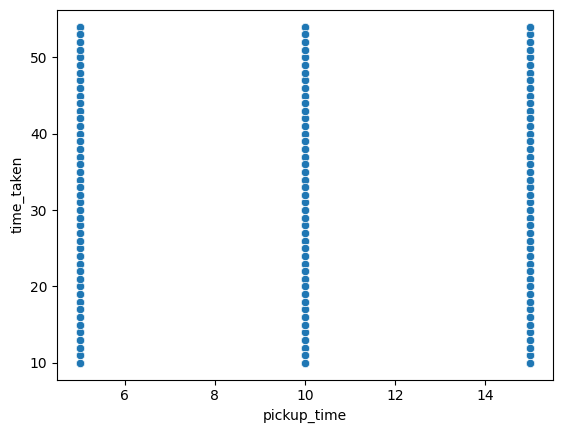

In [122]:
# relationship between pickup time and delivery time

sns.scatterplot(df,x="pickup_time",y="time_taken")
plt.show()

#### Convert the column to categorical column

,Count,Percentage
pickup_time,,
5.0,14599,33.49%
10.0,14474,33.2%
15.0,14521,33.31%


**************************************************
The unique categories in pickup_time column are [15.0, 5.0, 10.0]
**************************************************
The number of categories in pickup_time column are 3


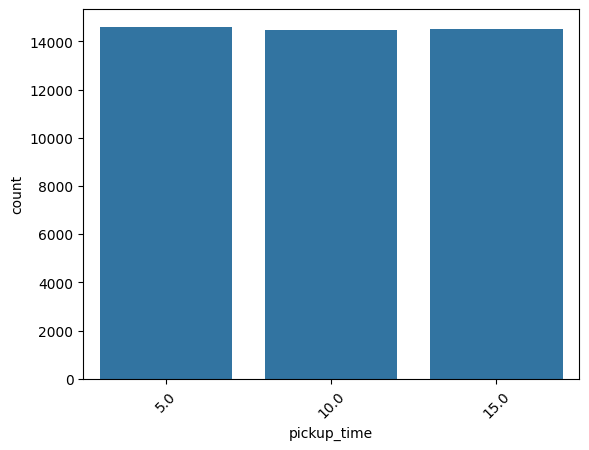

In [123]:
# pickup time categorical analysis

categorical_analysis(df, "pickup_time")

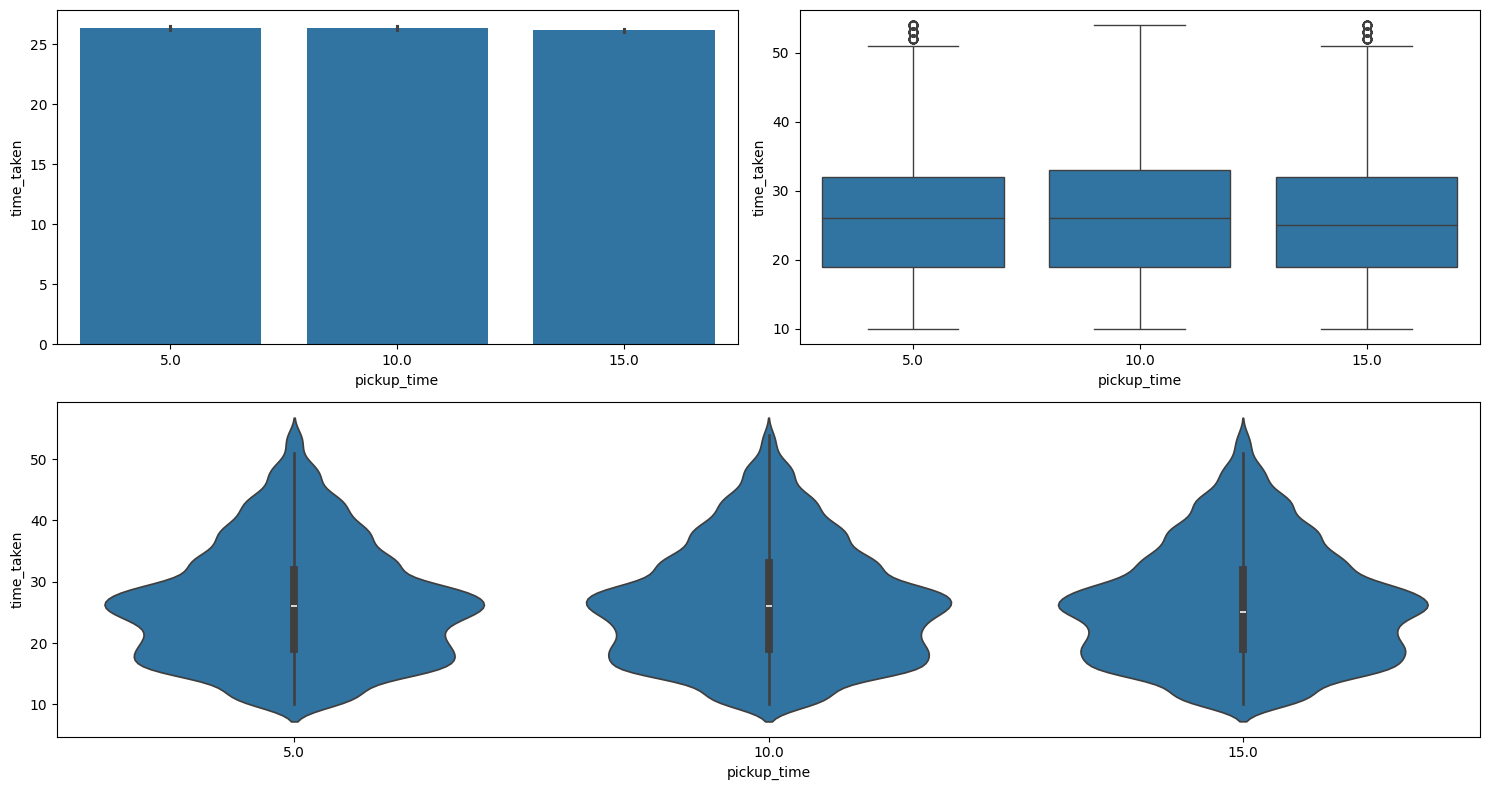

In [124]:
# does pickup time have an effect on delivery time

numerical_categorical_analysis(df, "pickup_time", "time_taken")

#### Observation
No

### Traffic

In [125]:
# datatype of traffic column

df['traffic'].dtype

dtype('O')

,Count,Percentage
traffic,,
high,4294,9.85%
jam,13710,31.45%
low,14976,34.35%
medium,10614,24.35%


**************************************************
The unique categories in traffic column are ['high', 'jam', 'low', 'medium']
**************************************************
The number of categories in traffic column are 4


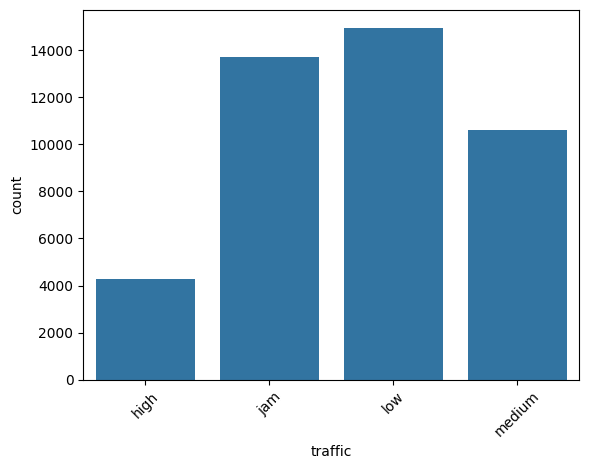

In [126]:
# categorical analysis on traffic

categorical_analysis(df, "traffic")

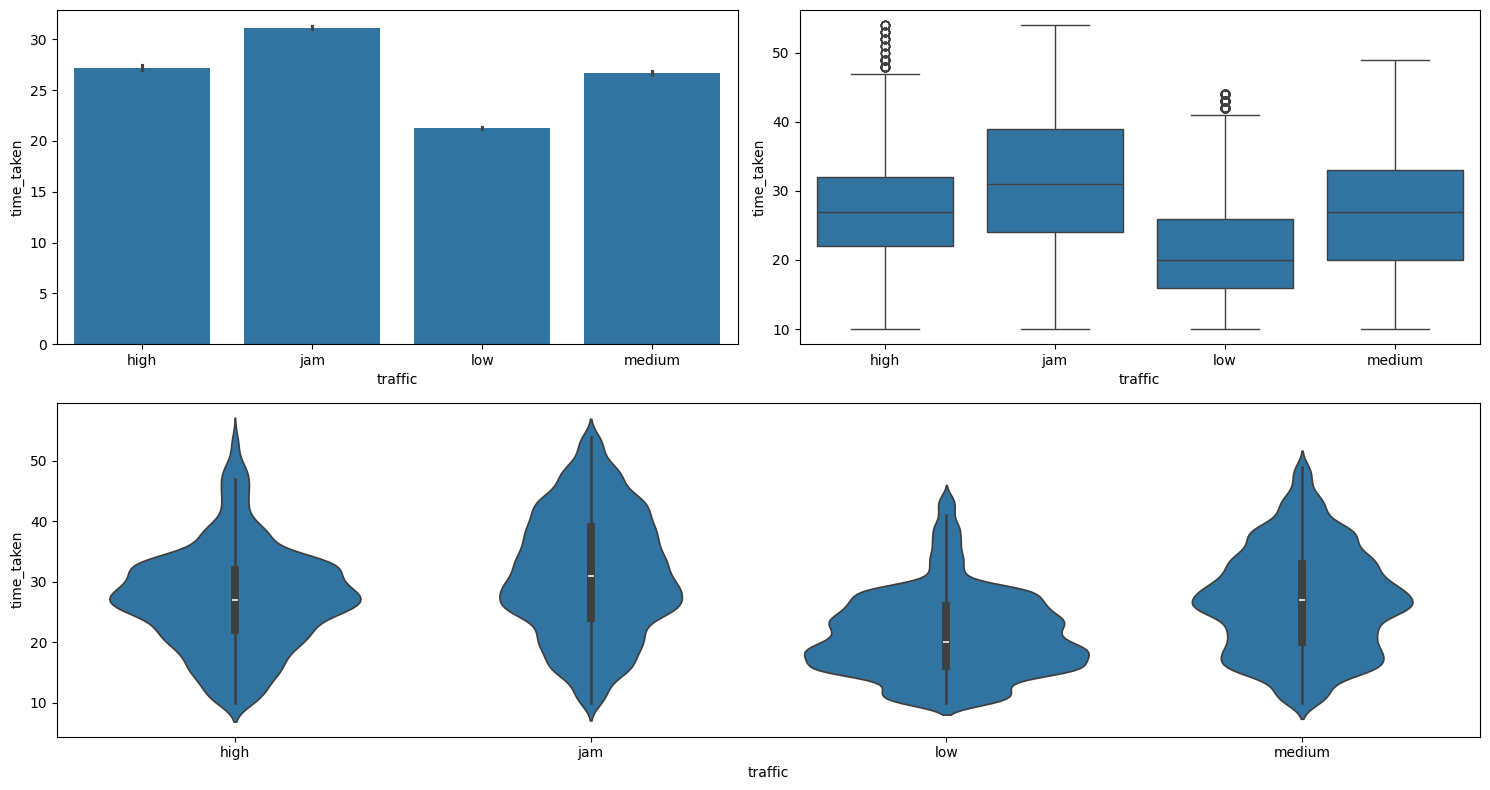

In [127]:
# does traffic affects delivery times

numerical_categorical_analysis(df, "traffic", "time_taken")

#### Observation
Yes traffic affects delivery time. They have a negative relationship

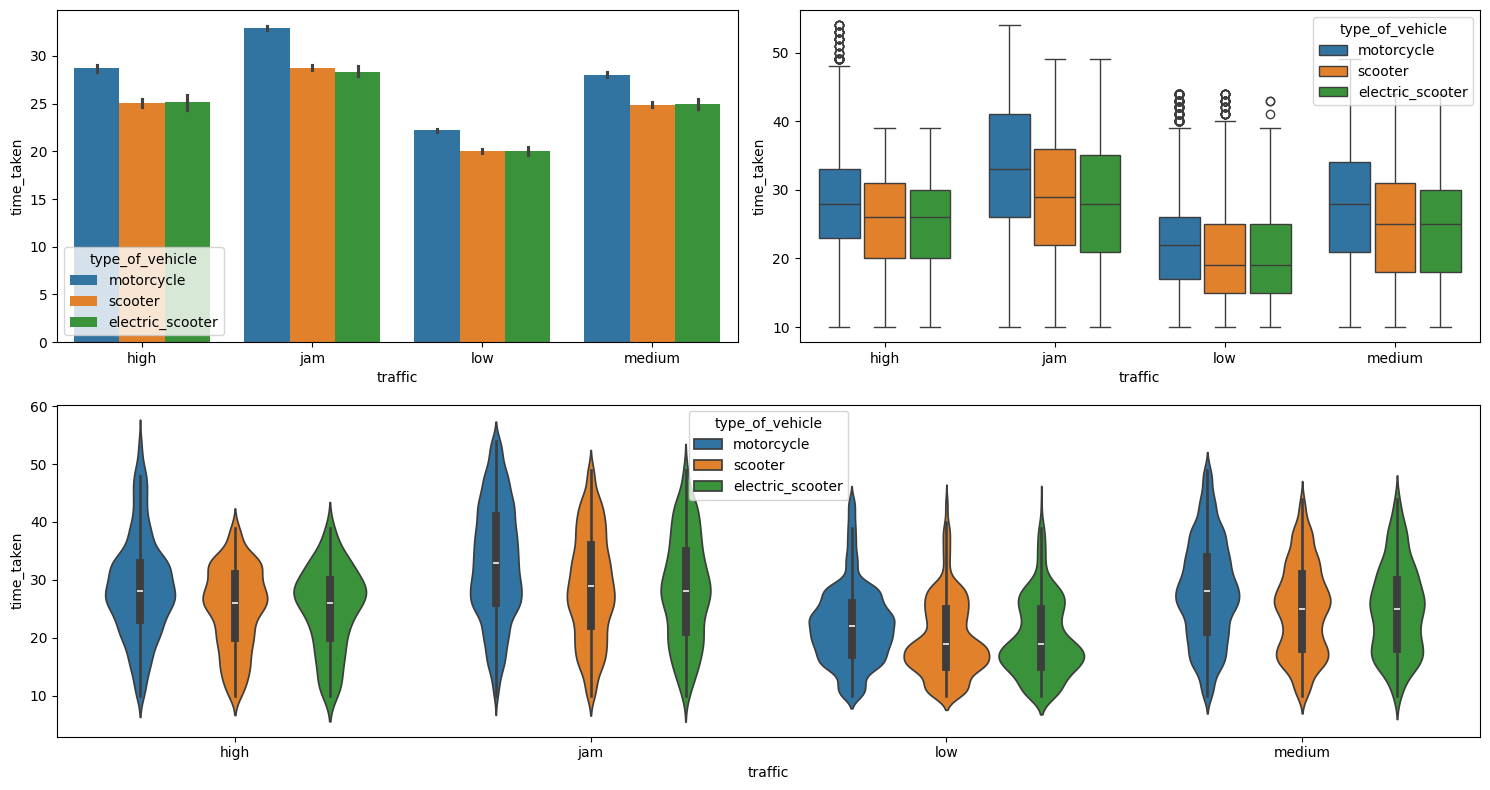

In [128]:
# are some vehicle types more suitable in traffic than others

multivariate_analysis(df, "time_taken", "traffic", "type_of_vehicle")

#### Observation
It seems that motorcycle takens higher time to deliver.
Scooter takes the least 

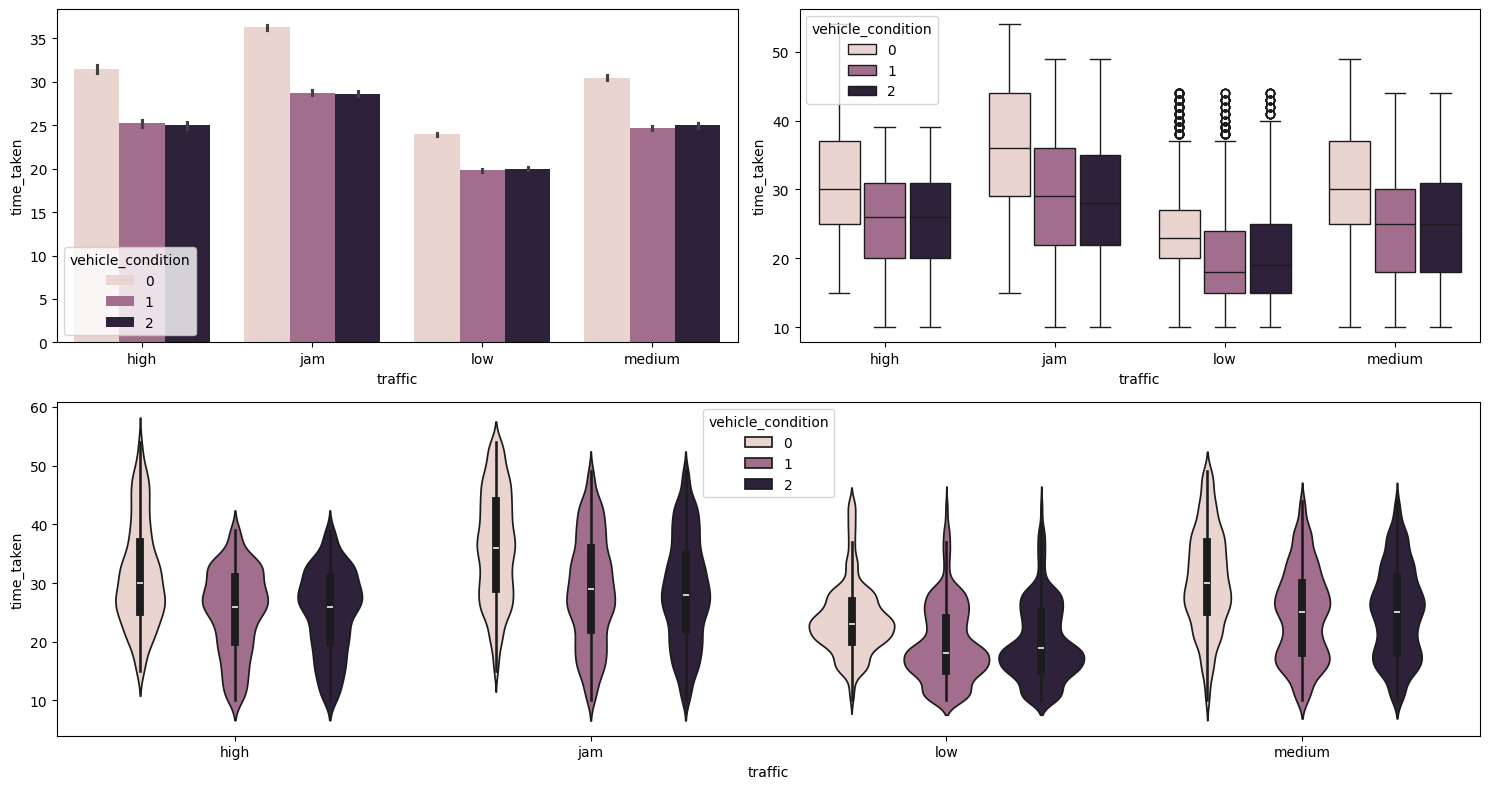

In [129]:
# does vehicle condition in traffic situations affects delivery times

multivariate_analysis(df, "time_taken", "traffic", "vehicle_condition")

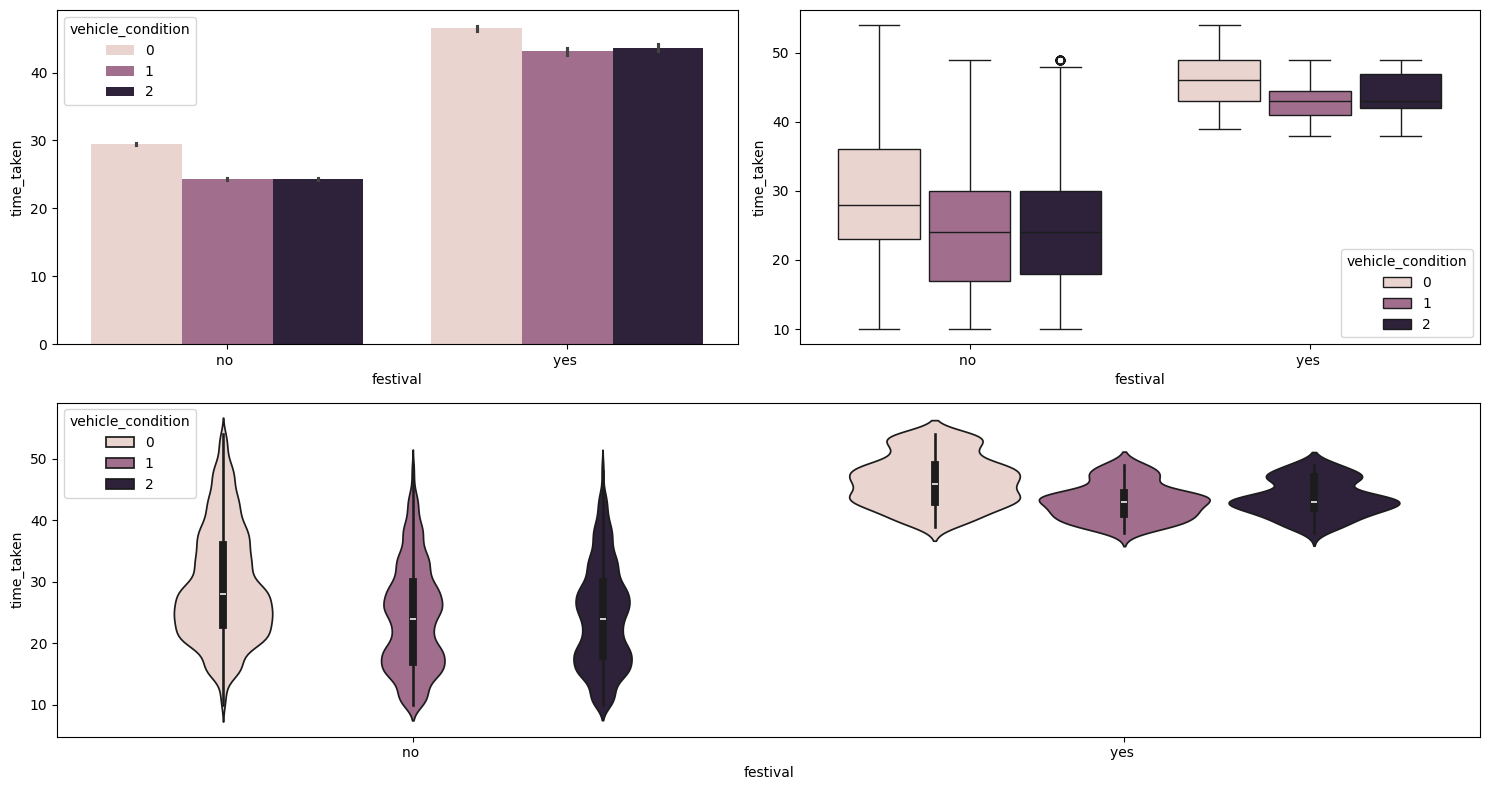

In [130]:
multivariate_analysis(df, "time_taken", "festival", "vehicle_condition")

In [131]:
df.vehicle_condition.value_counts()

vehicle_condition
2    14552
0    14527
1    14515
Name: count, dtype: int64

#### Observations
It seems that new vehicle or good condition vehichle riders drive more safely or less rashly, so they take more time

### Multiple Deliveries

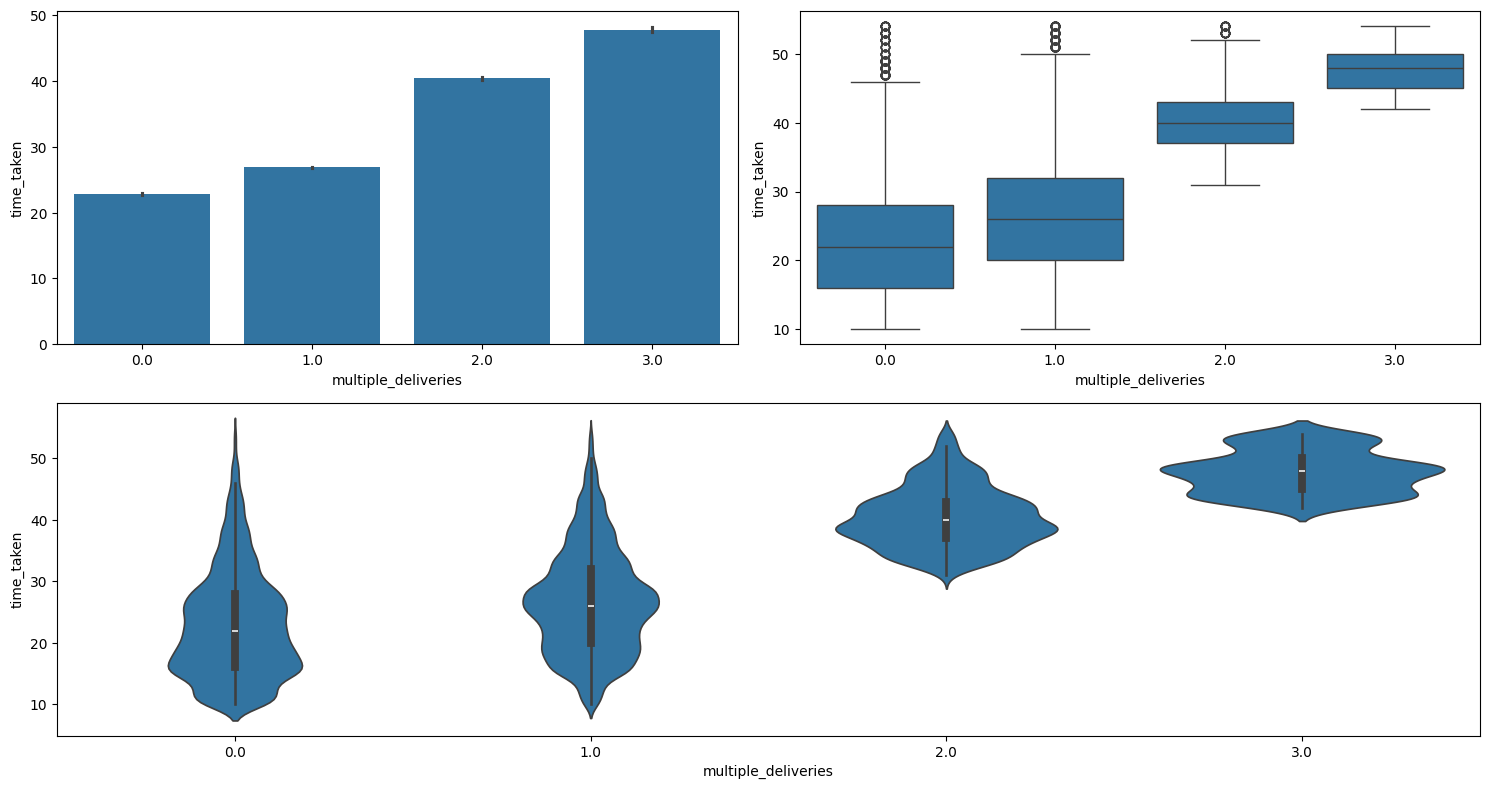

In [132]:
# does multiple delivereis affect delivery times

numerical_categorical_analysis(df, "multiple_deliveries", "time_taken")

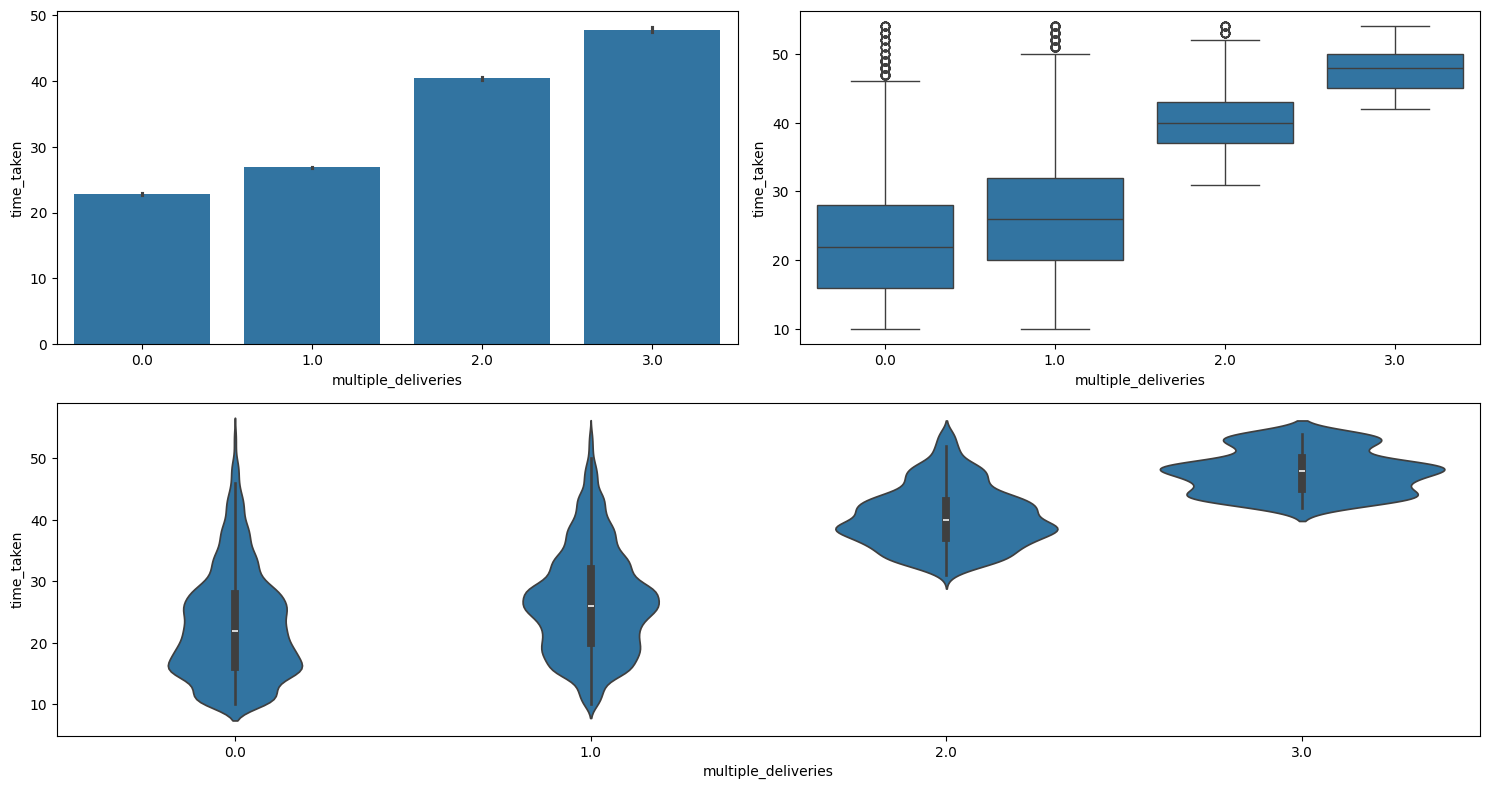

In [133]:
# does multiple delivereis affect delivery times

numerical_categorical_analysis(df, "multiple_deliveries", "time_taken")

### Weather

In [134]:
# data type of weather column

df['weather'].dtype

dtype('O')

,Count,Percentage
weather,,
Cloudy,7277,16.69%
Fog,7435,17.06%
Sandstorms,7238,16.6%
Stormy,7366,16.9%
Sunny,7067,16.21%
Windy,7211,16.54%


**************************************************
The unique categories in weather column are ['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy']
**************************************************
The number of categories in weather column are 6


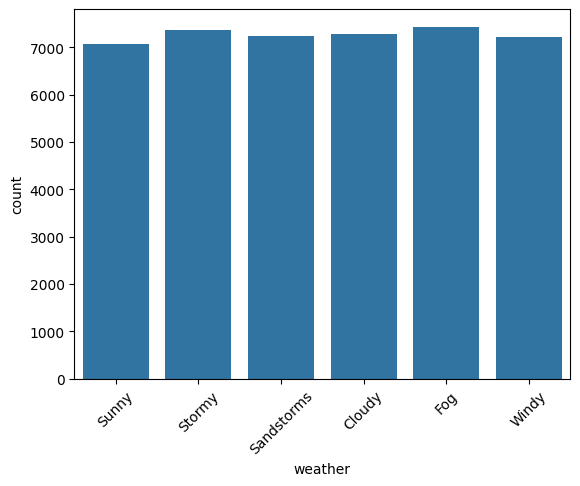

In [135]:
# categorical analysis on type of weather

categorical_analysis(df, "weather")

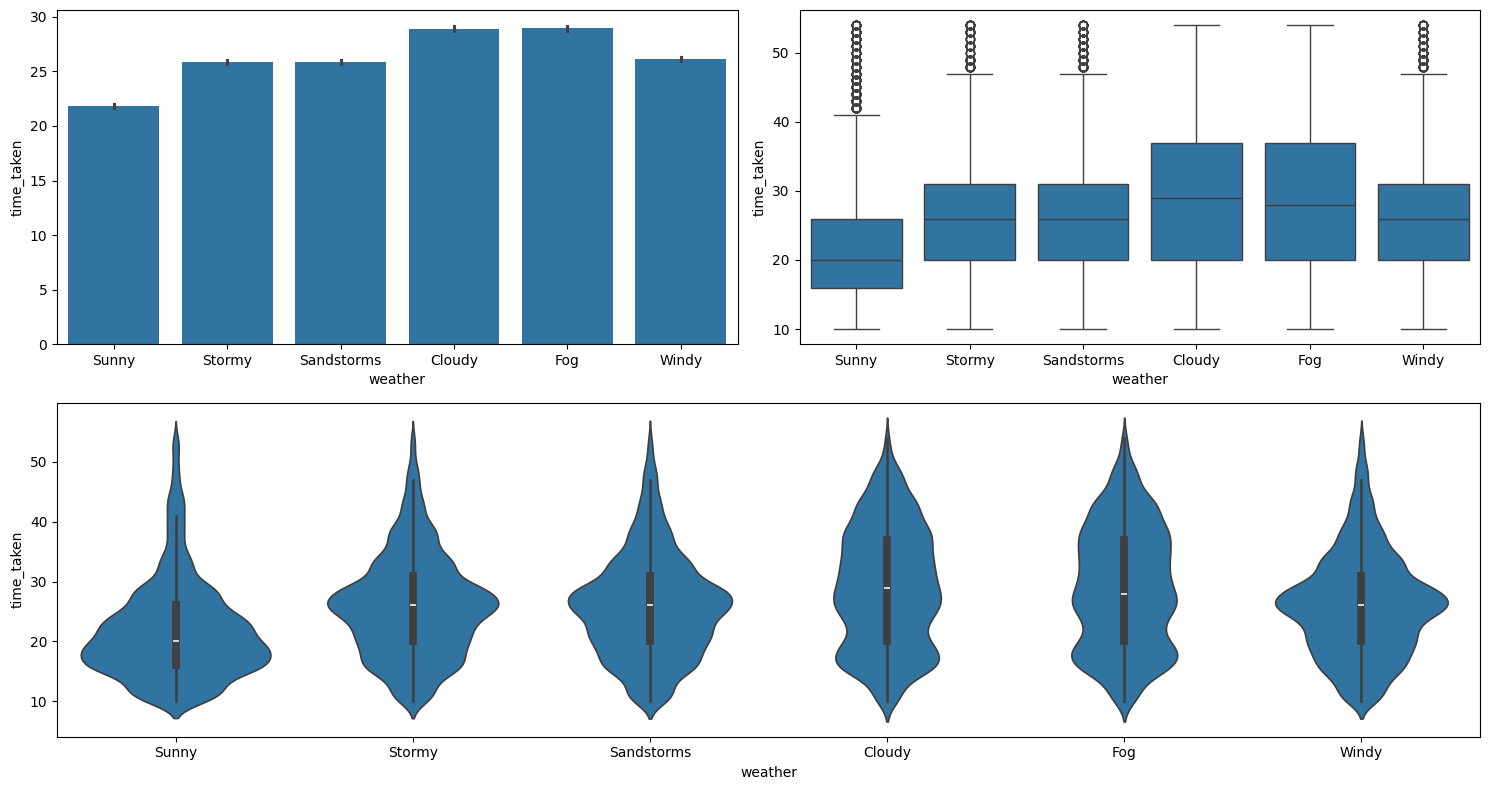

In [136]:
# does weather affect delivery times

numerical_categorical_analysis(df, "weather", "time_taken")

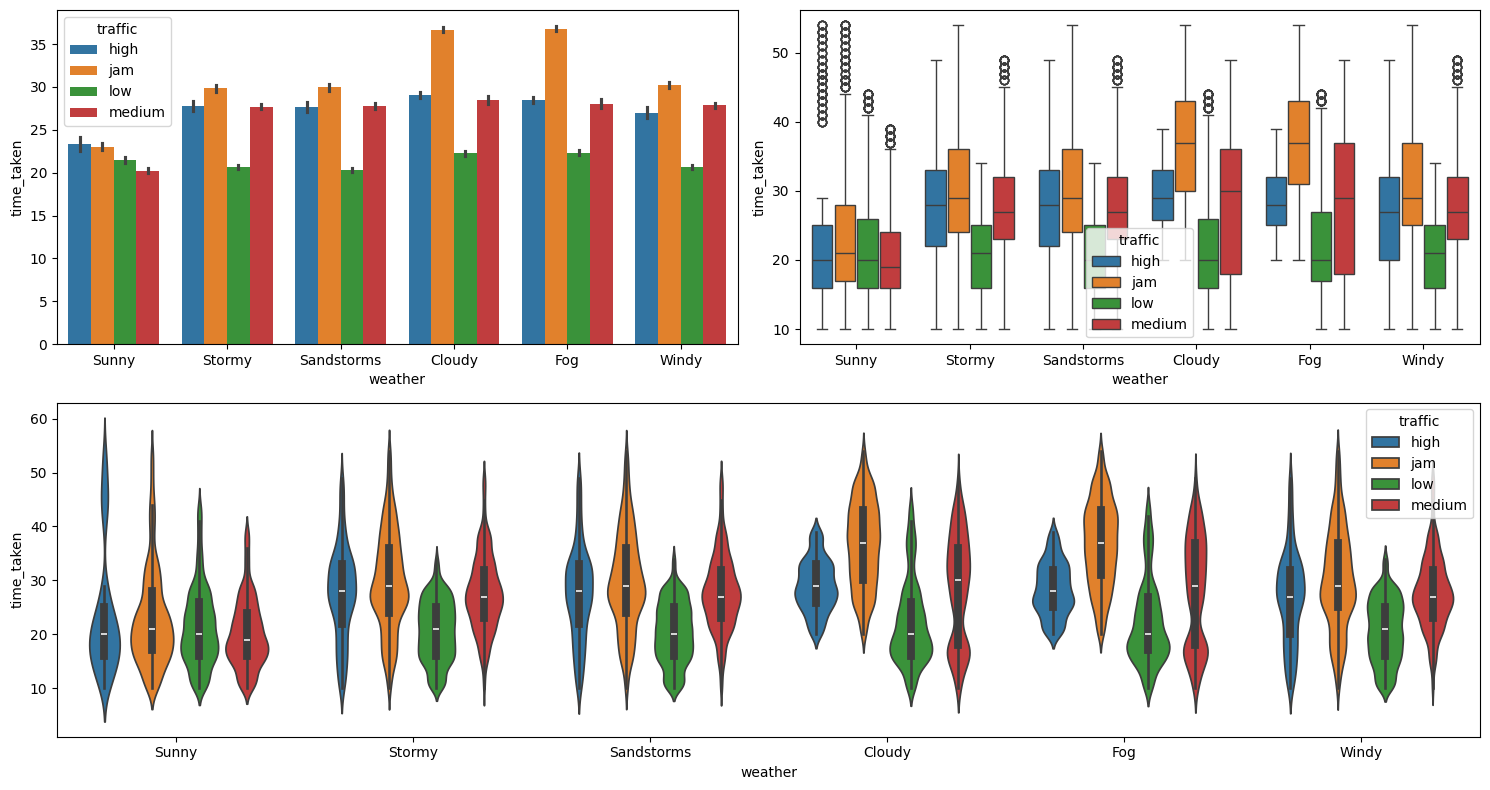

In [137]:
# delivery times based on weather and traffic

multivariate_analysis(df, "time_taken", "weather", "traffic")

### Vehicle - Condition and Type

,Count,Percentage
vehicle_condition,,
0,14527,33.32%
1,14515,33.3%
2,14552,33.38%


**************************************************
The unique categories in vehicle_condition column are [2, 0, 1]
**************************************************
The number of categories in vehicle_condition column are 3


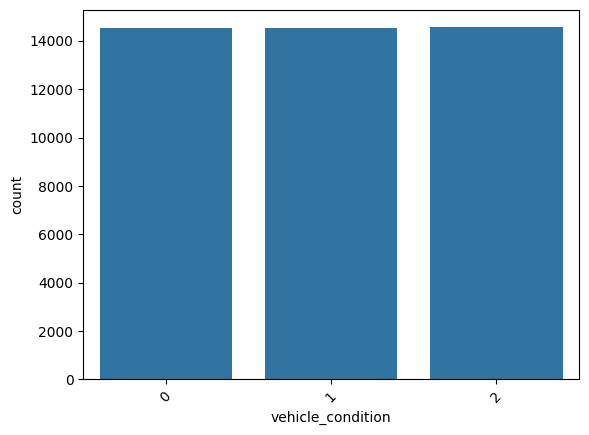

In [138]:
# categorical analysis on vehicle condition

categorical_analysis(df, "vehicle_condition")
     

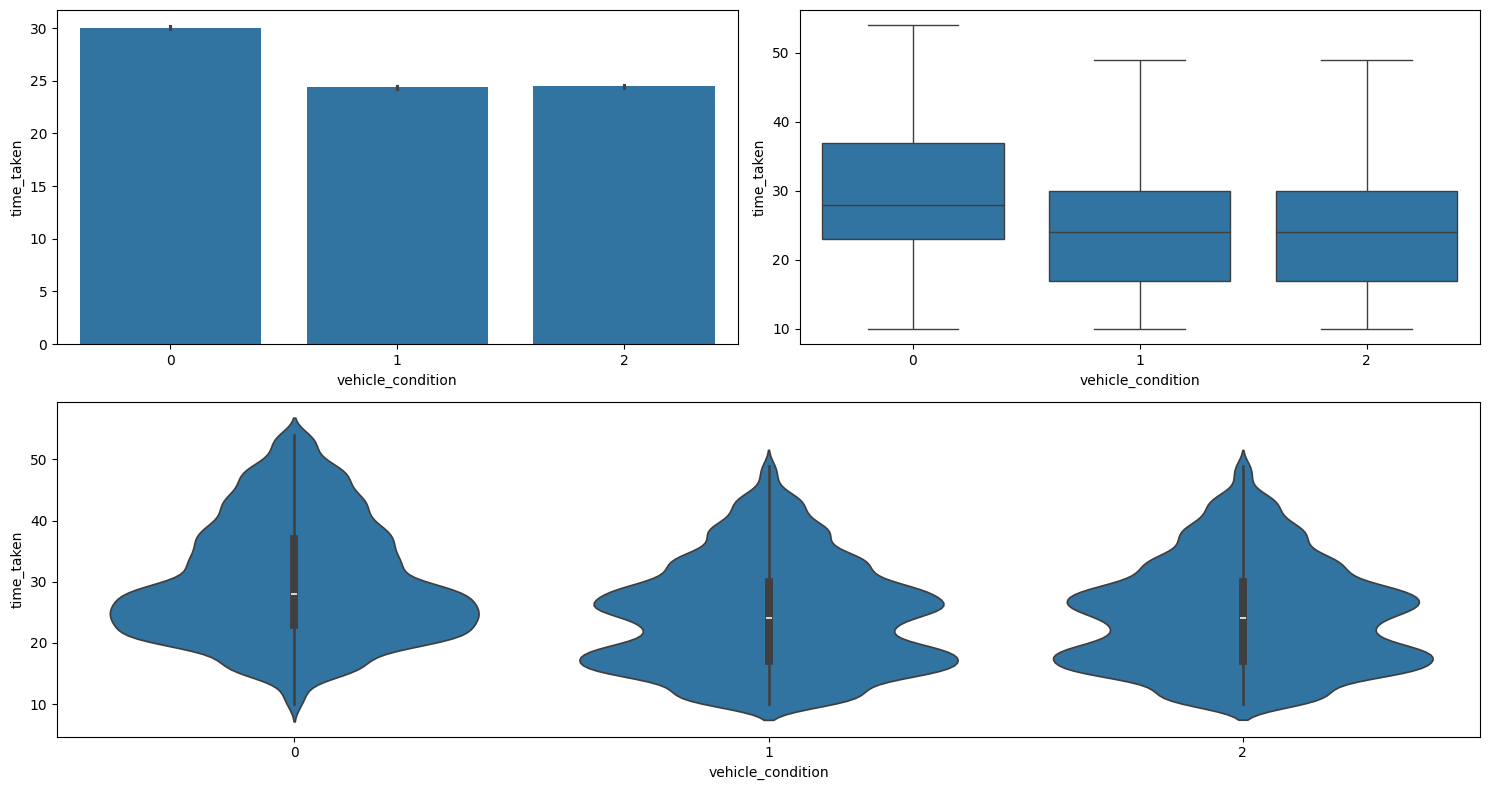

In [139]:
# does vehicle condition affect delivery times

numerical_categorical_analysis(df, "vehicle_condition", "time_taken")

,Count,Percentage
type_of_vehicle,,
electric_scooter,3518,8.07%
motorcycle,25486,58.46%
scooter,14590,33.47%


**************************************************
The unique categories in type_of_vehicle column are ['motorcycle', 'scooter', 'electric_scooter']
**************************************************
The number of categories in type_of_vehicle column are 3


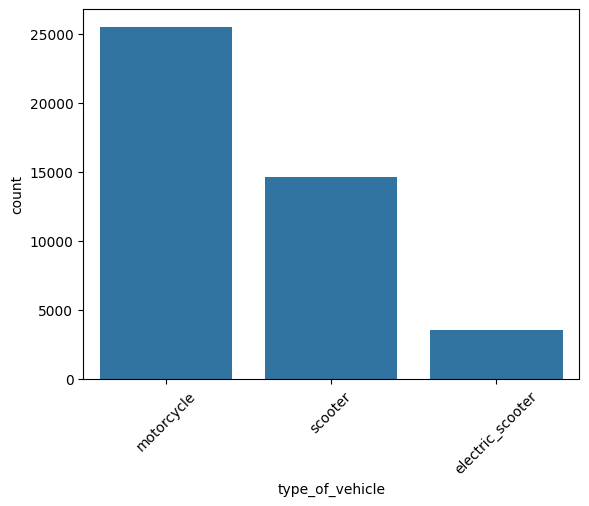

In [140]:
# analysis on vehicle type

categorical_analysis(df, "type_of_vehicle")

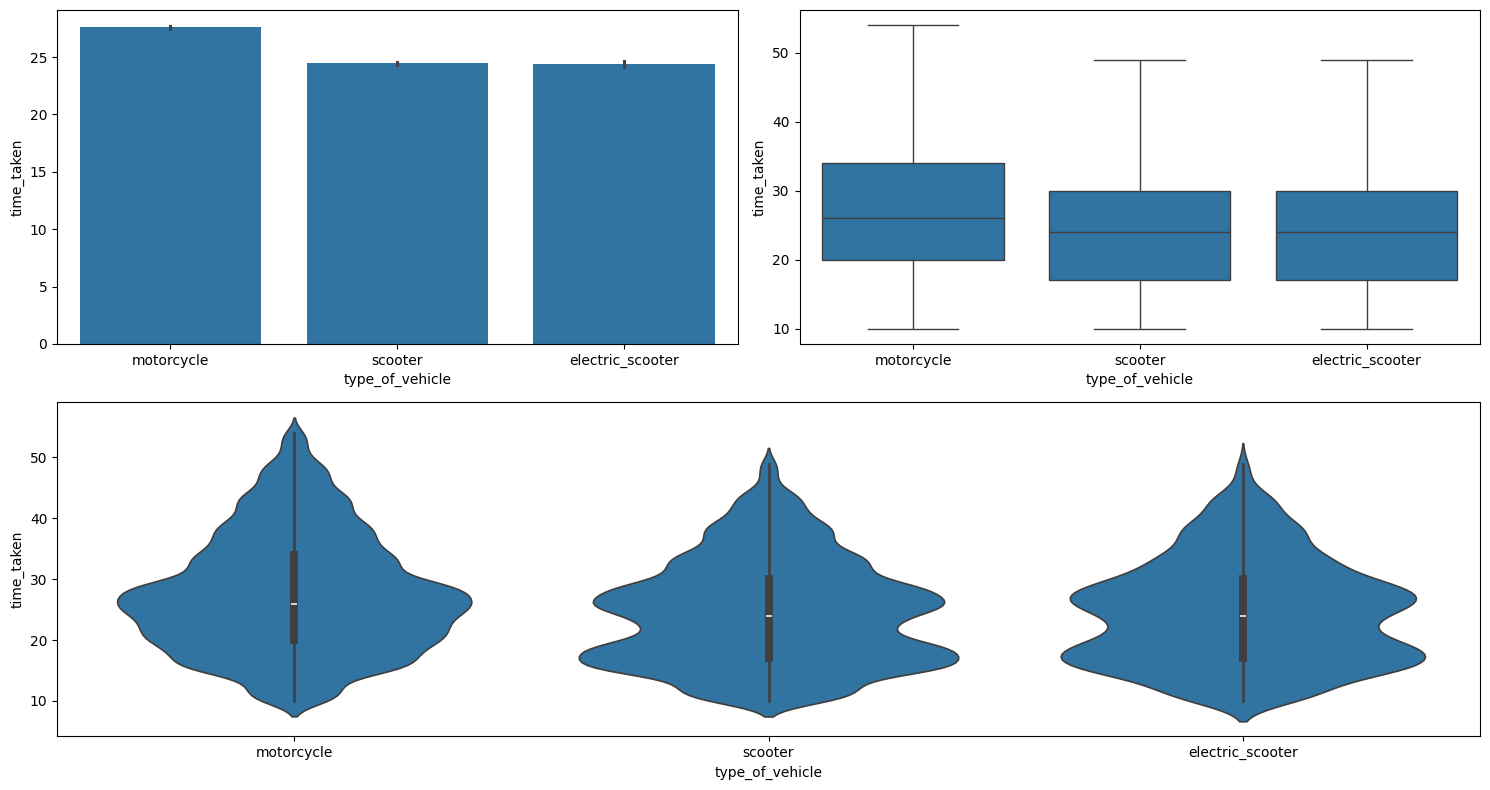

In [141]:
# does the type of vehicle affects delivery time

numerical_categorical_analysis(df, "type_of_vehicle", "time_taken")

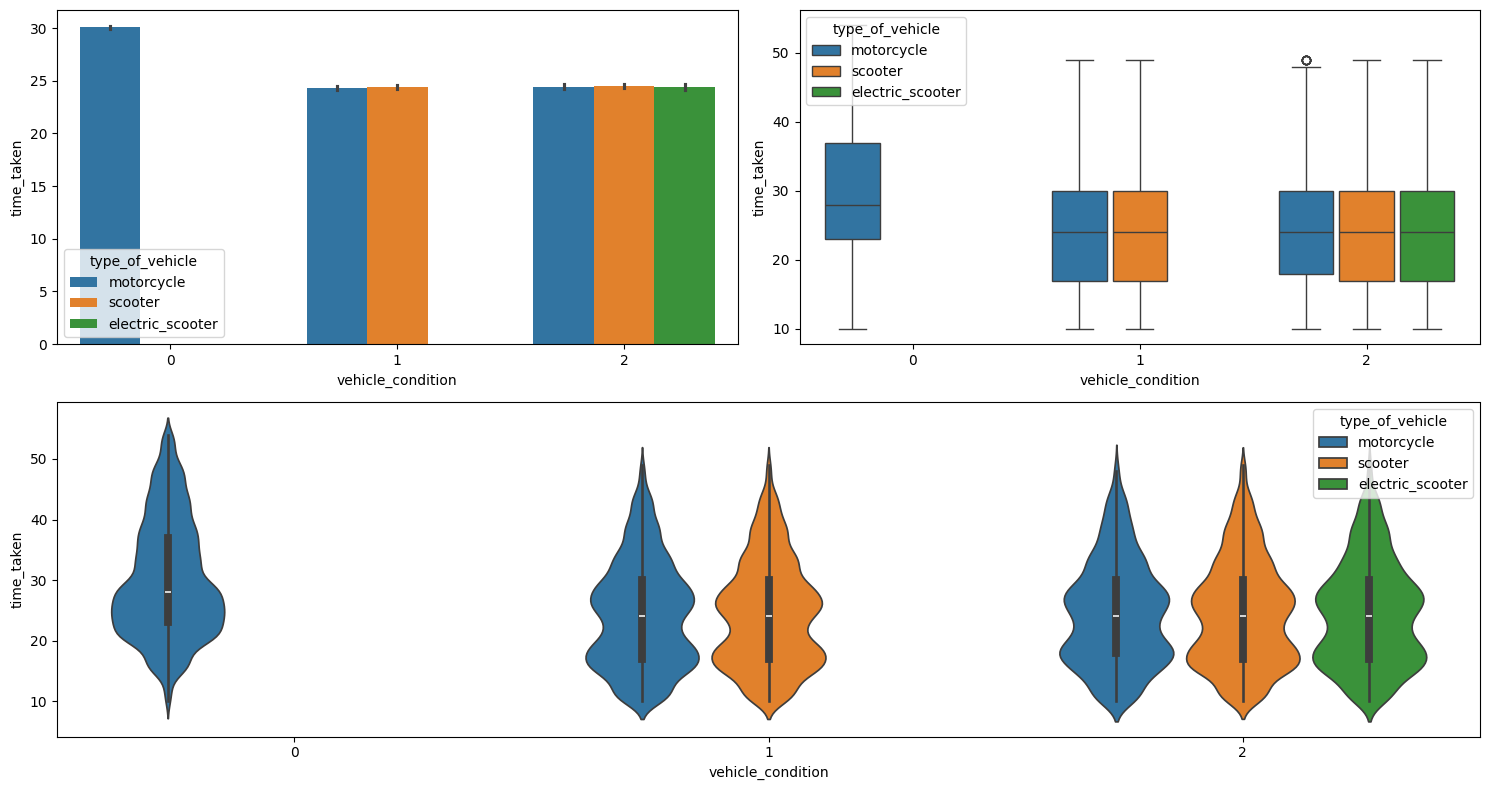

In [142]:
# vehicle condition and type

multivariate_analysis(df, "time_taken", "vehicle_condition", "type_of_vehicle")

### Type of Order

In [143]:
# type of order dtype

df['type_of_order'].dtype

dtype('O')

,Count,Percentage
type_of_order,,
buffet,10793,24.76%
drinks,10833,24.85%
meal,10948,25.11%
snack,11020,25.28%


**************************************************
The unique categories in type_of_order column are ['snack', 'drinks', 'buffet', 'meal']
**************************************************
The number of categories in type_of_order column are 4


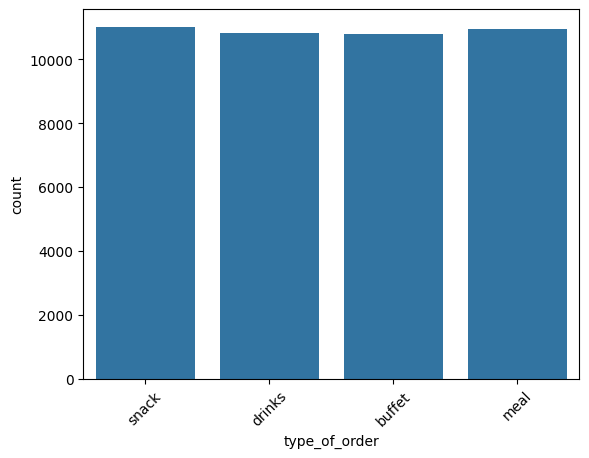

In [144]:
# analysis on type of order

categorical_analysis(df, "type_of_order")

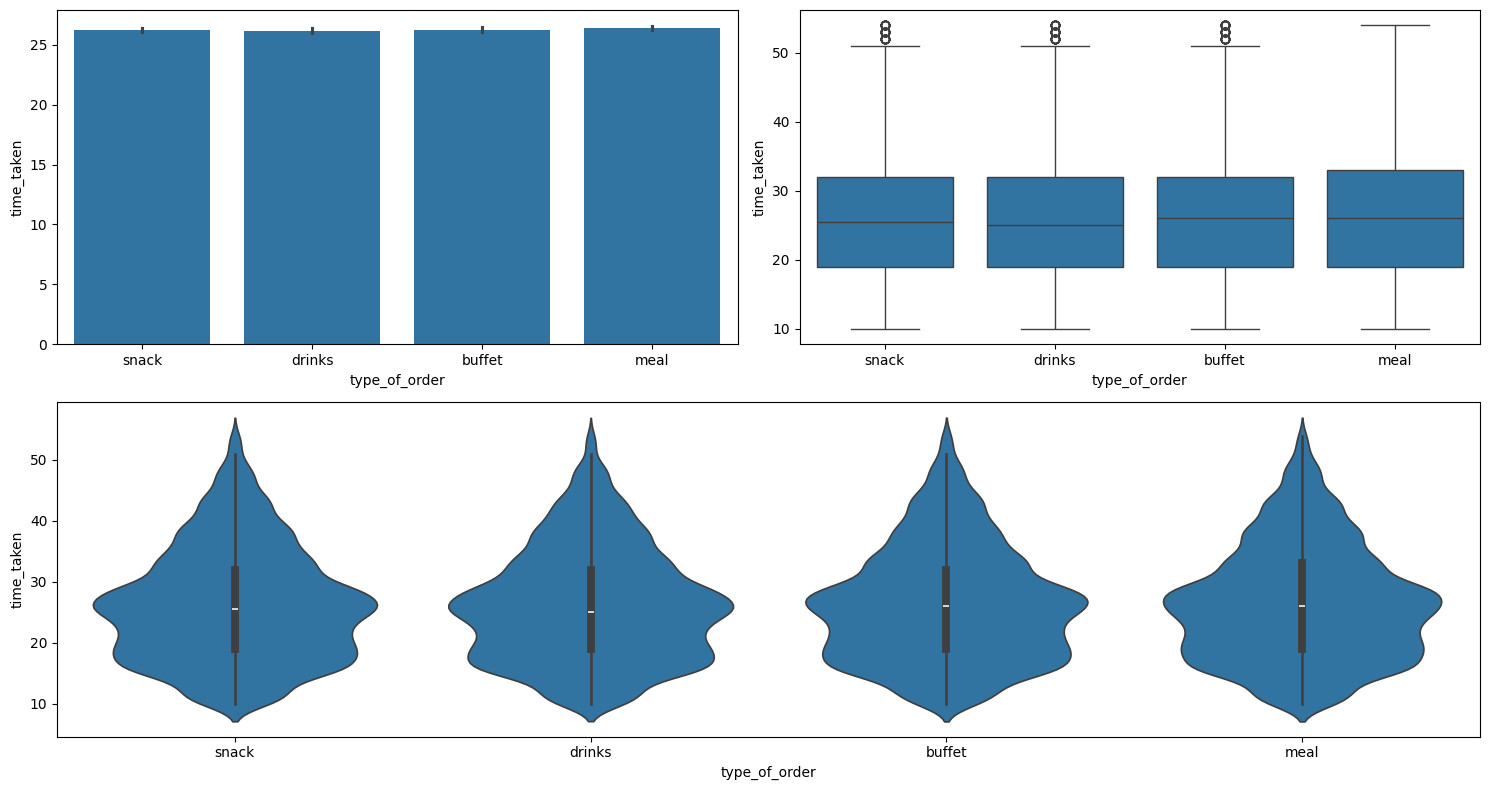

In [145]:
# does order type have have effect on delivery times

numerical_categorical_analysis(df, "type_of_order", "time_taken")

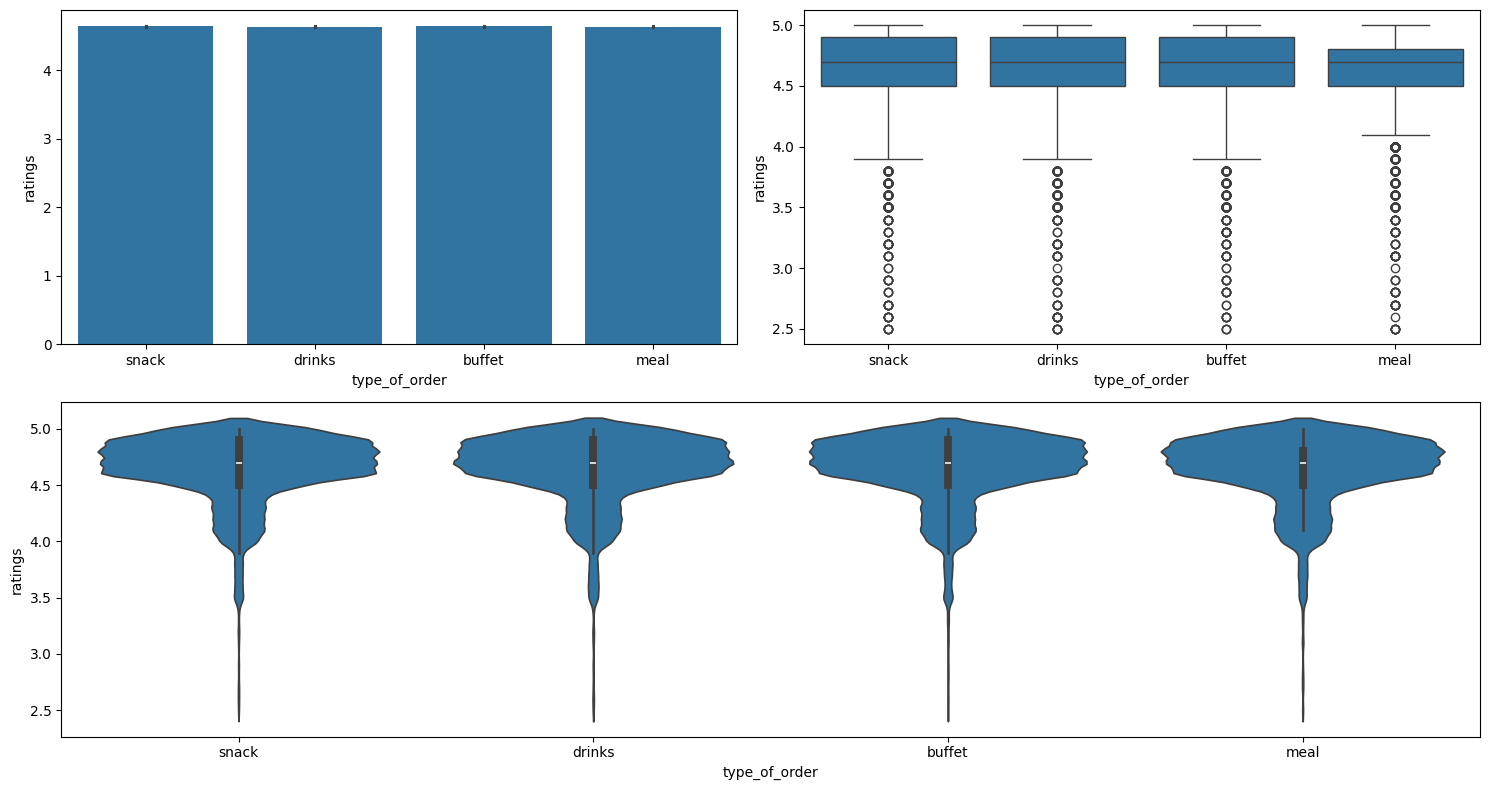

In [146]:
# does order type has an effect on ratings

numerical_categorical_analysis(df, "type_of_order", "ratings")

### City Name

,Count,Percentage
city_name,,
AGR,735,1.69%
ALH,700,1.61%
AURG,672,1.54%
BANG,3047,6.99%
BHP,656,1.5%
CHEN,2995,6.87%
COIMB,3050,7.0%
DEH,698,1.6%
GOA,676,1.55%


**************************************************
The unique categories in city_name column are ['INDO', 'BANG', 'COIMB', 'CHEN', 'HYD', 'RANCHI', 'MYS', 'DEH', 'KOC', 'PUNE', 'LUDH', 'KNP', 'MUM', 'KOL', 'JAP', 'SUR', 'GOA', 'AURG', 'AGR', 'VAD', 'ALH', 'BHP']
**************************************************
The number of categories in city_name column are 22


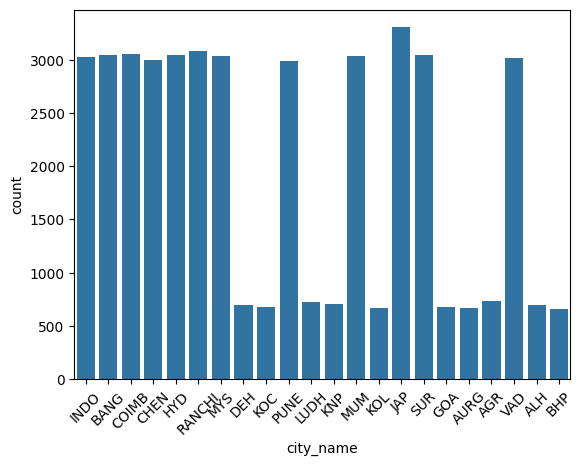

In [147]:
# categorical analysis on city name

categorical_analysis(df, "city_name")

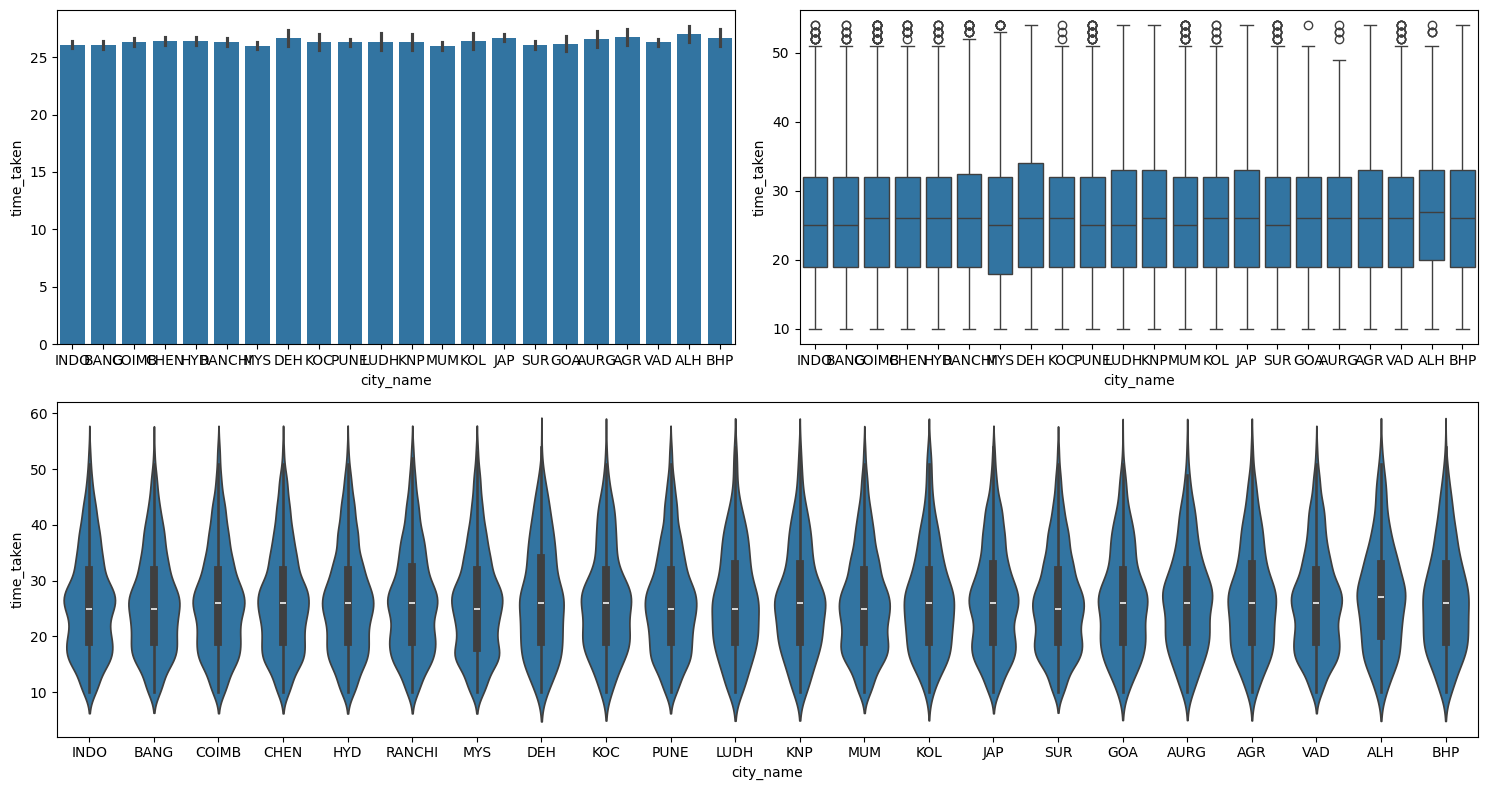

In [148]:
# does a city affects delivery times

numerical_categorical_analysis(df, "city_name", "time_taken")

,Count,Percentage
city_type,,
metropolitian,32592,76.76%
semi-urban,152,0.36%
urban,9715,22.88%


**************************************************
The unique categories in city_type column are ['urban', 'metropolitian', 'semi-urban', nan]
**************************************************
The number of categories in city_type column are 3


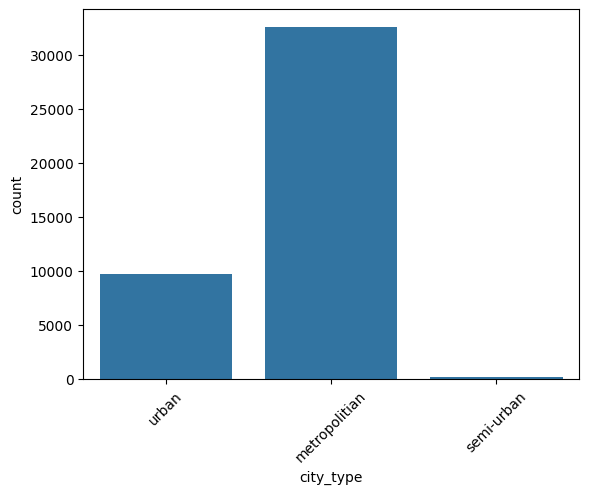

In [149]:
# categorical analysis on city type

categorical_analysis(df, "city_type")

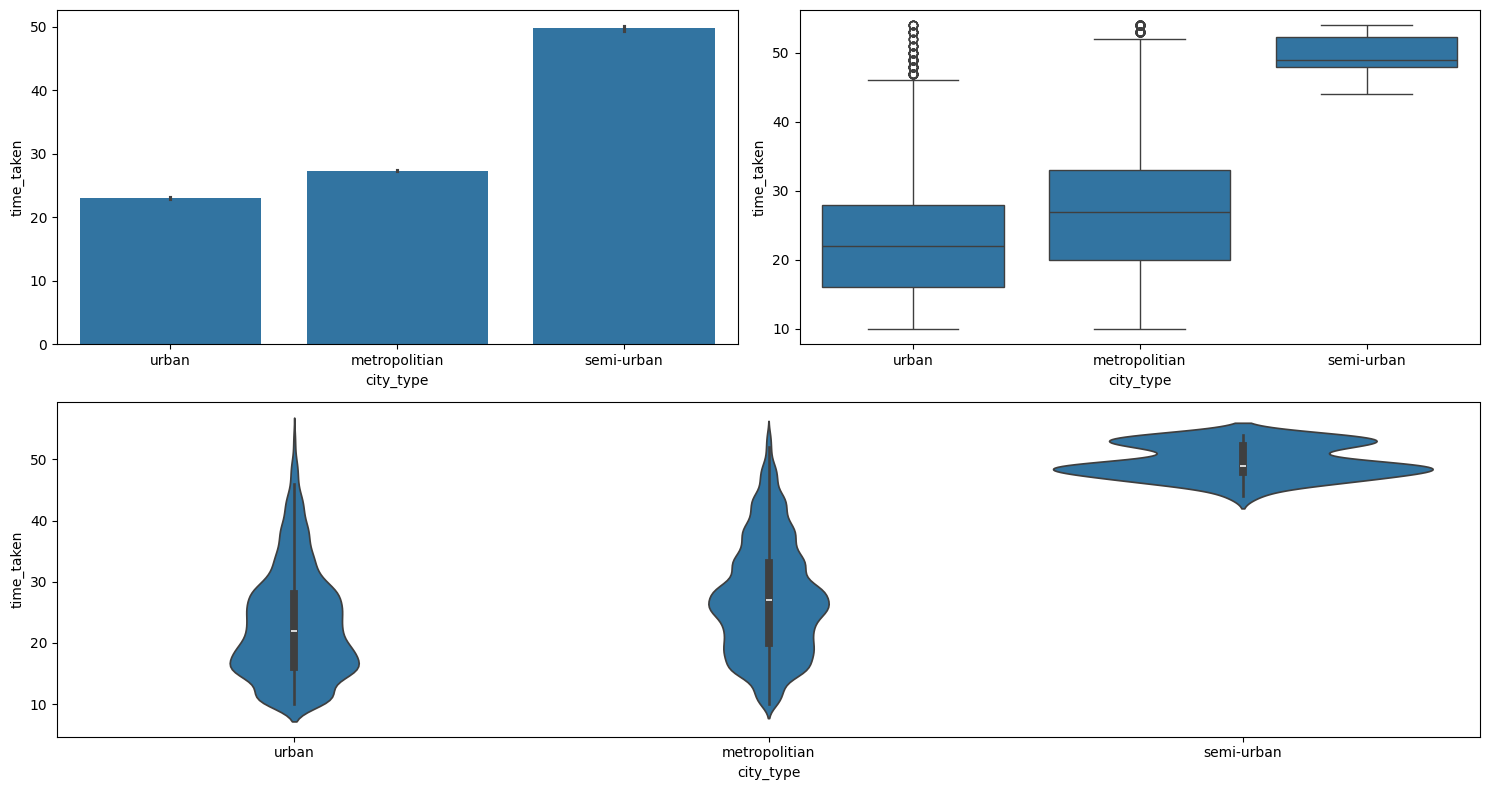

In [150]:
# does city types affect delivery times

numerical_categorical_analysis(df, "city_type", "time_taken")
     

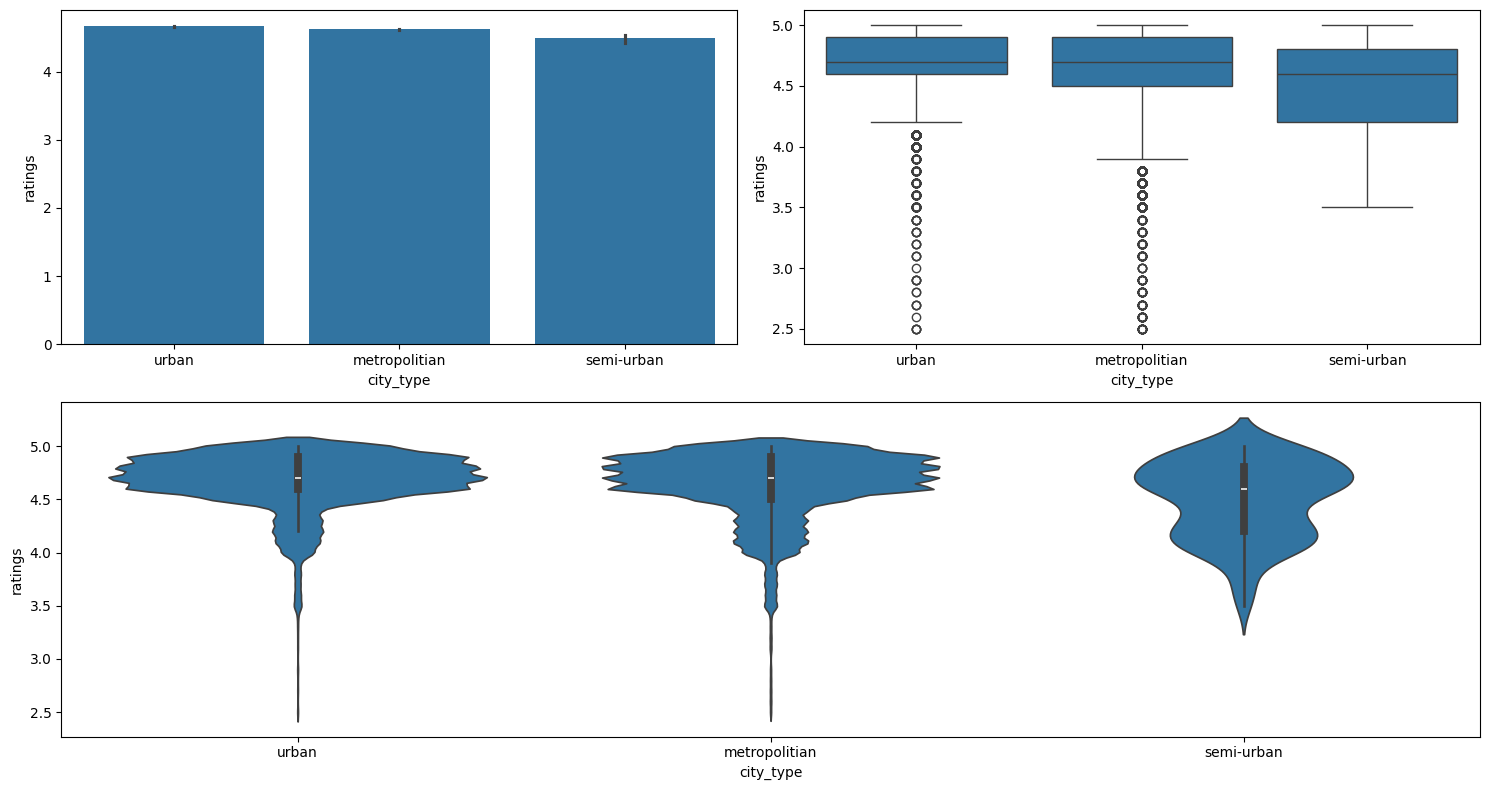

In [151]:
# does city type affects rider ratings

numerical_categorical_analysis(df, "city_type", "ratings")
     

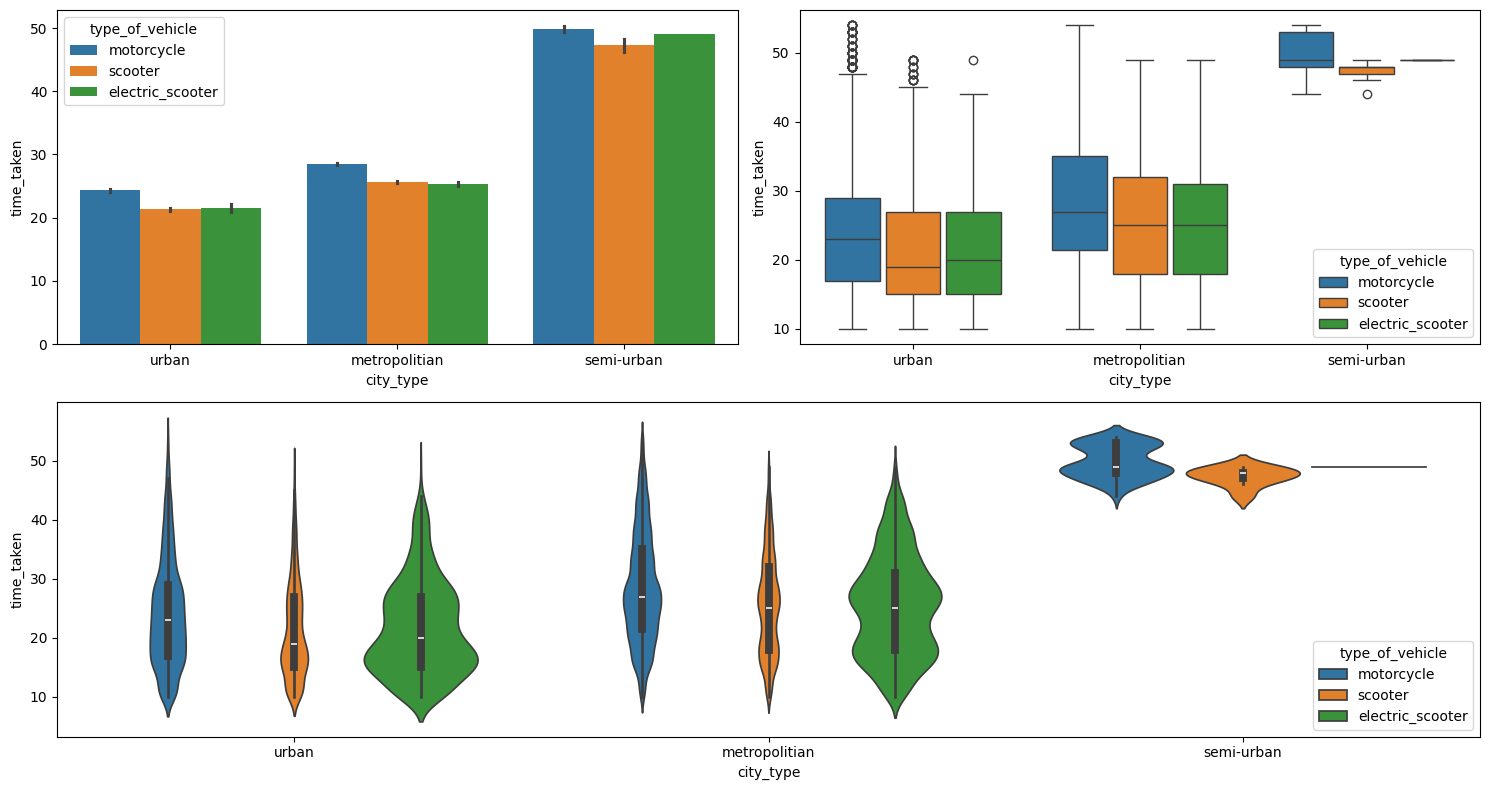

In [152]:
# city type, type of vehicle and delivery time analysis

multivariate_analysis(df, "time_taken", "city_type", "type_of_vehicle")

### Distance

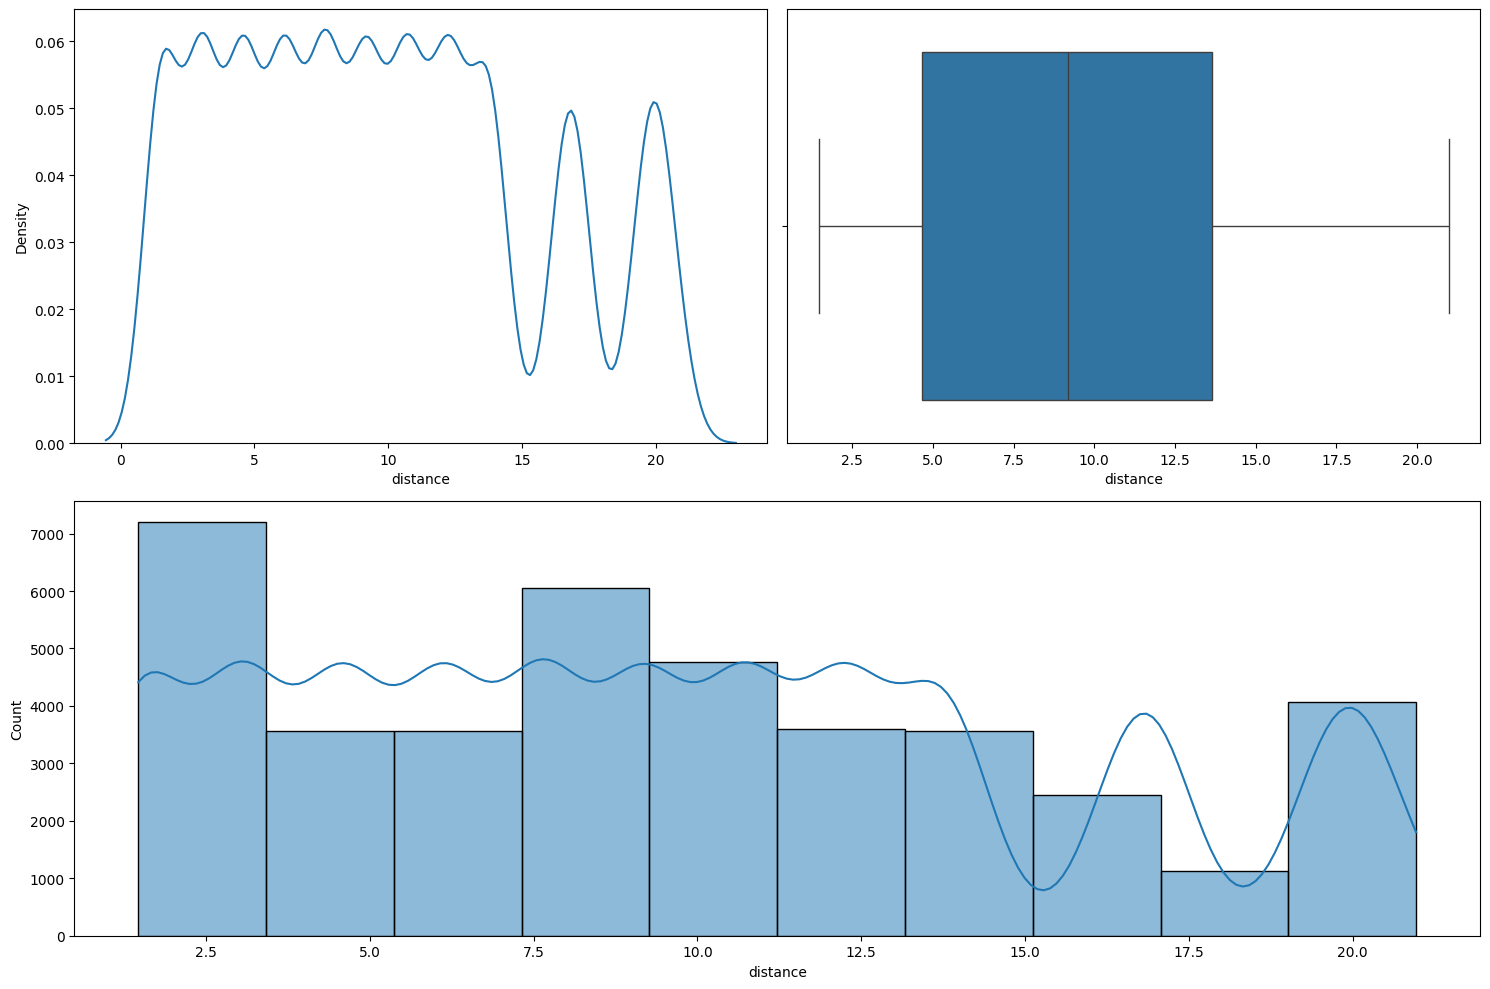

In [153]:
# numerical analysis of distance

numerical_analysis(df, "distance",bins=10)

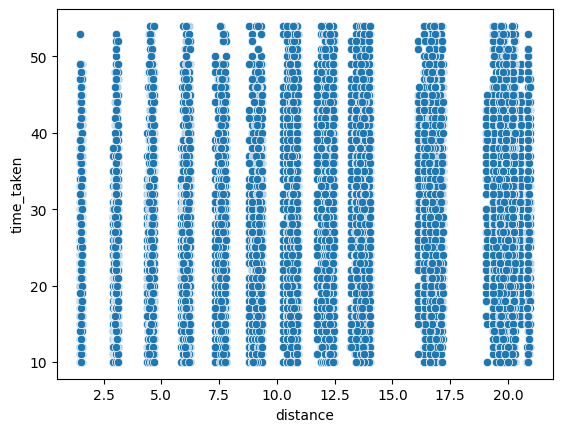

In [154]:
# relationship between distance and delivery times

sns.scatterplot(df,x="distance",y="time_taken")
plt.show()

In [155]:
# corr

df[["distance","time_taken"]].corr()

,distance,time_taken
distance,1.000000,0.321094
time_taken,0.321094,1.000000


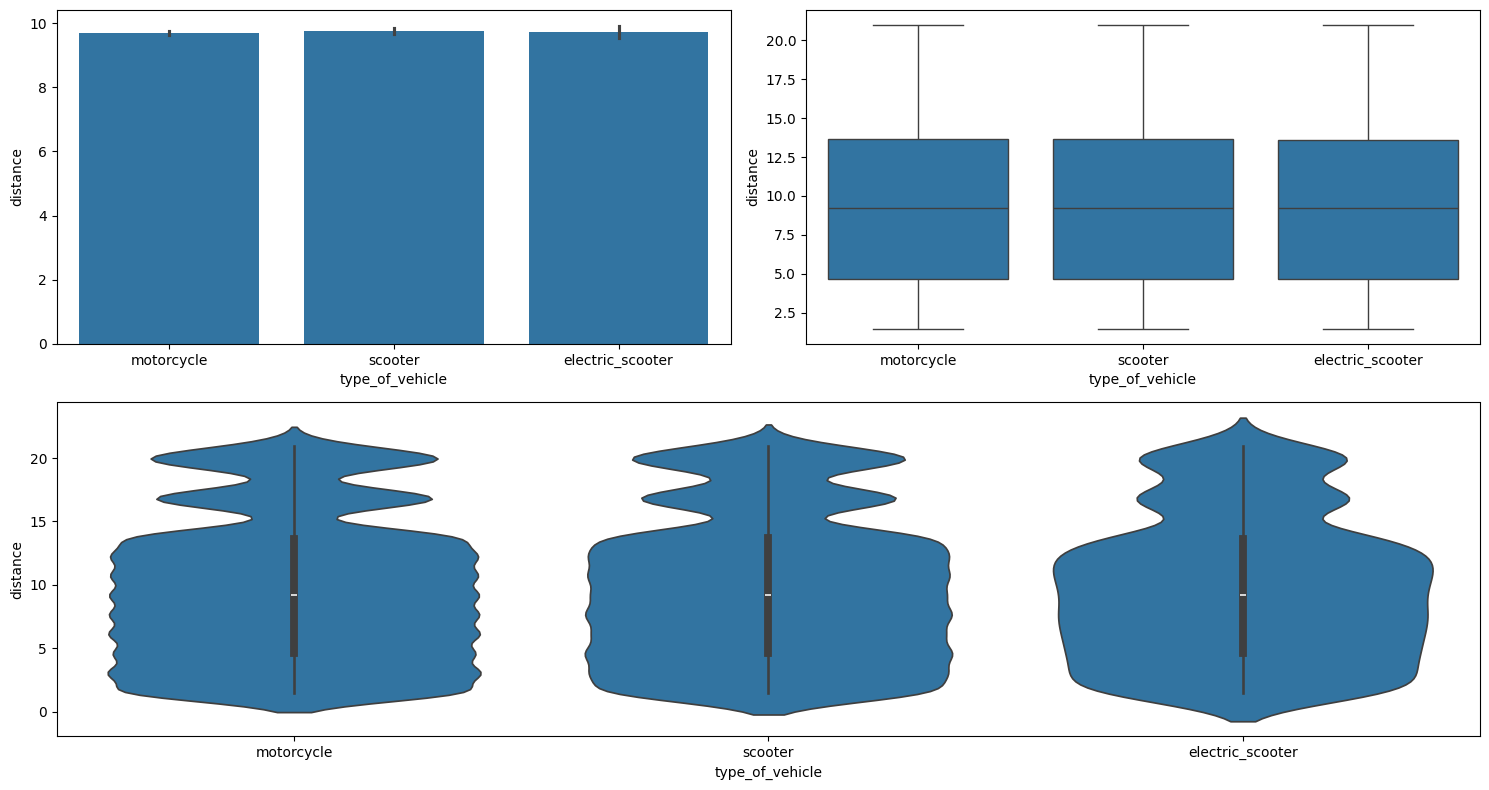

In [156]:
# vehicle type and distance analysis

numerical_categorical_analysis(df, "type_of_vehicle", "distance")

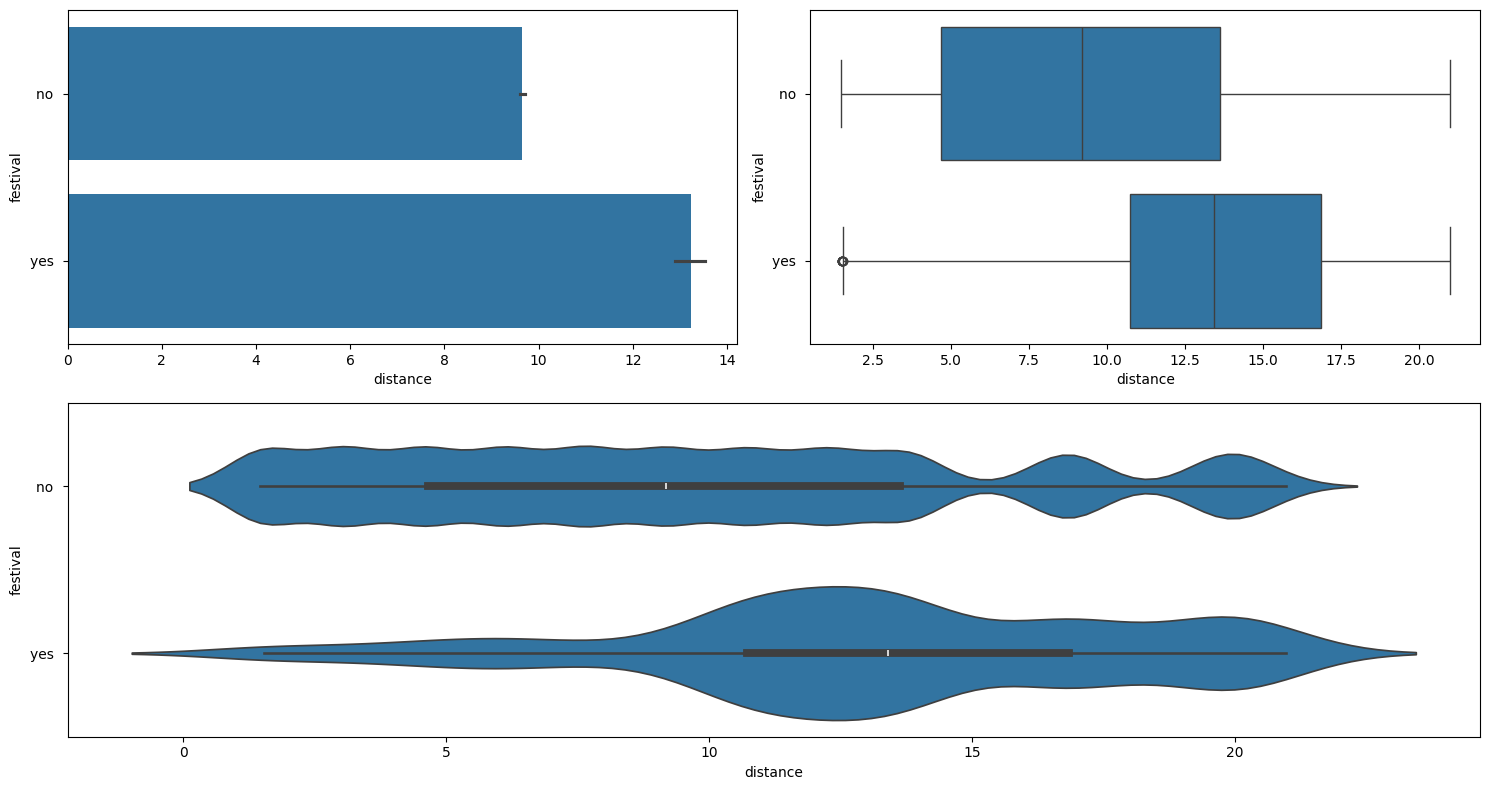

In [157]:
# do riders cover more distances during festivals

numerical_categorical_analysis(df, "distance", "festival")

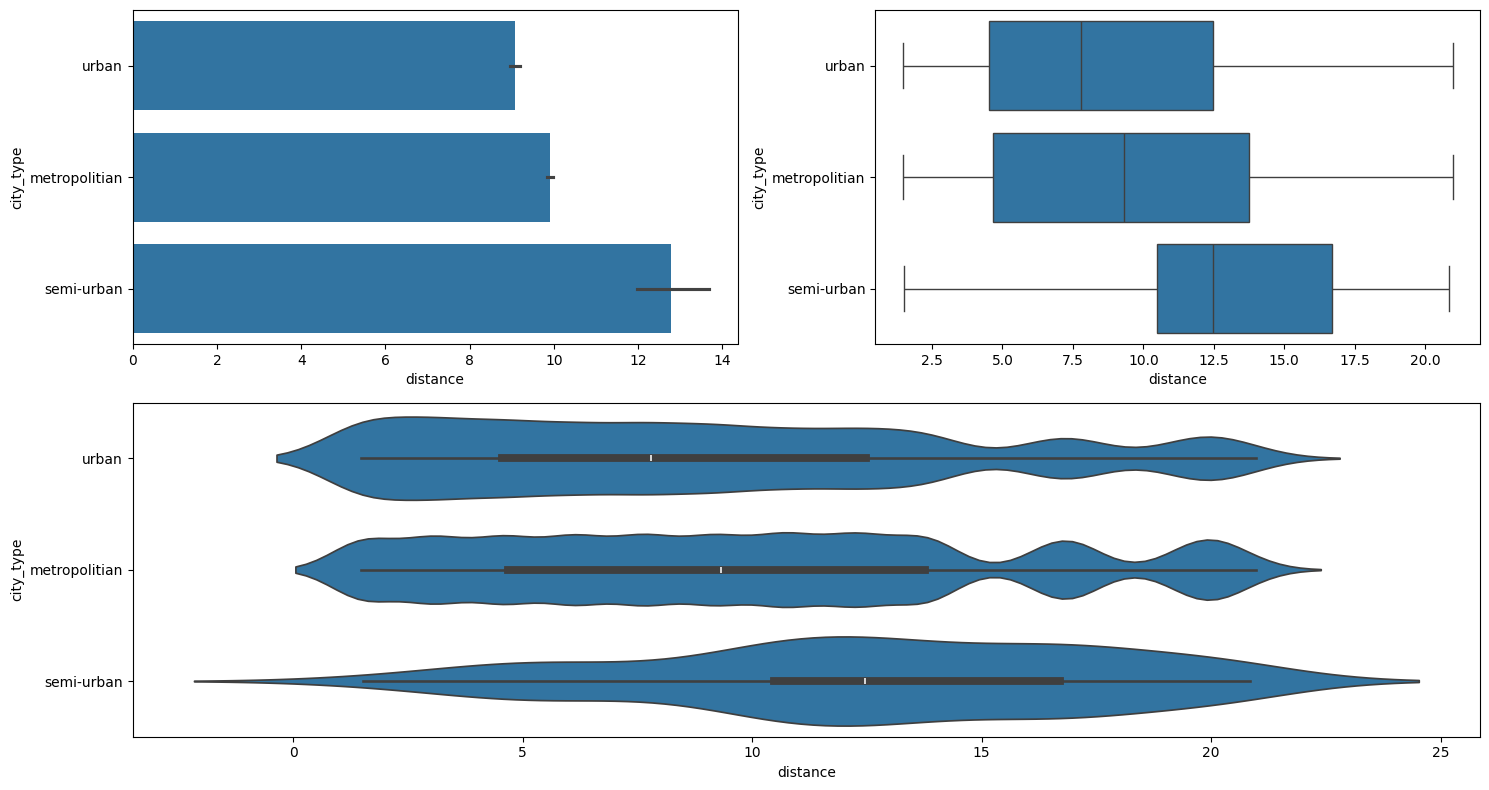

In [158]:
# distance and city type

numerical_categorical_analysis(df, "distance", "city_type")

In [159]:
# new feature based on distance

df = df.assign(
        distance_type = (
            pd.cut(df["distance"],
                   bins=[0,5,10,15,25],                          
                   right=False,
                   labels=["short","medium","long","very_long"])
        ))
     

In [160]:
df.distance_type.value_counts()

distance_type
medium       10773
long         10771
short        10764
very_long     7650
Name: count, dtype: int64

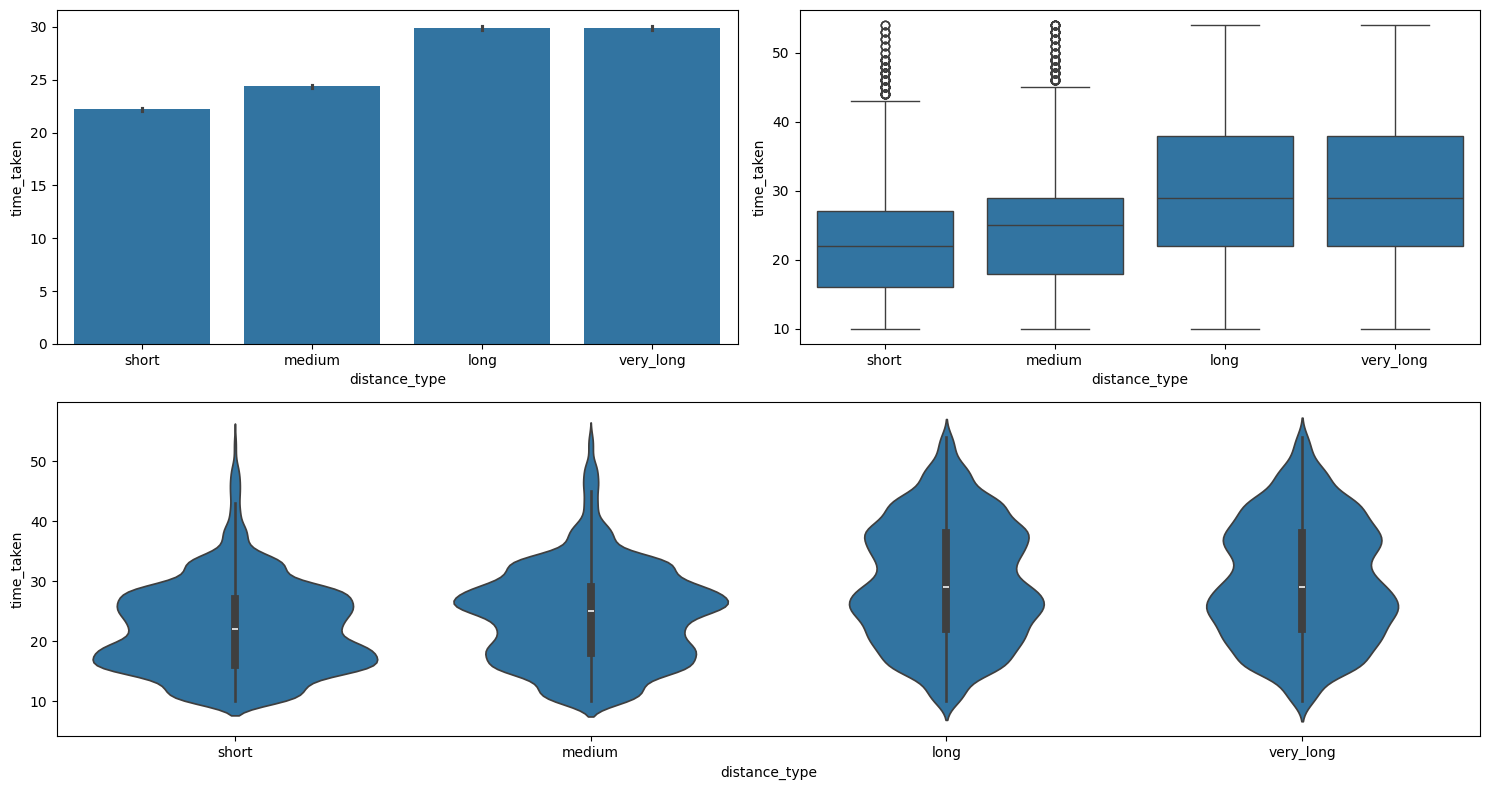

In [161]:
# does distance type affects delivery times

numerical_categorical_analysis(df, "distance_type", "time_taken")

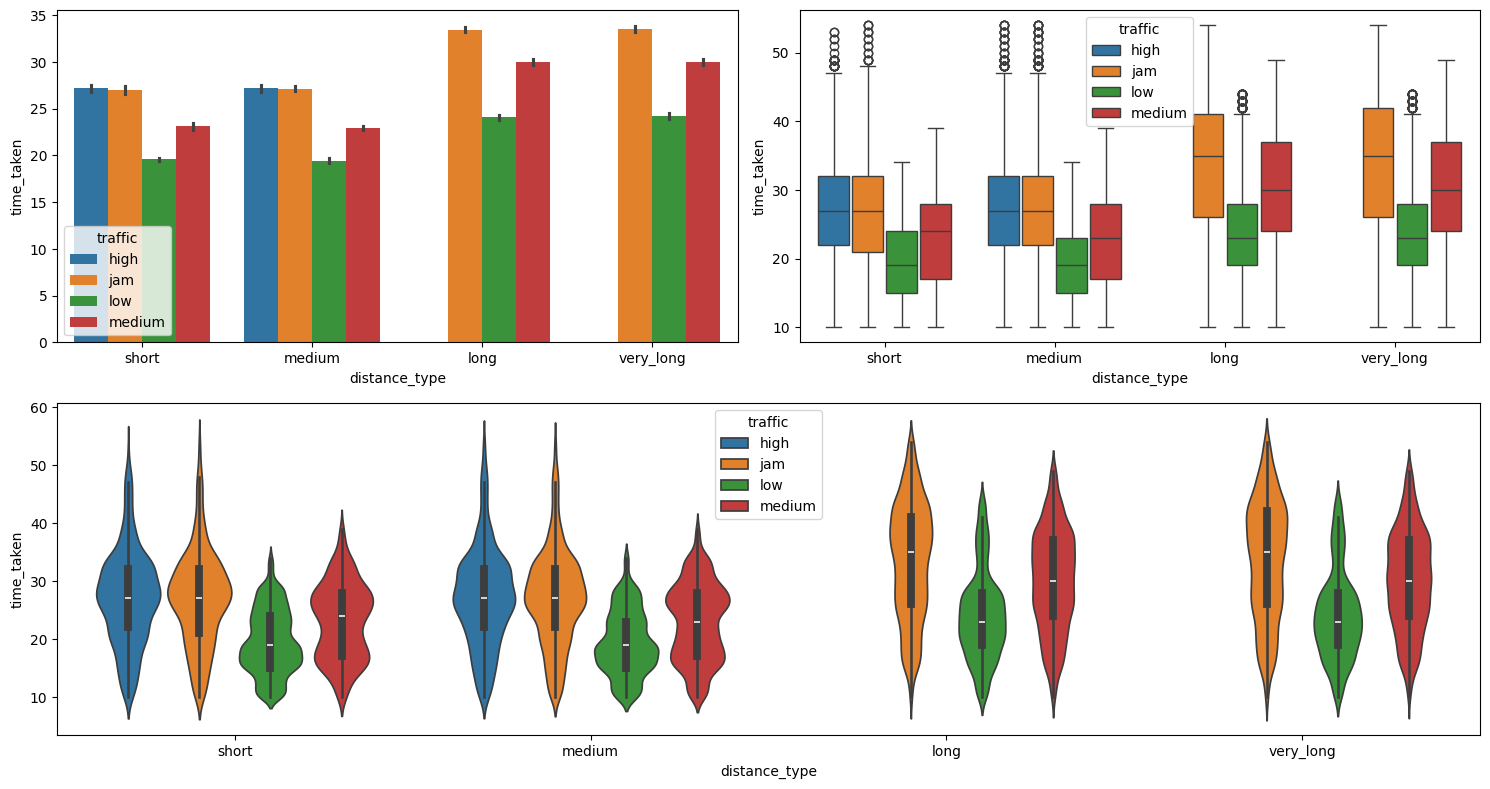

In [162]:
# delivery times based on distance and traffic

multivariate_analysis(df, "time_taken", "distance_type", "traffic")

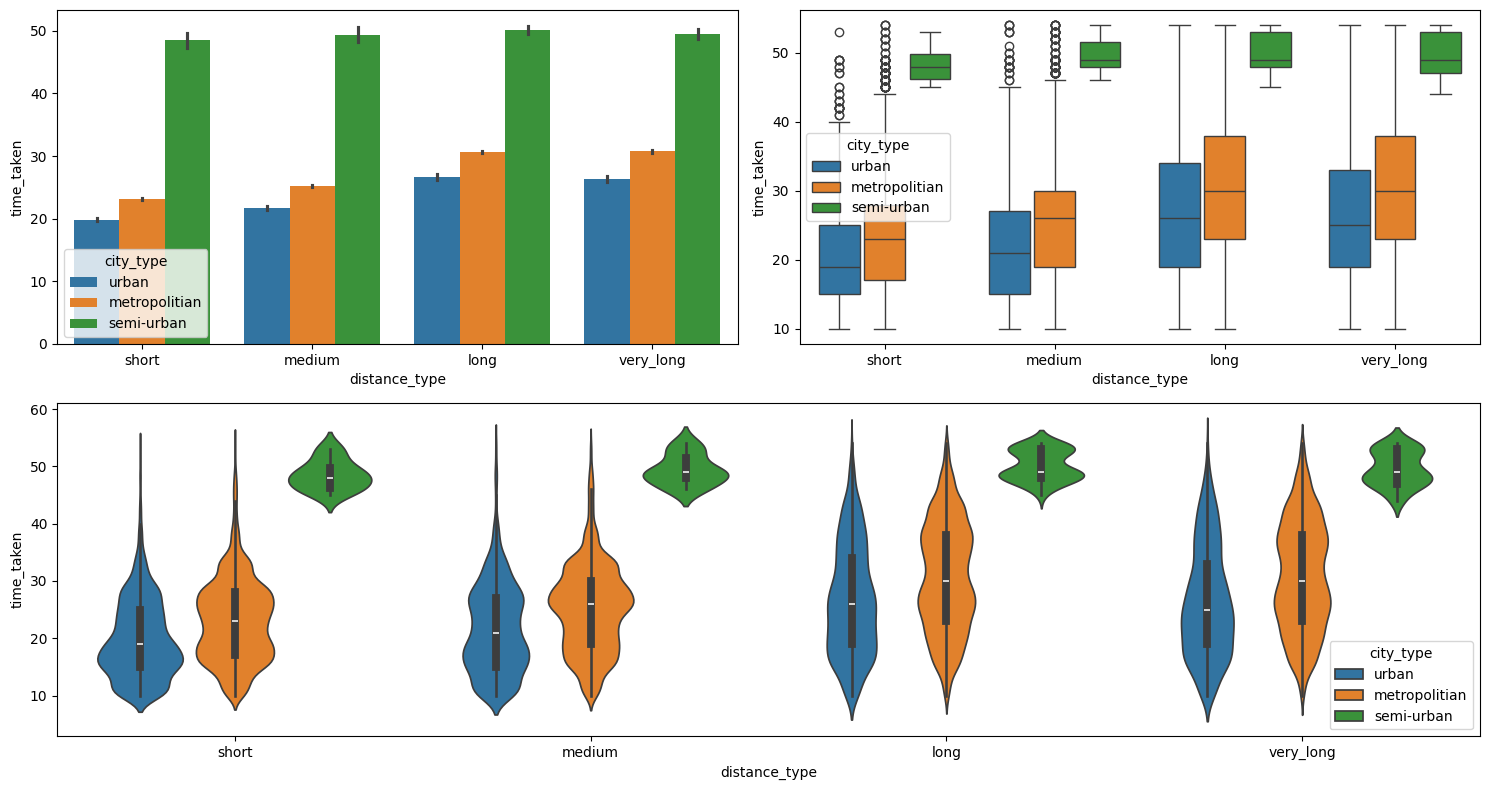

In [163]:
# delivery times based on distance and traffic

multivariate_analysis(df, "time_taken", "distance_type", "city_type")

# 6 Feature Selection

In [164]:
# drop columns not required for model input

columns_to_drop =  ['rider_id',
                    'restaurant_latitude',
                    'restaurant_longitude',
                    'delivery_latitude',
                    'delivery_longitude',
                    'order_date',
                    "order_time_hour",
                    "order_day",
                    "city_name",
                    "order_day_of_week",
                    "order_month",
                    "order_year",
                    "time_taken_log"
                   ]

In [165]:
df.drop(columns=columns_to_drop, inplace=True)

df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time,order_time_of_day,distance,distance_type
0,37.0,4.9,Sunny,high,2,snack,motorcycle,0.0,no,urban,24,1,15.0,morning,3.025149,short
1,34.0,4.5,Stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,0,5.0,evening,20.183530,very_long
2,23.0,4.4,Sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,1,15.0,morning,1.552758,short
3,38.0,4.7,Sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,0,10.0,evening,7.790401,medium
4,32.0,4.6,Cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,30.0,4.8,Windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,0,10.0,morning,1.489846,short
45589,21.0,4.6,Windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,0,15.0,evening,NaN,NaN
45590,30.0,4.9,Cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,0,15.0,night,4.657195,short
45591,20.0,4.7,Cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,0,5.0,afternoon,6.232393,medium


In [166]:
# check for missing values

df.isna().sum()

age                       0
ratings                   0
weather                   0
traffic                   0
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     933
festival                217
city_type              1135
time_taken                0
is_weekend                0
pickup_time               0
order_time_of_day         0
distance               3636
distance_type          3636
dtype: int64

In [167]:
# check for duplicates

df.duplicated().sum()

np.int64(0)

In [168]:
## Drop missing values
temp_df = df.copy().dropna()

# 7 Model Training

In [169]:
# Import Libraries

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# MODELS
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [170]:
# split into X and y

X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

X

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,is_weekend,pickup_time,order_time_of_day,distance,distance_type
0,37.0,4.9,Sunny,high,2,snack,motorcycle,0.0,no,urban,1,15.0,morning,3.025149,short
1,34.0,4.5,Stormy,jam,2,snack,scooter,1.0,no,metropolitian,0,5.0,evening,20.183530,very_long
2,23.0,4.4,Sandstorms,low,0,drinks,motorcycle,1.0,no,urban,1,15.0,morning,1.552758,short
3,38.0,4.7,Sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,0,10.0,evening,7.790401,medium
4,32.0,4.6,Cloudy,high,1,snack,scooter,1.0,no,metropolitian,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45587,35.0,4.2,Windy,jam,2,drinks,motorcycle,1.0,no,metropolitian,0,10.0,night,16.600272,very_long
45588,30.0,4.8,Windy,high,1,meal,motorcycle,0.0,no,metropolitian,0,10.0,morning,1.489846,short
45590,30.0,4.9,Cloudy,low,1,drinks,scooter,0.0,no,metropolitian,0,15.0,night,4.657195,short
45591,20.0,4.7,Cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,0,5.0,afternoon,6.232393,medium


In [171]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [172]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (30334, 15)
The shape of test data is (7584, 15)


In [173]:
# missing values in train data

X_train.isna().sum()

age                    0
ratings                0
weather                0
traffic                0
vehicle_condition      0
type_of_order          0
type_of_vehicle        0
multiple_deliveries    0
festival               0
city_type              0
is_weekend             0
pickup_time            0
order_time_of_day      0
distance               0
distance_type          0
dtype: int64

In [174]:
# As data is highly skewed, perform transformation on target column
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [175]:
df.columns.tolist()

['age',
 'ratings',
 'weather',
 'traffic',
 'vehicle_condition',
 'type_of_order',
 'type_of_vehicle',
 'multiple_deliveries',
 'festival',
 'city_type',
 'time_taken',
 'is_weekend',
 'pickup_time',
 'order_time_of_day',
 'distance',
 'distance_type']

In [176]:
# Segregating columns based on type
num_cols = ["age", "ratings", "pickup_time","distance"]

nominal_cat_cols = [
    "weather",
    "type_of_order",
    "type_of_vehicle",
    "festival",
    "city_type",
    "is_weekend",
    "order_time_of_day",
    "multiple_deliveries"
                   ]

ordinal_cat_cols = ["traffic","distance_type","vehicle_condition"]

In [177]:
# Ordinal Order Definitions
traffic_order = [
    "low",
    "medium",
    "high",
    "jam"
]

distance_type_order = [
    "short",
    "medium",
    "long",
    "very_long"
]

vehicle_condition_order = [0, 1, 2, 3]

In [178]:
# Numerical Pipeline
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

In [179]:
# Nominal Pipeline
nominal_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [180]:
# Ordinal Pipeline
ordinal_pipeline = Pipeline([
    (
        "ordinal",
        OrdinalEncoder(
            categories=[
                traffic_order,
                distance_type_order,
                vehicle_condition_order
            ]
        )
    )
])

In [181]:
# Column Transformers
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("nominal", nominal_pipeline, nominal_cat_cols),
    ("ordinal", ordinal_pipeline, ordinal_cat_cols)
])

In [182]:
# Creating a function that trains , evaluates and returns the evaluation score
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # fit
    model.fit(X_train, y_train)

    # prediction
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)

    print("="*50)
    print(model.named_steps["model"].__class__.__name__)
    print("="*50)

    print(f"Train R2 Score : {train_r2:.4f}")
    print(f"Test R2 Score  : {test_r2:.4f}")

    print(f"Train RMSE     : {train_rmse:.4f}")
    print(f"Test RMSE      : {test_rmse:.4f}")

    print(f"Train MAE      : {train_mae:.4f}")
    print(f"Test MAE       : {test_mae:.4f}")

    return {
        "model": model.named_steps["model"].__class__.__name__,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse
    }

In [183]:
# LinearRegression model pipeline
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# LinearRegression model evaluation

linear_results = evaluate_model(
    linear_model,
    X_train,
    X_test,
    y_train,
    y_test
)

LinearRegression
Train R2 Score : 0.6113
Test R2 Score  : 0.6069
Train RMSE     : 5.8224
Test RMSE      : 5.8364
Train MAE      : 4.6555
Test MAE       : 4.6512


In [184]:
# Support Vector Regressor model pipeline
svr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR())
])

# Support Vector Regressor model evaluation
svr_results = evaluate_model(
    svr_model,
    X_train,
    X_test,
    y_train,
    y_test
)

SVR
Train R2 Score : 0.7580
Test R2 Score  : 0.7438
Train RMSE     : 4.5944
Test RMSE      : 4.7122
Train MAE      : 3.5892
Test MAE       : 3.7100


In [185]:
# DecisionTreeRegressor model pipeline
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

# DecisionTreeRegressor model evaluation
dt_results = evaluate_model(
    dt_model,
    X_train,
    X_test,
    y_train,
    y_test
)

DecisionTreeRegressor
Train R2 Score : 1.0000
Test R2 Score  : 0.6790
Train RMSE     : 0.0000
Test RMSE      : 5.2742
Train MAE      : 0.0000
Test MAE       : 4.0191


In [186]:
# Random Forest model pipeline
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# Evaluate Random Forest Regressor model
rf_results = evaluate_model(
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

RandomForestRegressor
Train R2 Score : 0.9763
Test R2 Score  : 0.8313
Train RMSE     : 1.4373
Test RMSE      : 3.8231
Train MAE      : 1.1410
Test MAE       : 3.0613


In [187]:
# Creating the results Dataframe
results_df = pd.DataFrame([
    linear_results,
    svr_results,
    dt_results,
    rf_results
])

results_df.sort_values(
    by="test_r2",
    ascending=False
)

,model,train_r2,test_r2,train_rmse,test_rmse
3,RandomForestRegressor,0.976313,0.831330,1.437292,3.823139
1,SVR,0.757961,0.743764,4.594449,4.712175
2,DecisionTreeRegressor,1.000000,0.678991,0.000000,5.274243
0,LinearRegression,0.611297,0.606909,5.822365,5.836436


In [ ]:
# Creating model dict
models = {
    "LinearRegression": linear_model,
    "SVR": svr_model,
    "DecisionTree": dt_model,
    "RandomForest": rf_model
}

# Evaluate a model using cross - validation
for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    
    print(name)
    print("CV Scores :", scores)
    print("Mean CV R2:", scores.mean())

LinearRegression
CV Scores : [0.60993313 0.60487174 0.6164324  0.61190095 0.60866956]
Mean CV R2: 0.6103615566679028


# 8 Model Selection & Hyper parameter Tuning



The best performing model is random forest regressor.

In [ ]:
# Setting the pipeline for Random forest
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# Setting the hyperparamters
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# Using the gridsearchcv to get best model parameters
rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

print("Best Params:", rf_grid.best_params_)
print("Best Score :", rf_grid.best_score_)

In [ ]:
# Getting the best estimator
best_rf_model = rf_grid.best_estimator_

In [ ]:
# Training the best the estimator and evaluating the model
rf_results = evaluate_model(
    best_rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

In [ ]:
# Save model
import joblib

joblib.dump(best_rf_model, "best_random_forest_pipeline.pkl")

print("Model saved successfully.")

In [ ]:
# Load model
loaded_model = joblib.load("best_random_forest_pipeline.pkl")

In [ ]:
# predictions = loaded_model.predict(new_data)